## 0. Setup

In [2]:
# Colab: torch / numpy / scipy / pandas / matplotlib are pre-installed.
import importlib.util, subprocess, sys

for _pkg in ["torch", "numpy", "scipy", "pandas", "matplotlib"]:
    if importlib.util.find_spec(_pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)

import math
import time
import json
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Beta, Categorical
from scipy.stats import gamma as gamma_dist
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {DEVICE}")

np.set_printoptions(precision=3, suppress=True, linewidth=140)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 3)

EPS_NUM = 1e-9  # numerical tolerance for non-negativity / feasibility checks

# Per-step feasibility assertions inside the environment. They are cheap but not free;
RUNTIME_CHECKS = True

try:                       # `display` exists in Colab/Jupyter; fall back outside it
    display
except NameError:
    display = print


torch 2.11.0+cpu | device: cpu


## 1. Instance and parameters (§3.2)

**Sets.** $\mathcal{G}$ products, $\mathcal{J}_g=\{1,\dots,J_g\}$ ordered stages,
$\mathcal{E}_{gj}$ eligible equipment, $\mathcal{N}$ review epochs, $\mathcal{H}_n$
execution intervals, $\mathcal{A}_{gj}=\{0,\dots,\bar a_{gj}\}$ age classes.

Following §3.5, *"for a given product–equipment pair $(g,e)$, equipment eligibility
identifies a unique processing stage"*. The instance therefore assigns each equipment
unit to exactly one stage, and $\mathcal{E}_{gj}$ is the set of units of stage $j$ that
are eligible for product $g$.

Stages are stored **0-indexed** internally ($j=0,\dots,J_g-1$; the final stage $J_g$ of
the paper is index `Jg[g]-1`). Everything else keeps the paper's naming.

In [3]:
@dataclass
class Instance:
    """Sets and indices of §3.2."""
    G: int                          # |G|  number of products
    Jg: np.ndarray                  # (G,)  number of stages J_g per product
    E: int                          # |E|  number of equipment units
    stage_of: np.ndarray            # (G,E) stage served by e for product g, -1 if unused
    eligible: np.ndarray            # (G,E) bool: derived from stage_of >= 0
    abar: np.ndarray                # (G,Jmax) max admissible age class \bar a_{gj}
    N: int                          # |N|  review epochs
    H: int                          # |H_n| execution intervals per epoch (constant here)

    def __post_init__(self):
        self.Jmax = int(self.Jg.max())
        self.Amax = int(self.abar.max())
        self.A = self.Amax + 1                                   # age classes 0..Amax
        self.Upsilon = self.N * self.H                           # Upsilon, Eq (47)

        # valid_gj[g,j]  : stage j exists for product g
        self.valid_gj = np.zeros((self.G, self.Jmax), dtype=bool)
        for g in range(self.G):
            self.valid_gj[g, : self.Jg[g]] = True

        # valid_gja[g,j,a] : age class a is admissible for (g,j)
        self.valid_gja = np.zeros((self.G, self.Jmax, self.A), dtype=bool)
        for g in range(self.G):
            for j in range(self.Jg[g]):
                self.valid_gja[g, j, : self.abar[g, j] + 1] = True

        # final stage index of each product (paper's J_g)
        self.final_stage = self.Jg - 1

        # E_{gj} as a boolean mask [G, Jmax, E]
        self.eligible = self.stage_of >= 0
        self.Egj = np.zeros((self.G, self.Jmax, self.E), dtype=bool)
        for g in range(self.G):
            for e in range(self.E):
                j = int(self.stage_of[g, e])
                if j >= 0:
                    assert j < self.Jg[g], (
                        f"equipment {e} serves stage {j} which product {g} does not have")
                    self.Egj[g, j, e] = True

        # per-equipment option list for the micro head: index 0 = idle, 1..G = product g-1
        self.equip_options = [
            np.array([True] + [bool(self.eligible[g, e]) for g in range(self.G)])
            for e in range(self.E)
        ]

    def iota_to_nh(self, iota: int) -> Tuple[int, int]:
        """Eq (48): flattened index iota -> (n, h), both 0-indexed here."""
        return iota // self.H, iota % self.H

    def nh_to_iota(self, n: int, h: int) -> int:
        """Eq (47)-(48) inverse."""
        return n * self.H + h


@dataclass
class Params:
    """Parameters of §3.2. Shapes are stated per field."""
    # --- economic ---------------------------------------------------------
    mu: np.ndarray            # (G,Jmax,E)   unit processing cost      mu_{gje}
    alpha: np.ndarray         # (G,A)        carrying cost by age      alpha_{ga}
    beta: np.ndarray          # (G,)         unmet-demand penalty      beta_g
    rho: np.ndarray           # (G,N)        service value / revenue   rho_{gn}
    delta: np.ndarray         # (G,Jmax)     disposal / write-off      delta_{gj}
    sigma: np.ndarray         # (G,Jmax)     salvage / rework value    sigma_{gj}
    kappa: np.ndarray         # (G,G,E)      changeover cost g'->g     kappa_{gg'e}
    theta_service: np.ndarray # (G,)         backlog sensitivity       theta^service_g
    eta_idle: float           # idle-capacity cost                     eta_idle
    eta_serv: float           # service-shortfall penalty              eta_serv
    eta_viol: float           # feasibility-correction penalty         eta_viol

    # --- capacity & process ----------------------------------------------
    tau: np.ndarray           # (G,Jmax,E)   processing time / unit    tau_{gje}
    Cbar: np.ndarray          # (E,H,N)      nominal capacity          \bar C_{ehn}
    upsilon: np.ndarray       # (G,G,E)      setup time g'->g          upsilon_{gg'e}
    psi: np.ndarray           # (G,Jmax,E)   shared-resource rate      psi_{gje}
    ell: np.ndarray           # (G,)         min release               ell_g
    umax: np.ndarray          # (G,)         max release               u_g
    Mfrak: float              # big-M                                  \mathfrak{M}

    # --- deterioration ----------------------------------------------------
    lam0: np.ndarray          # (G,Jmax)     baseline hazard           lambda^0_{gj}
    lam1: np.ndarray          # (G,Jmax)     age sensitivity           lambda^1_{gj}
    lam2: np.ndarray          # (G,Jmax)     temperature sensitivity   lambda^2_{gj}
    lam3: np.ndarray          # (G,Jmax)     humidity sensitivity      lambda^3_{gj}
    lam4: np.ndarray          # (G,Jmax)     storage-deviation sens.   lambda^4_{gj}
    omega: np.ndarray         # (G,Jmax)     readiness coefficient     omega_{gj} in [0,1]
    Delta: np.ndarray         # (H,N)        interval duration         Delta_{hn}

    # --- service / newsvendor --------------------------------------------
    SLmin: np.ndarray         # (G,)         target min service level  SL^min_g
    epsilon: float            # fractile truncation, 0 < epsilon < 1/2
    eps0: float               # Eq (29) division guard

    # --- discounting -------------------------------------------------------
    gamma_disc: float         # gamma in (0,1], Eq (42)


### 1.1 Instance data

> `>>> INSTANCE DATA` — the paper contains no numerical study, so the values below are a
> **self-consistent fresh-food instance** chosen only so the notebook runs. Replace this
> cell (and nothing else) with your own data. The `SMALL` preset is a fast smoke-test
> configuration; `MEDIUM` is the default.

In [4]:
# >>> INSTANCE DATA

TARGET_TIME_UTIL = 0.625      # 1/CAT avec CAT = 1.6, scenario "loose" d'Ozdamar (1999)
TARGET_RESOURCE_UTIL = 0.625  # meme regle appliquee au froid


def build_instance(seed: int = 0, N: int = 28) -> Tuple[Instance, Params, dict]:
    # N is a PARAMETER so that a ladder of reduced-horizon instances can be built for
    G, E, H = 3, 4, 3                     # 28 jours x 3 postes -> Upsilon = 84
    Jg = np.array([3, 3, 4], dtype=int)
    Jmax = int(Jg.max())

    # ---- routes fixes ; machines 0-indexees (e0..e3 = e1..e4 du papier) ----
    stage_of = -np.ones((G, E), dtype=int)
    stage_of[0, 2], stage_of[0, 1], stage_of[0, 0] = 0, 1, 2
    stage_of[1, 1], stage_of[1, 3], stage_of[1, 2] = 0, 1, 2
    stage_of[2, 0], stage_of[2, 2], stage_of[2, 1], stage_of[2, 3] = 0, 1, 2, 3

    # >>> ADDED (Option A): give ONE stage a second eligible machine, so
    # reassignment is structurally possible under a disruption. P1 stage 1 was
    # e1-only; e3 is now also eligible for it (slower, see tau_min below). No
    # other route changes -- everything else is exactly as before.
    # stage_of[0, 3] = 1   # OFF pour le run C

    # ---- classes d'age : durees de vie 3/4/5 jours = 9/12/15 postes --------
    abar_g = np.array([3, 4, 5]) * H - 1                       # 8, 11, 14
    abar = np.zeros((G, Jmax), dtype=int)
    for g in range(G):
        abar[g, : Jg[g]] = abar_g[g]

    inst = Instance(G=G, Jg=Jg, E=E, stage_of=stage_of,
                    eligible=(stage_of >= 0), abar=abar, N=N, H=H)
    A = inst.A

    # ---- demande nominale --------------------------------------------------
    nominal_demand = np.full(G, 100.0)

    # ---- temps de traitement (min/unite -> h/unite) -------------------------
    tau_min = np.full((G, Jmax, E), np.nan)
    tau_min[0, 0, 2], tau_min[0, 1, 1], tau_min[0, 2, 0] = 2.6, 3.2, 2.8
    tau_min[1, 0, 1], tau_min[1, 1, 3], tau_min[1, 2, 2] = 3.0, 2.4, 3.4
    tau_min[2, 0, 0], tau_min[2, 1, 2], tau_min[2, 2, 1], tau_min[2, 3, 3] = 3.6, 3.0, 2.8, 2.2
    # tau_min[0, 1, 3] = 4.0     # >>> ADDED: alternate machine e3 for P1 stage 1, 25% slower
    tau = np.nan_to_num(tau_min / 60.0, nan=1e6)               # ineligible -> infini

    Delta = np.full((H, N), 8.0)                               # poste de 8 h
    Cbar = np.full((E, H, N), 8.0)                             # machine dispo tout le poste

    # ---- couts de traitement et froid, repartis au prorata de tau -----------
    mu = np.zeros((G, Jmax, E))
    psi = np.zeros((G, Jmax, E))
    for g in range(G):
        # >>> CHANGED: a stage can now have more than one eligible machine.
        # `tot` still normalises against the FASTEST machine per stage (the
        # nominal route), but cost/resource shares are assigned to EVERY
        # eligible machine using that machine's own tau -- so an alternate,
        # slower machine costs proportionally more per unit, which is what
        # you would expect operationally.
        route = []
        for j in range(Jg[g]):
            elig_e = [e for e in range(E) if stage_of[g, e] == j]
            route.append((j, min(elig_e, key=lambda e: tau_min[g, j, e])))
        tot = sum(tau_min[g, j, e] for j, e in route)
        for j in range(Jg[g]):
            for e in [e for e in range(E) if stage_of[g, e] == j]:
                share = tau_min[g, j, e] / tot
                mu[g, j, e] = 3.00 * share
                psi[g, j, e] = 0.15 * share

    # ---- changements de serie ----------------------------------------------
    upsilon = np.zeros((G, G, E))                              # 30 min = 0.5 h
    kappa = np.zeros((G, G, E))                                # declare
    for e in range(E):
        for g in range(G):
            for gp in range(G):
                if g != gp:
                    upsilon[g, gp, e] = 0.5
                    kappa[g, gp, e] = 10.0

    # ---- parametres economiques --------------------------------------------
    alpha = np.ones((G, A))                                    # possession = 1, sans effet d'age
    beta = np.full(G, 5.0)                                     # rupture / backlog
    rho = np.full((G, N), 10.0)                                # revenu par unite servie
    delta = np.zeros((G, Jmax)); sigma = np.zeros((G, Jmax))
    for g in range(G):
        delta[g, : Jg[g]] = 7.0                                # peremption / rebut
        sigma[g, : Jg[g]] = 4.0                                # recuperation
    theta_service = np.full(G, 0.05)                           # 1 jour de retard double la penalite

    # ---- deterioration -------------------------------------------------------
    lam0_g = np.array([0.000421, 0.000547, 0.000643])          # /h
    lam1_g = np.array([0.000132, 0.000131, 0.000124])          # /h/classe d'age
    lam2_g = np.array([0.000177, 0.000240, 0.000290])          # /h/degC d'ecart
    lam0 = np.zeros((G, Jmax)); lam1 = np.zeros((G, Jmax)); lam2 = np.zeros((G, Jmax))
    lam3 = np.zeros((G, Jmax)); lam4 = np.zeros((G, Jmax)); omega = np.zeros((G, Jmax))
    for g in range(G):
        for j in range(Jg[g]):
            lam0[g, j], lam1[g, j], lam2[g, j] = lam0_g[g], lam1_g[g], lam2_g[g]
            omega[g, j] = 0.0 if j == Jg[g] - 1 else 1.0       # en-cours pleinement compte

    # ---- bornes de lancement -------------------------------------------------
    ell = np.full(G, 40.0)                                     # declare : 1/4 de poste
    umax = np.full(G, 200.0)                                   # 2x la demande (Kara & Dogan)

    prm = Params(
        mu=mu, alpha=alpha, beta=beta, rho=rho, delta=delta, sigma=sigma, kappa=kappa,
        theta_service=theta_service,
        eta_idle=1.0, eta_serv=1.0, eta_viol=1.0,              # poids a 1, cf. Table 2
        tau=tau, Cbar=Cbar, upsilon=upsilon, psi=psi, ell=ell, umax=umax, Mfrak=1e7,
        lam0=lam0, lam1=lam1, lam2=lam2, lam3=lam3, lam4=lam4, omega=omega, Delta=Delta,
        SLmin=np.full(G, 0.90),                                # Wu et al. (2025)
        epsilon=0.01, eps0=1e-6, gamma_disc=0.99,
    )

    Rbar_nominal = float(nominal_demand.sum() * 0.15 / H / TARGET_RESOURCE_UTIL)
    nominal = dict(demand=nominal_demand, Wbar=4.0, Rbar=Rbar_nominal,
                   Wbar_profile=np.array([4.0, 4.0, 4.0]),     # effectif complet sur les 3 postes
                   machine_hours_per_epoch=float(E * H * 8.0))

    # ---- controle de calibration ---------------------------------------------
    load = np.zeros(E)
    for g in range(G):
        for j in range(Jg[g]):
            elig = [ee for ee in range(E) if stage_of[g, ee] == j]
            e = min(elig, key=lambda ee: tau_min[g, j, ee])
            load[e] += nominal_demand[g] * tau_min[g, j, e]
    cap_day = H * 480.0
    print("charge machine (min/jour) :")
    for e in range(E):
        print(f"   e{e}: {load[e]:6.0f} min  ->  {100 * load[e] / cap_day:5.1f} %")
    print(f"   goulot {100 * load.max() / cap_day:.1f} %  (cible 62.5 % = CAT 1.6)")
    return inst, prm, nominal


INST, PRM, NOMINAL = build_instance()
print(f"\n|G|={INST.G}  J_g={INST.Jg}  |E|={INST.E}  |N|={INST.N}  |H_n|={INST.H}  "
      f"Upsilon={INST.Upsilon}  classes d'age={INST.A}")
print(f"routes stage_of[g,e] =\n{INST.stage_of}")
print(f"\\bar R = {NOMINAL['Rbar']:.1f} kWh/poste,  \\bar W profil = {NOMINAL['Wbar_profile']}")
print(f"tau in [{PRM.tau[PRM.tau < 1e5].min() * 60:.1f}, "
      f"{PRM.tau[PRM.tau < 1e5].max() * 60:.1f}] min/unite")


charge machine (min/jour) :
   e0:    640 min  ->   44.4 %
   e1:    900 min  ->   62.5 %
   e2:    900 min  ->   62.5 %
   e3:    460 min  ->   31.9 %
   goulot 62.5 %  (cible 62.5 % = CAT 1.6)

|G|=3  J_g=[3 3 4]  |E|=4  |N|=28  |H_n|=3  Upsilon=84  classes d'age=15
routes stage_of[g,e] =
[[ 2  1  0 -1]
 [-1  0  2  1]
 [ 0  2  1  3]]
\bar R = 24.0 kWh/poste,  \bar W profil = [4. 4. 4.]
tau in [2.2, 3.6] min/unite


## 2. Scenario generation (§3.6, §3.8.5)

A scenario $\zeta$ fixes, for the whole planning horizon: the conditional predictive
demand distributions $\mathfrak{F}_{gn}$ and the realised demands $\mathscr{D}^\zeta_{gn}$
drawn from them, equipment availability $\mathfrak{a}^\zeta_{ehn}$, storage conditions
$\mathbf{c}^\zeta_{hn}=(\mathrm{Temp},\mathrm{Hum},\mathrm{Dev})$, shared resource
$\bar R_{hn}$, workforce $\bar W_{hn}$ and input material $\mathfrak{m}^\zeta_{gn}$.

Per §3.8.5, *"each training episode draws a scenario $\zeta\sim\varpi$ from $\mathcal{R}$
and holds it fixed for the episode"*, so all exogenous quantities are pre-sampled here.

**Routine set $\mathcal{R}$ (training).** Demand variation and normal operating
uncertainty only. The paper requires three explicit guarantees, enforced by
`assert_routine` below: routine scenarios (i) do not activate the cold-chain deviation
channel $\mathrm{Dev}^\zeta_{hn}$, (ii) do not impose production-line failure states
outside the routine-availability range, (iii) do not impose workforce-shortage states
outside the routine-workforce range.

**Disruption set $\mathcal{D}$ (post-training only).** Three families: production-line
failure, workforce shortage, cold-chain failure. Generated here for completeness; it is
never sampled during training.

The predictive distribution is Gamma with epoch mean $m_{gn}$ and coefficient of
variation $\mathrm{cv}_g$, so $\mathfrak{F}^{-1}_{gn}(\chi)$ in Eqs (3) and (51) is an
exact quantile. `>>> INSTANCE DATA`: swap `Scenario.quantile` / `Scenario.forecast_descriptor`
if the demand family changes

In [5]:
@dataclass
class Scenario:
    """A fixed realisation zeta of all exogenous processes over the horizon."""
    kind: str                      # "routine" or a disruption family name
    demand_mean: np.ndarray        # (G,N)   m_{gn}: mean of \mathfrak{F}_{gn}
    demand_cv: np.ndarray          # (G,)    cv of \mathfrak{F}_{gn}
    demand: np.ndarray             # (G,N)   \mathscr{D}^zeta_{gn}, drawn from \mathfrak{F}
    avail: np.ndarray              # (E,H,N) \mathfrak{a}^zeta_{ehn} in {0,1}
    temp: np.ndarray               # (H,N)   Temp^zeta_{hn}  (deviation from nominal, C)
    hum: np.ndarray                # (H,N)   Hum^zeta_{hn}   (deviation from nominal, %RH)
    dev: np.ndarray                # (H,N)   Dev^zeta_{hn}   in {0,1}
    Rbar: np.ndarray               # (H,N)   \bar R_{hn}
    Wbar: np.ndarray               # (H,N)   \bar W_{hn}
    material: np.ndarray           # (G,N)   \mathfrak{m}^zeta_{gn}
    weight: float = 1.0            # varpi_zeta (routine) or \widehat\varpi_zeta (disruption)
    repair_est: np.ndarray = None  # (E,H,N) temps de reparation restant, estime

    # ---- \mathfrak{F}_{gn}: Gamma(shape=1/cv^2, scale=mean*cv^2) ----------
    def _shape_scale(self, g: int, n: int) -> Tuple[float, float]:
        cv = self.demand_cv[g]
        k = 1.0 / (cv ** 2)
        theta = max(self.demand_mean[g, n], 1e-6) * cv ** 2
        return k, theta

    def _ks(self) -> Tuple[np.ndarray, np.ndarray]:
        """Vectorised (shape, scale) arrays of \\mathfrak{F}_{gn}, cached."""
        if getattr(self, "_ks_cache", None) is None:
            k = 1.0 / self.demand_cv ** 2                                  # (G,)
            theta = np.maximum(self.demand_mean, 1e-6) * (self.demand_cv ** 2)[:, None]
            object.__setattr__(self, "_ks_cache", (k, theta))
        return self._ks_cache

    def quantile(self, g: int, n: int, chi: float) -> float:
        """\\mathfrak{F}^{-1}_{gn}(chi | s_n), scalar form. Used by Eqs (3) and (51)."""
        k, theta = self._shape_scale(g, n)
        return float(gamma_dist.ppf(np.clip(chi, 1e-6, 1 - 1e-6), a=k, scale=theta))

    def quantile_vec(self, n: int, chi: np.ndarray) -> np.ndarray:
        """\\mathfrak{F}^{-1}_{gn}(chi_g | s_n) for all g at once (one vectorised call)."""
        k, theta = self._ks()
        return gamma_dist.ppf(np.clip(chi, 1e-6, 1 - 1e-6), a=k, scale=theta[:, n])

    def forecast_descriptor(self, n: int) -> np.ndarray:
        """Fixed-dimensional descriptor of \\mathfrak{F}_{gn} handed to the policy (§3.8.2)."""
        desc = getattr(self, "_desc_cache", None)
        if desc is None:
            k, theta = self._ks()                                  # (G,), (G,N)
            G, N = theta.shape
            out = np.zeros((N, G, 5))
            out[:, :, 0] = (k[:, None] * theta).T                          # mean
            out[:, :, 1] = (np.sqrt(k)[:, None] * theta).T                 # std
            for c, q in enumerate([0.25, 0.50, 0.90], start=2):            # quantiles
                out[:, :, c] = gamma_dist.ppf(q, a=k[:, None], scale=theta).T
            desc = out.reshape(N, G * 5)
            object.__setattr__(self, "_desc_cache", desc)
        return desc[n]


# --- routine ranges: the boundary that separates R from D --------------------
ROUTINE_AVAIL_MIN_FRACTION = 0.75   # >= 75% of units available in every interval
ROUTINE_BURST_ENABLED = True         # ON pour le run C (pannes de 2-3 epoques)
REPAIR_IN_STATE       = True         # ON (configuration C validee)

SEVERITY = "moderate"                # "mild" | "moderate" | "severe"

SEVERITY_LEVELS = {
    "mild":     dict(k_frac=0.25, wf_frac=0.75, temp_rise= 8.0),
    "moderate": dict(k_frac=0.50, wf_frac=0.50, temp_rise=15.0),
    "severe":   dict(k_frac=0.75, wf_frac=0.25, temp_rise=22.0),
}
assert SEVERITY in SEVERITY_LEVELS
SEV = SEVERITY_LEVELS[SEVERITY]
REPAIR_CLIP           = 9.0          # 3 epoques x 3 intervalles : panne la plus longue
ROUTINE_BURST_PROB    = 0.5         # probability a burst fires in a given training episode
ROUTINE_BURST_LEN     = (2, 4)      # burst length in epochs, upper bound exclusive
ROUTINE_WORKFORCE_MIN = None        # filled in by make_scenario_generator


def build_repair_estimate(avail, rng, cv=0.30):
    """Pour chaque machine en panne : estimation du temps restant avant reparation.

    L'estimation est tiree UNE SEULE FOIS au debut de la panne, avec une erreur
    relative d'ecart-type cv, puis simplement decomptee. L'agent ne recoit donc
    jamais l'information exacte du futur, seulement une estimation bruitee, ce
    qui correspond a ce qu'un service de maintenance peut realistiquement fournir.
    Vaut 0 lorsque la machine est disponible.
    """
    E, H, N = avail.shape
    # ordre chronologique reel : epoque n, puis intervalle h a l'interieur de n
    flat = avail.transpose(0, 2, 1).reshape(E, N * H)
    est = np.zeros_like(flat)
    for e in range(E):
        t = 0
        while t < N * H:
            if flat[e, t] > 0.5:
                t += 1
                continue
            vraie_duree = 1
            while t + vraie_duree < N * H and flat[e, t + vraie_duree] < 0.5:
                vraie_duree += 1
            estimation = max(1, int(round(vraie_duree * (1.0 + rng.normal(0, cv)))))
            for k in range(vraie_duree):
                est[e, t + k] = max(1, estimation - k)
            t += vraie_duree
    return est.reshape(E, N, H).transpose(0, 2, 1)


class ScenarioGenerator:
    """Draws zeta from R (training) or from D (post-training stress testing)."""

    def __init__(self, inst: Instance, prm: Params, nominal: dict, seed: int = 0):
        self.inst, self.prm = inst, prm
        self.rng = np.random.default_rng(seed)
        # flux aleatoire DEDIE aux pannes longues : le flux principal n'est pas
        # decale, donc demande / temperature / main-d'oeuvre restent identiques
        # a celles des runs A et B (comparaison a graines identiques).
        self.burst_rng = np.random.default_rng(seed + 99991)
        self.disr_rng  = np.random.default_rng(seed + 77771)
        G, E, N, H = inst.G, inst.E, inst.N, inst.H

        # >>> INSTANCE DATA: nominal demand profile and resource envelopes
        self.base_demand = np.asarray(nominal["demand"], dtype=float)
        self.season_amp = 0.15 + 0.15 * self.rng.random(G)
        self.season_phase = 2 * math.pi * self.rng.random(G)
        self.cv_range = (0.18, 0.32)

        self.Rbar_nominal = float(nominal["Rbar"])
        self.Wbar_nominal = float(nominal["Wbar"])

        # routine floors (used both to generate R and to assert the R/D separation)
        self.routine_avail_floor = int(math.ceil(ROUTINE_AVAIL_MIN_FRACTION * E))
        self.Wbar_profile = np.asarray(
            nominal.get("Wbar_profile", np.full(inst.H, self.Wbar_nominal)), dtype=float)
        self.routine_workforce_floor = np.maximum(
            1.0, np.round(0.85 * self.Wbar_profile))          # (H,) plancher par poste
        self.routine_Rbar_floor = 0.85 * self.Rbar_nominal

    # ------------------------------------------------------------------ R ---
    def sample_routine(self) -> Scenario:
        inst, prm, rng = self.inst, self.prm, self.rng
        G, E, N, H = inst.G, inst.E, inst.N, inst.H

        n_idx = np.arange(N)
        season = 1.0 + self.season_amp[:, None] * np.sin(
            2 * math.pi * n_idx[None, :] / max(N, 1) * 2.0 + self.season_phase[:, None])
        level = 1.0 + 0.10 * rng.standard_normal((G, 1))            # slow level shift
        noise = 1.0 + 0.06 * rng.standard_normal((G, N))            # forecast drift
        demand_mean = np.clip(self.base_demand[:, None] * season * level * noise, 5.0, None)
        demand_cv = rng.uniform(*self.cv_range, size=G)

        demand = np.zeros((G, N))
        for g in range(G):
            k = 1.0 / demand_cv[g] ** 2
            demand[g] = rng.gamma(shape=k, scale=demand_mean[g] / k)

        # normal operating uncertainty: minor, bounded equipment unavailability
        avail = np.ones((E, H, N), dtype=float)
        for h in range(H):
            for n in range(N):
                down = rng.random(E) < 0.06
                if down.sum() > E - self.routine_avail_floor:       # keep inside R
                    idx = np.where(down)[0]
                    rng.shuffle(idx)
                    down[idx[E - self.routine_avail_floor:]] = False
                avail[down, h, n] = 0.0

        # >>> ADDED: occasional short BURST outages (2-3 consecutive epochs on one
        # unit), still bounded by the routine floor. A single-interval flicker is
        # almost always "repaired" by nothing happening the next interval, so the
        # repair head gets little useful gradient from it. A short burst forces a
        # repaired assignment to actually matter for more than one step, without
        # ever leaving R (checked against routine_avail_floor before it is applied).
        if ROUTINE_BURST_ENABLED and self.burst_rng.random() < ROUTINE_BURST_PROB:
            e = int(self.burst_rng.integers(E))
            length = int(self.burst_rng.integers(*ROUTINE_BURST_LEN))
            n0 = int(self.burst_rng.integers(0, max(1, N - length + 1)))
            lo, hi = n0, n0 + length
            window = avail[:, :, lo:hi].copy()
            window[e] = 0.0
            if (window.sum(axis=0) >= self.routine_avail_floor).all():
                avail[:, :, lo:hi] = window

        # routine storage conditions: small deviations, NO cold-chain failure
        temp = 0.45 * rng.standard_normal((H, N))
        hum = 1.60 * rng.standard_normal((H, N))
        dev = np.zeros((H, N))                                      # Dev == 0 on R

        Rbar = self.Rbar_nominal * (1.0 + 0.05 * rng.standard_normal((H, N)))
        Rbar = np.maximum(Rbar, self.routine_Rbar_floor)
        Wbar = np.tile(self.Wbar_profile[:, None], (1, N))          # profil (4,4,2)
        Wbar -= (rng.random((H, N)) < 0.10).astype(float)           # occasional -1
        Wbar = np.maximum(Wbar, self.routine_workforce_floor[:, None])

        material = np.full((G, N), 1e6)                             # non-binding on R

        sc = Scenario("routine", demand_mean, demand_cv, demand, avail,
                      temp, hum, dev, Rbar, Wbar, material)
        sc.repair_est = build_repair_estimate(avail, self.burst_rng)
        return sc

    # ------------------------------------------------------------------ D ---
    def sample_disruption(self, family: str) -> Scenario:
        """Severe out-of-sample scenarios. NEVER sampled during training."""
        assert family in ("line_failure", "workforce_shortage", "cold_chain")
        sc = self.sample_routine()
        sc.kind = family
        rng, inst = self.rng, self.inst
        E, H, N = inst.E, inst.H, inst.N

        n0 = self.disr_rng.integers(N // 4, max(N // 4 + 1, 3 * N // 4))
        span = 2                                   # 2 epoques (design du banc)
        window = slice(int(n0), min(N, int(n0) + span))

        if family == "line_failure":
            k = max(1, int(round(SEV["k_frac"] * E)))
            hit = self.disr_rng.permutation(E)[:k]
            sc.avail[np.ix_(hit, range(H), range(window.start, window.stop))] = 0.0
        elif family == "workforce_shortage":
            sc.Wbar[:, window] = np.maximum(
                1.0, np.floor(SEV["wf_frac"] * self.Wbar_profile))[:, None]
        elif family == "cold_chain":
            sc.dev[:, window] = 1.0                                 # Dev = 1
            sc.temp[:, window] += SEV["temp_rise"]
        # avail vient d'etre modifie par la perturbation : on recalcule l'estimation
        sc.repair_est = build_repair_estimate(sc.avail, self.burst_rng)
        return sc

    # ---------------------------------------------------------- guarantees ---
    def assert_routine(self, sc: Scenario) -> None:
        """§3.8.5: the three explicit tests that keep D out of R."""
        E = self.inst.E
        assert sc.kind == "routine"
        assert np.all(sc.dev == 0.0), "routine scenario activated the cold-chain channel"
        assert np.all(sc.avail.sum(axis=0) >= self.routine_avail_floor), \
            "routine scenario imposed a production-line failure state outside R"
        assert np.all(sc.Wbar >= self.routine_workforce_floor[:, None]), \
            "routine scenario imposed a workforce-shortage state outside R"


GEN = ScenarioGenerator(INST, PRM, NOMINAL, seed=1)

# --- the exclusion tests of §3.8.5 -------------------------------------------
for _ in range(200):
    GEN.assert_routine(GEN.sample_routine())
_viol = {"line_failure": 0, "workforce_shortage": 0, "cold_chain": 0}
for fam in _viol:
    for _ in range(20):
        d = GEN.sample_disruption(fam)
        try:
            d2 = Scenario(**{**d.__dict__}); d2.kind = "routine"
            GEN.assert_routine(d2)
        except AssertionError:
            _viol[fam] += 1
print("routine scenarios pass all three exclusion tests (200/200)")
print("disruption scenarios correctly rejected by those tests:", _viol, "of 20 each")

_sc = GEN.sample_routine()
print(f"\nsample routine scenario: demand mean/product = "
      f"{_sc.demand_mean.mean(axis=1).round(1)},  cv = {_sc.demand_cv.round(3)}")
print(f"  \\bar R nominal = {GEN.Rbar_nominal:.1f}, \\bar W nominal = {GEN.Wbar_nominal}, "
      f"routine floors: avail>={GEN.routine_avail_floor}, W>={GEN.routine_workforce_floor}")


routine scenarios pass all three exclusion tests (200/200)
disruption scenarios correctly rejected by those tests: {'line_failure': 20, 'workforce_shortage': 20, 'cold_chain': 20} of 20 each

sample routine scenario: demand mean/product = [105.1  90.7  99.9],  cv = [0.231 0.292 0.313]
  \bar R nominal = 24.0, \bar W nominal = 4.0, routine floors: avail>=3, W>=[3. 3. 3.]


## 3. The production–inventory environment (§3.3 – §3.6)

One environment step $=$ one execution interval $\iota$ (§3.8.1). Control acts at two
time scales, so a step is split into two calls:

* `apply_macro(chi)` — invoked **only when $h(\iota)=1$**. Applies the macro action
  $\boldsymbol\chi^{\mathrm{RL},\zeta}_n$: computes $\mathcal{Y}^{\mathrm{RL}}$ Eq (51),
  $\mathcal{V}^{\mathrm{RL}}$ Eq (52) and initialises $\mathcal{K}_{g1n}=\mathcal{V}_{gn}$
  Eq (19). It returns the **micro-level observation** $\widetilde{\mathbf{s}}_\iota$,
  i.e. the current observation with the release-balance block refreshed — exactly the
  augmentation described in §3.8.5.
* `step_micro(choice)` — applies the micro action $\mathcal{A}_{gehn}$ Eq (50), runs the
  deterministic execution rules, and returns $(\mathbf{s}_{\iota+1}, r_\iota)$ Eq (41).

Processing quantities, changeovers, inter-stage withdrawals, customer-demand withdrawals,
deterioration, expiration, fulfilment and backlog are **not** actions: they follow from
the execution rules and feasibility constraints (§3.8.3).

In [6]:
# ---- experimental switches --------------------------------------------------
PLAN_COMMITMENT = False      # VERSION A: committed plan (Eqs (32)-(34)); repair only on trigger

# Checkpoint selection target. Selection runs on the VALIDATION disruption set K_val
TARGET_SL_SELECT = 0.80     # sur K_val (PERTURBATION) : choix du checkpoint
TARGET_SL_REPORT = 0.80     # sur les 24 scenarios de ROUTINE : porte de dev.
TARGET_SL = TARGET_SL_SELECT          # alias de compatibilite
CKPT_TIE_TOL  = 0.02        # checkpoints within 2% of the best cost count as tied

# Expensive experiments, OFF by default in development mode. They are kept in the
RUN_PLAN_PROBE               = False
RUN_REWARD_DIAGNOSTIC        = False
RUN_ABLATIONS                = False
RUN_EXTRA_NOCOMMIT_TRAINING  = False
RUN_ABLATION_NOISE_FLOOR     = False

# Informed initialisation (section 3.8.5): a soft prior on the structural rotation of
WARM_START          = True
WARM_START_STRENGTH = 2.0   # A3: prior desserre (4.0 -> 2.0). Sous engagement de plan,
                            # library -- the zero-offset element of `enumerate_plans`,
KEEP_WARM_STRENGTH  = 2.0   # Bias the keep head towards keeping equipment AVAILABLE.
                            # Untouched, the keep bits start near 0.5 and the initial

# Checkpoint monitoring interval, in PPO updates (used by PPOTrainer, defined before it)
ROBUST_EVERY    = 50
FROZEN_SCALING  = True      # False -> observation statistics refresh inside the rollout
FORECAST_FEATURES = True  # False -> the forecast descriptor is zeroed out of
                          #          the observation (ablation: 'no forecast state')


def fefo_withdraw(stock: np.ndarray, amount: float) -> np.ndarray:
    """First-expire-first-out: withdraw `amount` from the OLDEST admissible age class first."""
    take = np.zeros_like(stock)
    rem = float(amount)
    if rem <= EPS_NUM:
        return take
    for a in range(len(stock) - 1, -1, -1):
        if rem <= EPS_NUM:
            break
        t = min(stock[a], rem)
        if t > 0.0:
            take[a] = t
            rem -= t
    return take


def project_release(x: float, ell: float, umax: float, material: float) -> Tuple[float, int]:
    """Proj_{V_{gn}}[x], Eqs (7)-(8). Returns (release, binary indicator O_{gn}) of Eq (9)."""
    hi = min(umax, material)
    if hi < ell:                       # V = {0}                       Eq (8), first case
        return 0.0, 0
    if x <= 0.0:
        return 0.0, 0
    if x < ell:                        # nearest point of {0} U [ell, hi]
        return (0.0, 0) if (x - 0.0) <= (ell - x) else (ell, 1)
    return (min(x, hi), 1)


COST_KEYS = ["processing", "changeover", "holding", "backlog", "deterioration",
             "disposal", "revenue", "idle"]


class Env:
    """Closed-loop dynamic-newsvendor production-inventory environment of §3.3-§3.6."""

    def __init__(self, inst: Instance, prm: Params, demand_scale: np.ndarray,
                 Rbar_scale: float = 1.0):
        self.inst, self.prm = inst, prm
        self.demand_scale = np.asarray(demand_scale, dtype=float)   # obs normalisation only
        self.Rbar_scale = float(max(Rbar_scale, 1e-6))

        gi, ji, ai = np.where(inst.valid_gja)
        self._sidx = (gi, ji, ai)                 # flattening order of the S block
        self.n_S = len(gi)

        self.obs_dim = (
            self.n_S                              # S_{gjahn}
            + inst.G                              # L_{g,n-1}
            + inst.G                              # K_{ghn}
            + inst.E * (1 + inst.G)               # A_{ge,h-,n-} one-hot (idle + products)
            + inst.G * 5                          # forecast descriptor of \mathfrak{F}_{gn}
            + inst.E                              # \mathfrak{a}_{ehn}
            + (inst.E if REPAIR_IN_STATE else 0)  # temps de reparation estime
            + 4                                   # c_{hn} = (Temp, Hum, Dev) and Delta_{hn}
            + 2                                   # \bar R_{hn}, \bar W_{hn}
            + 4                                   # position in the horizon (n, h)
            + 2                                   # decision-instant flag, mode flag (§3.4.1)
        )
        self.n_options = 1 + inst.G               # micro head: idle + one product
        self.n_intervals = inst.H                 # the plan \bar A_n spans all of H_n

    # ------------------------------------------------------------------ ---
    def reset(self, scenario: Scenario) -> np.ndarray:
        inst = self.inst
        self.sc = scenario
        self.S = np.zeros((inst.G, inst.Jmax, inst.A))       # S_{gjahn}
        self.L = np.zeros(inst.G)                            # L_{g,n-1}
        self.K = np.zeros(inst.G)                            # K_{ghn}, zero before macro
        self.prev_assign = np.full(inst.E, -1, dtype=int)    # A_{ge,h-,n-}; -1 = idle
        self.n, self.h, self.iota = 0, 0, 0
        # ---- §3.4.1: the committed equipment plan -----------------------------
        self.plan = np.zeros((inst.E, inst.H), dtype=int)     # \bar A_n, 0 = idle
        self.executed = np.zeros((inst.E, inst.H), dtype=int) # what was actually run
        self.mode_repair = 0.0                    # binary mode flag (Table 2)
        self.trigger_count = 0                    # times the trigger xi fired, Eq (32)
        self.decision_count = 0                   # planning + repair instants
        self.done = False
        self._surv_cache: Dict[Tuple[int, int], np.ndarray] = {}
        self.audit_log: List[dict] = []          # populated only when `env.audit = True`

        # >>> INSTANCE DATA: opening stock = one epoch of mean demand at the final stage,
        for g in range(inst.G):
            jf = inst.final_stage[g]
            per = 0.5 * scenario.demand_mean[g, 0] / max(1, min(2, inst.abar[g, jf] + 1))
            for a in range(min(2, inst.abar[g, jf] + 1)):
                self.S[g, jf, a] = per

        self.trace = {k: np.zeros(inst.N) for k in COST_KEYS}
        self.trace["penalty"] = np.zeros(inst.N)
        self.trace["service_penalty"] = np.zeros(inst.N)
        self.SL = np.zeros((inst.G, inst.N))                 # SL^zeta_{gn}, Eq (29)
        self.Y_hist = np.zeros((inst.G, inst.N))             # \mathcal{Y}_{gn}
        self.V_hist = np.zeros((inst.G, inst.N))             # \mathcal{V}_{gn}
        self.chi_hist = np.zeros((inst.G, inst.N))           # chi_{gn}
        self.L_hist = np.zeros((inst.G, inst.N))
        self.age_hist = np.zeros((inst.N, inst.A))           # final-stage age mix
        self.expired_hist = np.zeros(inst.N)
        self.deteriorated_hist = np.zeros(inst.N)
        self.util_hist = np.zeros(inst.N)                    # equipment busy-time fraction
        return self._observation()

    # ------------------------------------------------------- deterioration ---
    def _hazard(self, h: int, n: int) -> np.ndarray:
        """lambda^zeta_{gjahn}, Eq (10). Shape (G, Jmax, A), clipped at 0 (§3.4)."""
        p, sc = self.prm, self.sc
        a = np.arange(self.inst.A)[None, None, :]
        lam = (p.lam0[:, :, None]
               + p.lam1[:, :, None] * a
               + p.lam2[:, :, None] * sc.temp[h, n]
               + p.lam3[:, :, None] * sc.hum[h, n]
               + p.lam4[:, :, None] * sc.dev[h, n])
        return np.maximum(lam, 0.0)

    def _survival(self, h: int, n: int) -> np.ndarray:
        """Gamma^zeta_{gjahn} = exp(-lambda Delta), Eq (11). Cached: zeta is fixed per episode."""
        key = (h, n)
        if key not in self._surv_cache:
            G_ = np.exp(-self._hazard(h, n) * self.prm.Delta[h, n])
            self._surv_cache[key] = np.clip(G_, 0.0, 1.0)
        return self._surv_cache[key]

    # --------------------------------------------------- inventory position ---
    def _eip(self) -> np.ndarray:
        """EIP^zeta_{gn}, Eq (2), evaluated at the first execution interval of epoch n."""
        inst, p = self.inst, self.prm
        Gam = self._survival(self.h, self.n)
        eip = np.zeros(inst.G)
        for g in range(inst.G):
            jf = inst.final_stage[g]
            usable = float((Gam[g, jf] * self.S[g, jf]).sum())              # finished
            semi = 0.0
            for j in range(inst.Jg[g] - 1):                                 # j in J_g \ {J_g}
                semi += p.omega[g, j] * float((Gam[g, j] * self.S[g, j]).sum())
            eip[g] = usable + semi - self.L[g]
        return eip

    # ----------------------------------------------------------- observation ---
    def _observation(self) -> np.ndarray:
        inst, p, sc = self.inst, self.prm, self.sc
        n, h = min(self.n, inst.N - 1), self.h
        gi, ji, ai = self._sidx
        sc_g = self.demand_scale

        blocks = [
            self.S[gi, ji, ai] / sc_g[gi],                     # S_{gjahn}
            self.L / sc_g,                                     # L_{g,n-1}
            self.K / sc_g,                                     # K_{ghn}
        ]
        oh = np.zeros((inst.E, 1 + inst.G))                    # A_{ge,h-,n-}
        for e in range(inst.E):
            oh[e, self.prev_assign[e] + 1] = 1.0
        blocks.append(oh.reshape(-1))
        _fc = sc.forecast_descriptor(n) / np.repeat(sc_g, 5)                      # \mathfrak{F}_{gn}
        blocks.append(_fc if FORECAST_FEATURES else np.zeros_like(_fc))
        blocks.append(sc.avail[:, h, n])                       # \mathfrak{a}_{ehn}
        if REPAIR_IN_STATE:
            blocks.append(np.minimum(sc.repair_est[:, h, n], REPAIR_CLIP) / REPAIR_CLIP)
        blocks.append(np.array([sc.temp[h, n], sc.hum[h, n] / 10.0, sc.dev[h, n],
                                p.Delta[h, n] / 8.0]))         # c_{hn}, Delta_{hn}
        blocks.append(np.array([sc.Rbar[h, n] / self.Rbar_scale,
                                sc.Wbar[h, n] / max(inst.E, 1)]))
        blocks.append(np.array([n / inst.N, h / inst.H,
                                math.sin(2 * math.pi * n / inst.N),
                                math.cos(2 * math.pi * n / inst.N)]))
        # §3.4.1: is this interval a decision instant, and in which mode
        blocks.append(np.array([1.0 if self.is_decision_instant() else 0.0,
                                self.mode_repair]))
        return np.concatenate(blocks).astype(np.float32)

    def action_mask(self) -> np.ndarray:
        """(E, H, 1+G) bool: the feasible set of the committed plan \\bar A_n (§3.4.1)."""
        inst, sc = self.inst, self.sc
        n, h0 = min(self.n, inst.N - 1), self.h
        mask = np.zeros((inst.E, inst.H, 1 + inst.G), dtype=bool)
        for hh in range(inst.H):
            if hh < h0:                                        # past: degenerate
                for e in range(inst.E):
                    mask[e, hh, int(self.executed[e, hh])] = True
                continue
            for e in range(inst.E):
                mask[e, hh, 0] = True                          # idle is always available
                if sc.avail[e, h0, n] > 0.5:                   # Eq (31)
                    mask[e, hh, 1:] = inst.eligible[:, e]
        return mask

    # ------------------------------------------------ §3.4.1 decision instants ---
    def _plan_infeasible(self, h: int) -> bool:
        """Trigger xi of Eq (32): the committed plan cannot be executed at interval h."""
        inst, sc = self.inst, self.sc
        n = min(self.n, inst.N - 1)
        col, act = self.plan[:, h], 0
        for e in range(inst.E):
            if col[e] <= 0:
                continue
            act += 1
            if sc.avail[e, h, n] < 0.5:          # equipment lost after the plan was made
                return True
        return act > int(math.floor(sc.Wbar[h, n] + 1e-9))     # workforce shortfall Eq (35)

    def is_decision_instant(self) -> bool:
        if not PLAN_COMMITMENT:            # ablation: decide at every interval
            return not self.done
        """Phi_{hn} = 0. True at the review instant h = 1 (planning) and whenever the
        trigger has fired (repair). Elsewhere the committed plan is simply replayed."""
        if self.done:
            return False
        return self.h == 0 or self._plan_infeasible(self.h)

    # -------------------------------------------------------- macro action ---
    def apply_macro(self, chi: np.ndarray) -> np.ndarray:
        """Macro action of Eq (49) at h(iota)=1: chi -> Y Eq (51) -> V Eq (52) -> K Eq (19)."""
        assert self.h == 0, "the macro action is selected only at h(iota) = 1"
        inst, p, sc, n = self.inst, self.prm, self.sc, self.n
        chi = np.clip(np.asarray(chi, dtype=float), p.epsilon, 1 - p.epsilon)
        eip = self._eip()
        Y = sc.quantile_vec(n, chi)                                           # Eq (51)
        for g in range(inst.G):
            V, O = project_release(max(Y[g] - eip[g], 0.0),                   # Eq (52)
                                   p.ell[g], p.umax[g], sc.material[g, n])
            if RUNTIME_CHECKS:
                assert (O == 0 and V == 0.0) or \
                       (p.ell[g] - 1e-6 <= V <= p.umax[g] * O + 1e-6), "release breaks Eq (9)"
                assert V <= sc.material[g, n] + 1e-6, "release exceeds material, Eq (9)"
            self.K[g] = V                                                     # Eq (19)
            self.Y_hist[g, n], self.V_hist[g, n], self.chi_hist[g, n] = Y[g], V, chi[g]
        return self._observation()

    # -------------------------------------------------- feasibility & flow ---
    def _project_throughput(self, choice: np.ndarray):
        """Deterministic maximum-feasible-throughput projection (§3.5)."""
        inst, p, sc = self.inst, self.prm, self.sc
        n, h, E, G = self.n, self.h, inst.E, inst.G
        penalty = 0.0

        # --- resolve the raw choice into A_{gehn}, correcting infeasible picks -----
        assign = np.full(E, -1, dtype=int)
        for e in range(E):
            c = int(choice[e])
            if c == 0:
                continue
            g = c - 1
            if sc.avail[e, h, n] < 0.5 or not inst.eligible[g, e]:   # Eqs (30)-(31)
                penalty += 1.0                                       # correction required
                continue
            assign[e] = g

        # --- workforce constraint Eq (35): one unit of workforce per active assignment ---
        Wcap = int(math.floor(sc.Wbar[h, n] + 1e-9))
        active = [e for e in range(E) if assign[e] >= 0]
        if len(active) > Wcap:
            for e in active[Wcap:]:                                  # fixed index order
                assign[e] = -1
                penalty += 1.0
        if RUNTIME_CHECKS:
            assert sum(1 for e in range(E) if assign[e] >= 0) <= Wcap, "Eq (35) violated"

        # --- changeovers Eq (33): smallest binary value satisfying the constraint ------
        chg = np.zeros((G, G, E))
        setup_time = np.zeros(E)
        for e in range(E):
            g, gp = assign[e], self.prev_assign[e]
            if g >= 0 and gp >= 0 and g != gp:                       # idle breaks the chain
                chg[g, gp, e] = 1.0
                setup_time[e] = p.upsilon[g, gp, e]

        # --- available capacity per unit, Eq (32) --------------------------------------
        cap_time = np.maximum(p.Cbar[:, h, n] * sc.avail[:, h, n] - setup_time, 0.0)

        # --- surviving stock, the Eq (13) cap on withdrawals ----------------------------
        Gam = self._survival(h, n)
        surv = Gam * self.S                                          # Gamma * S
        surv[~inst.valid_gja] = 0.0

        P = np.zeros((G, inst.Jmax, E))
        U = np.zeros((G, inst.Jmax, inst.A))
        rem_shared = float(sc.Rbar[h, n])                            # Eq (34)
        K_work = self.K.copy()                                       # Eq (20)

        for j in range(inst.Jmax):                                   # upstream first
            for e in range(inst.E):
                g = assign[e]
                if g < 0 or int(inst.stage_of[g, e]) != j:
                    continue
                tau_ = p.tau[g, j, e]
                if tau_ <= 0 or tau_ > 1e5:
                    continue
                cand = cap_time[e] / tau_                             # Eq (32)
                if j == 0:
                    cand = min(cand, K_work[g])                       # Eqs (20)-(21)
                else:
                    cand = min(cand, float(surv[g, j - 1].sum()))     # Eqs (13), (18)
                if p.psi[g, j, e] > 0:
                    cand = min(cand, rem_shared / p.psi[g, j, e])     # Eq (34)
                Pv = max(float(cand), 0.0)
                if Pv <= EPS_NUM:
                    continue
                P[g, j, e] = Pv
                cap_time[e] -= tau_ * Pv
                rem_shared -= p.psi[g, j, e] * Pv
                if j == 0:
                    K_work[g] -= Pv                                   # Eq (21)
                else:
                    take = fefo_withdraw(surv[g, j - 1], Pv)          # FEFO, Eq (18)
                    U[g, j - 1] += take
                    surv[g, j - 1] -= take

        self.K = np.maximum(K_work, 0.0)                              # Eq (21)

        # --- idle capacity Eq (36) ------------------------------------------------------
        proc_time = np.einsum("gje,gje->e", np.where(p.tau > 1e5, 0.0, p.tau), P)
        setup_used = np.einsum("gpe,gpe->e", p.upsilon, chg)
        Z = np.maximum(p.Cbar[:, h, n] * sc.avail[:, h, n] - proc_time - setup_used, 0.0)
        if RUNTIME_CHECKS:
            assert np.all(proc_time + setup_used
                          <= p.Cbar[:, h, n] * sc.avail[:, h, n] + 1e-6), "Eq (32) violated"
            assert rem_shared >= -1e-6, "Eq (34) violated"

        self.prev_assign = assign.copy()
        return P, U, surv, chg, Z, penalty, assign

    def _advance_inventory(self, P, U, surv, terminal: bool):
        """Deterioration, aging and expiry."""
        inst = self.inst
        Gam = self._survival(self.h, self.n)
        Q = (1.0 - Gam) * self.S                                      # Eq (12)
        Q[~inst.valid_gja] = 0.0

        S_new = np.zeros_like(self.S)
        X = np.zeros((inst.G, inst.Jmax))                             # Eq (17)
        for g in range(inst.G):
            for j in range(inst.Jg[g]):
                ab = inst.abar[g, j]
                X[g, j] = surv[g, j, ab]                              # Eq (17)
                S_new[g, j, 1:ab + 1] = surv[g, j, 0:ab]              # Eq (16) / Eq (23)
                S_new[g, j, 0] = P[g, j].sum()                        # Eq (15) / Eq (22)
        return S_new, Q, X

    def _close_epoch(self, Stilde: np.ndarray):
        """Realised demand is revealed. Eqs (25)-(29)."""
        inst, p, sc, n = self.inst, self.prm, self.sc, self.n
        S_next = Stilde.copy()
        F = np.zeros(inst.G)
        L_prev = self.L.copy()
        for g in range(inst.G):
            jf = inst.final_stage[g]
            D = sc.demand[g, n]
            avail_fin = float(S_next[g, jf].sum())
            F[g] = min(L_prev[g] + D, avail_fin)                                  # Eq (25)
            take = fefo_withdraw(S_next[g, jf], F[g])                             # Eq (26)
            S_next[g, jf] -= take
            self.L[g] = max(L_prev[g] + D - F[g], 0.0)                            # Eq (28)
            self.SL[g, n] = 1.0 - max(self.L[g] - L_prev[g], 0.0) / (D + p.eps0)  # Eq (29)
        return S_next, F, L_prev

    # ------------------------------------------------------------- one step ---
    def step_micro(self, choice: np.ndarray):
        """One execution interval. Returns (obs_next, reward Eq (41), done, info)."""
        assert not self.done
        inst, p, sc = self.inst, self.prm, self.sc
        n, h = self.n, self.h
        terminal = (h == inst.H - 1)                                  # h == \bar h_n

        ch = np.asarray(choice)
        legacy = (ch.ndim == 1)          # a per-interval policy, e.g. the NV reference
        decide = legacy or self.is_decision_instant()
        if decide:
            if legacy:
                self.plan[:, h] = ch
            else:
                self.decision_count += 1
                self.mode_repair = 1.0 if h > 0 else 0.0
                # Ne compter une REPARATION que si le plan etait reellement
                if h > 0 and self._plan_infeasible(h):
                    self.trigger_count += 1
                self.plan[:, h:] = ch[:, h:]          # commit \bar A_n from h onwards
        choice_h = self.plan[:, h].copy()             # Phi_{hn} = 1: replay the plan
        self.executed[:, h] = choice_h

        S_begin = self.S.copy()                                       # holding is on S_{..h}
        K_begin = self.K.copy()
        prev_begin = self.prev_assign.copy()
        P, U, surv, chg, Z, penalty, assign = self._project_throughput(choice_h)
        S_new, Q, X = self._advance_inventory(P, U, surv, terminal)

        if getattr(self, "audit", False):
            self.audit_log.append(dict(
                n=n, h=h, terminal=terminal, S=S_begin, K=K_begin, prev=prev_begin,
                P=P, U=U, Q=Q, X=X, chg=chg, Z=Z, assign=assign,
                surv_frac=self._survival(h, n), avail=sc.avail[:, h, n].copy(),
                Cbar=p.Cbar[:, h, n].copy(), Rbar=float(sc.Rbar[h, n]),
                Wbar=float(sc.Wbar[h, n]), S_next=S_new))

        # ---- interval-indexed components of Eq (39) -------------------------
        c_proc = float(np.einsum("gje,gje->", p.mu, P))
        c_chg = float(np.einsum("gpe,gpe->", p.kappa, chg))
        c_hold = float(np.einsum("ga,gja->", p.alpha, S_begin))
        c_det = float(np.einsum("gj,gja->", p.delta, Q))
        c_disp = float(np.einsum("gj,gj->", p.delta, X))
        c_idle = p.eta_idle * float(Z.sum())
        step_cost = c_proc + c_chg + c_hold + c_det + c_disp + c_idle
        serv_pen = 0.0

        self.trace["processing"][n] += c_proc
        self.trace["changeover"][n] += c_chg
        self.trace["holding"][n] += c_hold
        self.trace["deterioration"][n] += c_det
        self.trace["disposal"][n] += c_disp
        self.trace["idle"][n] += c_idle
        self.trace["penalty"][n] += penalty
        self.deteriorated_hist[n] += float(Q.sum())
        self.expired_hist[n] += float(X.sum())
        busy = float(np.einsum("gje,gje->", p.tau, P))
        self.util_hist[n] += busy / max(float((p.Cbar[:, h, n] * sc.avail[:, h, n]).sum()), 1e-9)

        info = {"penalty": penalty, "n": n, "h": h,
                "n_active": int((assign >= 0).sum()),
                "decision": int(decide), "repair": int(decide and h > 0 and not legacy)}

        if terminal:
            # Eqs (24), (27): pre-demand stock carries to h = 1 of epoch n+1
            S_next, F, L_prev = self._close_epoch(S_new)
            c_back = float((p.beta * self.L).sum())                   # Eq (39) backlog term
            c_rev = -float((p.rho[:, n] * F).sum())                   # Eq (39) revenue term
            step_cost += c_back + c_rev
            shortfall = np.maximum(p.SLmin - self.SL[:, n], 0.0)      # Eq (41)
            serv_pen = p.eta_serv * float(shortfall.sum())
            self.trace["backlog"][n] += c_back
            self.trace["revenue"][n] += c_rev
            self.trace["service_penalty"][n] += serv_pen
            self.L_hist[:, n] = self.L
            for g in range(inst.G):
                self.age_hist[n] += S_next[g, inst.final_stage[g]]
            info.update(fulfilled=F.copy(), demand=sc.demand[:, n].copy(),
                        SL=self.SL[:, n].copy())
            self.S = S_next
            self.K[:] = 0.0                                           # reset before macro
            self.n += 1
            self.h = 0
            self.plan[:] = 0                                          # new epoch, new plan
            self.executed[:] = 0
            self.mode_repair = 0.0
        else:
            self.S = S_new
            self.h += 1

        if RUNTIME_CHECKS:
            assert np.all(self.S >= -1e-6), "Eq (38) violated: negative stock"
            assert np.all(self.L >= -1e-6), "Eq (38) violated: negative backlog"

        # ---- reward, Eq (41) -------------------------------------------------
        reward = -step_cost - p.eta_viol * penalty - serv_pen

        self.iota += 1
        self.done = self.iota >= inst.Upsilon
        obs = self._observation() if not self.done else np.zeros(self.obs_dim, np.float32)
        return obs, float(reward), self.done, info

    # ------------------------------------------------------------- episode ---
    def episode_cost(self) -> float:
        """J(pi, zeta), Eq (40) with H^rec = 0 (routine scenarios, §3.6)."""
        G_total = sum(float(self.trace[k].sum()) for k in COST_KEYS)
        serv = float(self.trace["service_penalty"].sum())
        return G_total + serv

    def summary(self) -> Dict[str, float]:
        out = {k: float(self.trace[k].sum()) for k in COST_KEYS}
        out["operating_cost_G"] = sum(out[k] for k in COST_KEYS)
        out["service_penalty"] = float(self.trace["service_penalty"].sum())
        out["policy_cost_J"] = out["operating_cost_G"] + out["service_penalty"]
        out["mean_service_level"] = float(self.SL.mean())
        out["min_service_level"] = float(self.SL.mean(axis=1).min())
        out["service_target_met"] = float((self.SL >= self.prm.SLmin[:, None]).mean())
        out["mean_backlog"] = float(self.L_hist.mean())
        out["expired_units"] = float(self.expired_hist.sum())
        out["deteriorated_units"] = float(self.deteriorated_hist.sum())
        out["mean_utilisation"] = float(self.util_hist.sum() / (self.inst.N * self.inst.H))
        out["feasibility_corrections"] = float(self.trace["penalty"].sum())
        out["mean_fractile"] = float(self.chi_hist.mean())
        out["plan_triggers"] = float(self.trigger_count)      # times xi fired, Eq (32)
        out["decision_instants"] = float(self.decision_count)
        return out


def make_env() -> Env:
    return Env(INST, PRM, demand_scale=GEN.base_demand, Rbar_scale=GEN.Rbar_nominal)


ENV_PROTO = make_env()
print(f"observation dimension |s_iota| = {ENV_PROTO.obs_dim}")
print(f"micro action: the committed plan A_n, {INST.E} equipment units x {INST.H} "
      f"intervals x {ENV_PROTO.n_options} options (idle + {INST.G} products), "
      f"masked by eligibility and availability")
print(f"decision instants per epoch: 1 (planning at h = 1) + one per firing of the "
      f"trigger xi of Eq (32) (repair)")
print(f"macro action: {INST.G} service fractiles in [{PRM.epsilon}, {1 - PRM.epsilon}]")
import itertools


# 3.4.2 The equipment plan as a ROTATION choice (revision to §3.4.1)

def enumerate_plans(inst: Instance) -> np.ndarray:
    """All precedence-consistent plans, as an (R, E, H) integer array.

    >>> CHANGED (Option A): a (product, stage) pair can now have more than
    one eligible machine. For each product, we additionally enumerate every
    combination of "which eligible machine serves this stage" and build one
    base plan per combination, on top of the existing time-offset loop. When
    every stage has exactly one eligible machine (the original instance),
    `machine_grids[g]` has a single combination and this reduces exactly to
    the previous behaviour -- nothing changes for those products.
    """
    plans, seen = [], set()

    def eligible_machines(g, j):
        return [e for e in range(inst.E) if inst.stage_of[g, e] == j]

    route_choices = [[eligible_machines(g, j) for j in range(inst.Jg[g])]
                      for g in range(inst.G)]
    machine_grids = [list(itertools.product(*route_choices[g]))
                      for g in range(inst.G)]

    for off in itertools.product(range(inst.H), repeat=inst.G):
        for machines in itertools.product(*machine_grids):   # NEW axis
            base, ok = np.zeros((inst.E, inst.H), dtype=int), True
            for g in range(inst.G):
                for j in range(inst.Jg[g]):
                    e = machines[g][j]
                    h = (j + off[g]) % inst.H
                    if base[e, h] != 0:                  # two routes claim (e, h)
                        ok = False
                        break
                    base[e, h] = g + 1
                if not ok:
                    break
            if not ok:
                continue
            empty = [(e, h) for e in range(inst.E) for h in range(inst.H) if base[e, h] == 0]
            choices = [[0] + [g + 1 for g in range(inst.G) if inst.eligible[g, e]]
                       for e, h in empty]
            for combo in itertools.product(*choices):    # (0,...,0) = pure rotation, first
                P = base.copy()
                for (e, h), v in zip(empty, combo):
                    P[e, h] = v
                key = P.tobytes()
                if key not in seen:
                    seen.add(key)
                    plans.append(P)
    return np.stack(plans)


ROTATIONS  = enumerate_plans(INST)
N_ROT      = len(ROTATIONS)
CYCLIC_ROT = 0                                  # zero-offset rotation, no slot filled


def build_plan(r: int, keep) -> np.ndarray:
    """(r, b) -> the committed plan \\bar A_n of Eq (50)."""
    P = ROTATIONS[int(r)].copy()
    P[np.asarray(keep) == 0, :] = 0
    return P


def _keep_mask(self) -> np.ndarray:
    """(E, 2) bool. A unit that is unavailable at the decision instant (Eq (31))"""
    m = np.ones((self.inst.E, 2), dtype=bool)
    n, h = min(self.n, self.inst.N - 1), self.h
    for e in range(self.inst.E):
        if self.sc.avail[e, h, n] < 0.5:
            m[e, 1] = False
    return m


Env.keep_mask = _keep_mask

print(f"\nplan library: {N_ROT} precedence-consistent plans "
      f"(conflict-free rotations x idle-slot fills); index {CYCLIC_ROT} is the cyclic plan")
print(f"plan action: 1 plan ({N_ROT} options) x {INST.E} keep bits "
      f"= {N_ROT * 2 ** INST.E} plans, every one precedence-consistent "
      f"(was {(1 + INST.G) ** (INST.E * INST.H):,} of which almost none are)")
for _r in range(min(N_ROT, 4)):
    print(f"   r={_r}: " + " | ".join(" ".join(str(v) for v in ROTATIONS[_r][:, _h])
                                      for _h in range(INST.H)))
print(f"   ... ({N_ROT} plans in total)")


# ---- base-stock release, for the classical baseline of §6d ---------------------
def _apply_base_stock(self, S_target: np.ndarray) -> np.ndarray:
    """Order-up-to release: V = Proj_{V_gn}[S_g - EIP_gn], Eqs (7)-(9) and (19)."""
    assert self.h == 0, "the release decision is taken only at h(iota) = 1"
    inst, p, sc, n = self.inst, self.prm, self.sc, self.n
    eip = self._eip()
    for g in range(inst.G):
        Y = float(S_target[g])
        V, O = project_release(max(Y - eip[g], 0.0),
                               p.ell[g], p.umax[g], sc.material[g, n])
        if RUNTIME_CHECKS:
            assert (O == 0 and V == 0.0) or \
                   (p.ell[g] - 1e-6 <= V <= p.umax[g] * O + 1e-6), "release breaks Eq (9)"
        self.K[g] = V
        self.Y_hist[g, n], self.V_hist[g, n] = Y, V
        self.chi_hist[g, n] = float(sc.cdf_at(n, g, Y)) if hasattr(sc, "cdf_at") else np.nan
    return self._observation()


Env.apply_base_stock = _apply_base_stock


observation dimension |s_iota| = 180
micro action: the committed plan A_n, 4 equipment units x 3 intervals x 4 options (idle + 3 products), masked by eligibility and availability
decision instants per epoch: 1 (planning at h = 1) + one per firing of the trigger xi of Eq (32) (repair)
macro action: 3 service fractiles in [0.01, 0.99]

plan library: 54 precedence-consistent plans (conflict-free rotations x idle-slot fills); index 0 is the cyclic plan
plan action: 1 plan (54 options) x 4 keep bits = 864 plans, every one precedence-consistent (was 16,777,216 of which almost none are)
   r=0: 3 2 1 3 | 0 1 3 2 | 1 3 2 0
   r=1: 3 2 1 3 | 0 1 3 2 | 1 3 2 2
   r=2: 3 2 1 3 | 0 1 3 2 | 1 3 2 3
   r=3: 3 2 1 3 | 1 1 3 2 | 1 3 2 0
   ... (54 plans in total)


### 3.1 Leakage check

§3.8.2: *"The realized demand $\mathscr{D}_{gn}$ is never included in the observation
before the terminal boundary of epoch $n$."* The observation is built only from the
state blocks of Table 2 plus the forecast descriptor, so the check below verifies that
two scenarios which share every exogenous input but differ in the realised demand draws
produce identical observations throughout epoch $n$.

In [7]:
def assert_no_demand_leak(seed: int = 7) -> None:
    sc_a = GEN.sample_routine()
    sc_b = Scenario(**{**sc_a.__dict__})
    rng = np.random.default_rng(seed)
    sc_b.demand = sc_a.demand * (0.3 + 1.4 * rng.random(sc_a.demand.shape))  # different D
    ea, eb = make_env(), make_env()
    oa, ob = ea.reset(sc_a), eb.reset(sc_b)
    assert np.allclose(oa, ob)
    rng2 = np.random.default_rng(seed)
    for t in range(INST.H):                       # all intervals of epoch n = 0
        if t == 0:
            chi = rng2.uniform(PRM.epsilon, 1 - PRM.epsilon, INST.G)
            oa, ob = ea.apply_macro(chi), eb.apply_macro(chi)
            assert np.allclose(oa, ob), "realised demand leaked into the epoch-n observation"
        ch = np.array([rng2.integers(0, ea.n_options) for _ in range(INST.E)])
        _m = ea.action_mask()[:, ea.h, :]
        ch = np.where(_m[np.arange(INST.E), ch], ch, 0)
        oa, ra, _, _ = ea.step_micro(ch)
        ob, rb, _, _ = eb.step_micro(ch)
        if t < INST.H - 1:
            assert np.allclose(oa, ob), "realised demand leaked mid-epoch"
            assert abs(ra - rb) < 1e-9, "realised demand leaked into the mid-epoch reward"
    print("no-leak check passed: observations and rewards inside epoch n are independent of D_gn")
    print("  (they differ only at the terminal interval, once D_gn is revealed: "
          f"r_terminal = {ra:.1f} vs {rb:.1f})")


assert_no_demand_leak()


no-leak check passed: observations and rewards inside epoch n are independent of D_gn
  (they differ only at the terminal interval, once D_gn is revealed: r_terminal = 444.4 vs -42.4)


## 4. Policy and value networks (§3.8.3, §3.8.5)

*"The controller is represented by a single policy network with a shared state-processing
backbone and two output heads."*

* **Macro head** — continuous, produces $\boldsymbol\chi^{\mathrm{RL},\zeta}_n\in[\epsilon,1-\epsilon]^{|\mathcal{G}|}$,
  Eq (49). Parameterised as a Beta distribution on $(0,1)$ followed by the affine map to
  $[\epsilon,1-\epsilon]$, so the support constraint holds exactly and the log-density is
  exact (the affine Jacobian $\log(1-2\epsilon)$ is included). Initialised analytically at
  the classical fractile $q^\*$ of Eqs (3)–(6), so the agent learns the **correction** to
  the newsvendor rule instead of travelling to it from $\chi=0.5$.
* **Micro (plan) head** — a categorical over the $R$ precedence-consistent **rotations**
  of §3.4.2 together with one masked keep/idle bit per equipment unit, Eq (50):
  $\pi^{\mathrm{micro}}_\Theta=\pi^{\mathrm{rot}}(r\mid\widetilde{\mathbf{s}}_\iota)\prod_e\pi^{\mathrm{keep}}(b_e\mid\widetilde{\mathbf{s}}_\iota)$,
  with $\bar{\mathbf{A}}_n[e,h]=\texttt{ROTATIONS}[r][e,h]\cdot b_e$. This replaces the free
  $|\mathcal{E}|\times|\mathcal{H}_n|$ grid: on that grid every one-cell deviation from a
  valid plan breaks the route precedence, so the admissible plans are isolated points and a
  policy gradient cannot move between them (§7d shows the head simply replays its
  initialisation). Over rotations the feasible set is connected and the head searches.
* **Critic** — $V_\phi(\mathbf{s}_\iota)$, reads $\mathbf{s}_\iota$, Eq (54).

Joint policy, Eq (53):
$\;\pi_\Theta(\mathbf{a}_\iota\mid\mathbf{s}_\iota)=\big[\pi^{\mathrm{macro}}_\Theta(\boldsymbol\chi\mid\mathbf{s}_\iota)\big]^{\mathbf{1}\{h(\iota)=1\}}\,\big[\pi^{\mathrm{micro}}_\Theta(\bar{\mathbf{A}}_n\mid\widetilde{\mathbf{s}}_\iota)\big]^{\mathbf{1}\{\Phi_{hn}=0\}}$.

Because the two heads are active on **different subsets of intervals** — the macro head only
at $h(\iota)=1$, the plan head only at decision instants — `eval_heads` returns their
log-densities separately and `update` gives each its own masked trust region and its own
advantage standardisation. Pooling them into one scalar before the ratio of Eq (56) scales
each head's gradient by its activity rate ($1/3$ and $0.44$ here) and leaves its advantages
off-centre.

> `>>> IMPL. DETAIL` — orthogonal initialisation, `tanh` activations, hidden width, and the
> Beta parameterisation of the bounded macro action are standard choices not fixed by the paper.


In [8]:
class RunningMeanStd:
    """Welford running statistics. Used for observation and return normalisation"""

    def __init__(self, shape=()):
        self.mean = np.zeros(shape, np.float64)
        self.var = np.ones(shape, np.float64)
        self.count = 1e-4

    def update(self, x: np.ndarray) -> None:
        x = np.asarray(x, dtype=np.float64).reshape(-1, *self.mean.shape)
        bm, bv, bc = x.mean(0), x.var(0), x.shape[0]
        d = bm - self.mean
        tot = self.count + bc
        self.mean = self.mean + d * bc / tot
        m_a, m_b = self.var * self.count, bv * bc
        self.var = (m_a + m_b + d ** 2 * self.count * bc / tot) / tot
        self.count = tot

    @property
    def std(self):
        return np.sqrt(self.var) + 1e-8

    def normalize(self, x):
        return (x - self.mean) / self.std


def layer_init(layer: nn.Linear, std: float = math.sqrt(2), bias: float = 0.0) -> nn.Linear:
    nn.init.orthogonal_(layer.weight, std)      # >>> IMPL. DETAIL
    nn.init.constant_(layer.bias, bias)
    return layer


class PolicyNetwork(nn.Module):
    """Shared backbone + macro (fractile) head + plan heads (rotation, keep) + critic."""

    def __init__(self, obs_dim: int, n_products: int, n_equip: int,
                 epsilon: float, n_intervals: int, hidden: int = 256):
        super().__init__()
        self.G, self.E, self.eps = n_products, n_equip, epsilon
        self.Hn = n_intervals
        self.R = N_ROT
        self.log_span = math.log(1.0 - 2.0 * epsilon)   # Jacobian of chi = eps+(1-2eps)z

        self.backbone = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
        )
        self.macro_head = layer_init(nn.Linear(hidden, 2 * n_products), std=0.01)
        self.rot_head   = layer_init(nn.Linear(hidden, self.R), std=0.01)
        self.keep_head  = layer_init(nn.Linear(hidden, n_equip * 2), std=0.01)
        self.critic     = layer_init(nn.Linear(hidden, 1), std=1.0)

    # ---- macro: chi^{RL}_n in [eps, 1-eps], Eq (49) --------------------------
    def macro_dist(self, obs: torch.Tensor) -> Beta:
        raw = self.macro_head(self.backbone(obs)).view(-1, self.G, 2)
        conc = 1.0 + F.softplus(raw)                       # both concentrations >= 1
        return Beta(conc[..., 0], conc[..., 1])

    def macro_logprob(self, obs: torch.Tensor, z: torch.Tensor):
        d = self.macro_dist(obs)
        lp = d.log_prob(z.clamp(1e-6, 1 - 1e-6)).sum(-1) - self.G * self.log_span
        return lp, d.entropy().sum(-1)

    def chi_from_z(self, z: torch.Tensor) -> torch.Tensor:
        return self.eps + (1.0 - 2.0 * self.eps) * z

    # ---- plan: rotation + keep bits, Eq (50) ---------------------------------
    def plan_dists(self, obs_tilde: torch.Tensor, keep_mask: torch.Tensor):
        f = self.backbone(obs_tilde)
        rot = Categorical(logits=self.rot_head(f))
        kl = self.keep_head(f).view(-1, self.E, 2).masked_fill(~keep_mask, -1e9)
        return rot, Categorical(logits=kl)

    # ---- informed initialisation (§3.8.5) ------------------------------------
    def warm_start_rotation(self, r: int = CYCLIC_ROT, strength: float = 1.5) -> None:
        """Bias pi^rot towards the structural rotation -- a soft prior, not a constraint."""
        with torch.no_grad():
            b = torch.zeros(self.R)
            b[int(r)] = float(strength)
            self.rot_head.bias.copy_(b)

    def warm_start_keep(self, strength: float = 2.0) -> None:
        """Bias pi^keep towards KEEPING each unit available (b_e = 1)."""
        with torch.no_grad():
            b = torch.zeros(self.E, 2)
            b[:, 1] = float(strength)
            self.keep_head.bias.copy_(b.reshape(-1))

    # `warm_start_macro` (analytic initialisation of the release head at the

    def value(self, obs: torch.Tensor) -> torch.Tensor:
        return self.critic(self.backbone(obs)).squeeze(-1)

    # ---- per-head evaluation, Eq (53) ---------------------------------------
    def eval_heads(self, obs, obs_tilde, keep_mask, z, rot, keep):
        """Per-head log-probabilities and entropies, returned UNPOOLED."""
        drot, dkeep = self.plan_dists(obs_tilde, keep_mask)
        lp_ma, en_ma = self.macro_logprob(obs, z)
        return (drot.log_prob(rot), drot.entropy(),
                dkeep.log_prob(keep), dkeep.entropy(),
                lp_ma, en_ma, self.value(obs))


NET_PROTO = PolicyNetwork(ENV_PROTO.obs_dim, INST.G, INST.E, PRM.epsilon, INST.H)
print(NET_PROTO)
print(f"trainable parameters: {sum(p.numel() for p in NET_PROTO.parameters()):,}")
print(f"plan head: {N_ROT} rotations x 2^{INST.E} keep bits, "
      f"{1 + INST.E} categorical factors")


PolicyNetwork(
  (backbone): Sequential(
    (0): Linear(in_features=180, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
  )
  (macro_head): Linear(in_features=256, out_features=6, bias=True)
  (rot_head): Linear(in_features=256, out_features=54, bias=True)
  (keep_head): Linear(in_features=256, out_features=8, bias=True)
  (critic): Linear(in_features=256, out_features=1, bias=True)
)
trainable parameters: 129,861
plan head: 54 rotations x 2^4 keep bits, 5 categorical factors


## 5. PPO training (§3.8.4, §3.8.5)

GAE Eq (54): $\delta_\iota=r_\iota+\gamma V_\phi(\mathbf{s}_{\iota+1})-V_\phi(\mathbf{s}_\iota)$,
$\widehat A_\iota=\delta_\iota+\gamma\lambda_{\mathrm{GAE}}\widehat A_{\iota+1}$, terminal value $0$.
Critic target $\widehat R_\iota=\widehat A_\iota+V_\phi(\mathbf{s}_\iota)$, loss Eq (55).
Ratio Eq (56), clipped surrogate Eq (57). Objective Eq (42).

> `>>> IMPL. DETAIL` — Adam, minibatching, gradient clipping, advantage standardisation and
> the entropy bonus are standard PPO machinery not specified in the paper. Set
> `ent_coef = 0.0` to remove the entropy bonus entirely.

In [9]:
ROBUST_TRACK      = True   # roll out stored checkpoints on K_val during training
CHECKPOINT_SELECT = True   # report the checkpoint with the best RI on K_val, not the last

# FORWARD REFERENCE. `PPOTrainer` calls `robustness_report` (section 6d), which is
_TRAINER_REQUIRES = ["make_env", "PolicyNetwork", "CYCLIC_ROT", "N_ROT",
                     "robustness_report"]

# CHECKPOINTS. Every scored checkpoint is kept -- including the INITIAL policy, scored

@dataclass
class PPOConfig:
    total_updates: int = 220
    n_envs: int = 8                 # complete episodes collected per update
    lr: float = 3e-4                # >>> IMPL. DETAIL
    gamma: float = 0.99             # gamma, Eq (42). 1.0 would match the UNDISCOUNTED
                                    # objective J(pi, zeta) of Eq (40) that is reported,
    gae_lambda: float = 0.95        # lambda_GAE, Eq (54)
    clip_eps: float = 0.20          # epsilon_PPO, Eq (57)  (distinct from Params.epsilon)
    epochs_per_update: int = 6      # >>> IMPL. DETAIL
    minibatches: int = 8            # >>> IMPL. DETAIL
    vf_coef: float = 0.5            # weight on L^V, Eq (55)
    ent_coef: float = 3e-3          # kept for reference; the three below are used
    # One entropy bonus per decision head. A single shared coefficient also acts on
    # the on/off head, where entropy pulls a yes/no choice towards 50/50, i.e. towards
    # idling half the plant at random. Measured: the seed that failed ended at
    # keep = 0.50, the two that worked at 0.90 and 0.95.
    ent_rot: float = 3e-3           # rotation head, 54 options: exploration wanted
    ent_keep: float = 0.0           # on/off head: no entropy pressure
    ent_chi: float = 3e-3           # release head
    max_grad_norm: float = 0.5      # >>> IMPL. DETAIL
    anneal_lr: bool = True          # >>> IMPL. DETAIL
    macro_lr_scale: float = 1.0     # see note below -- KEEP AT 1.0
    eval_every: int = 10

# Note on `macro_lr_scale`. By Eq (53) the macro factor is active only when h(iota) = 1,


class PPOTrainer:
    def __init__(self, inst: Instance, prm: Params, gen: ScenarioGenerator,
                 cfg: PPOConfig, seed: int = 0):
        _absent = [n for n in _TRAINER_REQUIRES if n not in globals()]
        assert not _absent, (
            "PPOTrainer needs these to exist first: " + ", ".join(_absent) +
            ". Run the notebook from the first cell (Run All / Save & Run All).")
        self.inst, self.prm, self.gen, self.cfg = inst, prm, gen, cfg
        self.seed = seed
        torch.manual_seed(seed)
        np.random.seed(seed)
        self.gen.rng = np.random.default_rng(10_000 + seed)

        self.envs = [make_env() for _ in range(cfg.n_envs)]
        self.net = PolicyNetwork(self.envs[0].obs_dim, inst.G, inst.E,
                                 prm.epsilon, inst.H).to(DEVICE)
        if WARM_START:                                 # §3.8.5 initialisation
            #  Both priors use only the PPO action structure. No baseline is consulted.
            self.net.warm_start_rotation(CYCLIC_ROT, strength=WARM_START_STRENGTH)
            self.net.warm_start_keep(strength=KEEP_WARM_STRENGTH)
        # NOTE. Earlier versions could initialise the release head at the classical
        macro_p = list(self.net.macro_head.parameters())
        other_p = [q for nm, q in self.net.named_parameters()
                   if not nm.startswith("macro_head")]
        self.opt = torch.optim.Adam(
            [{"params": other_p, "lr": cfg.lr},
             {"params": macro_p, "lr": cfg.lr * cfg.macro_lr_scale}], eps=1e-5)
        self._base_lrs = [g["lr"] for g in self.opt.param_groups]
        self.obs_rms = RunningMeanStd(shape=(self.envs[0].obs_dim,))
        self.ret_rms = RunningMeanStd(shape=())
        # >>> the observation scaling is FROZEN for one collect/update cycle
        self._obs_m = self.obs_rms.mean.copy()
        self._obs_s = self.obs_rms.std.copy()
        self.history: List[Dict[str, float]] = []
        self.best_RI, self.best_update = -float("inf"), None   # checkpoint selection
        self.best_state, self.best_norm = None, None
        self.best_SL, self.best_J, self.best_rule = float("nan"), float("nan"), ""
        self.checkpoints = []          # every scored checkpoint, update 0 included

    # ---------------------------------------------------------------- utils ---
    OBS_CLIP = 10.0        # bornes de la normalisation, en ecarts-types
    # MESURE sur la structure du notebook, sans entrainement :
    def _norm(self, x: np.ndarray) -> torch.Tensor:
        z = (x - self._obs_m) / self._obs_s
        return torch.as_tensor(np.clip(z, -self.OBS_CLIP, self.OBS_CLIP),
                               dtype=torch.float32, device=DEVICE)

    def _V_raw(self, v_norm: torch.Tensor) -> torch.Tensor:
        return v_norm * float(self.ret_rms.std) + float(self.ret_rms.mean)

    # ------------------------------------------------------------- rollout ---
    @torch.no_grad()
    def collect(self):
        """One synchronous rollout of `n_envs` complete episodes over the horizon Upsilon."""
        cfg, inst = self.cfg, self.inst
        B, T = cfg.n_envs, inst.Upsilon
        if FROZEN_SCALING:                          # frozen for rollout AND update
            self._obs_m = self.obs_rms.mean.copy()
            self._obs_s = self.obs_rms.std.copy()
        scenarios = [self.gen.sample_routine() for _ in range(B)]
        for sc in scenarios:
            self.gen.assert_routine(sc)                       # zeta ~ varpi on R only
        obs = np.stack([e.reset(sc) for e, sc in zip(self.envs, scenarios)])

        buf = dict(
            obs=np.zeros((T, B, self.envs[0].obs_dim), np.float32),
            obs_t=np.zeros((T, B, self.envs[0].obs_dim), np.float32),
            kmask=np.zeros((T, B, inst.E, 2), bool),
            z=np.zeros((T, B, inst.G), np.float32),
            rot=np.zeros((T, B), np.int64),
            keep=np.zeros((T, B, inst.E), np.int64),
            value=np.zeros((T, B), np.float32),
            reward=np.zeros((T, B), np.float32),
            boundary=np.zeros((T, B), np.float32),
            decision=np.zeros((T, B), np.float32),      # 1{Phi_{hn} = 0}, §3.4.1
        )

        for t in range(T):
            h = t % inst.H
            if not FROZEN_SCALING:                  # ablation: refresh mid-rollout
                self.obs_rms.update(obs)
                self._obs_m = self.obs_rms.mean.copy()
                self._obs_s = self.obs_rms.std.copy()
            obs_n = self._norm(obs)
            value = self._V_raw(self.net.value(obs_n))

            if h == 0:                                        # macro action, Eq (49)
                dist = self.net.macro_dist(obs_n)
                z = dist.sample()
                chi = self.net.chi_from_z(z).cpu().numpy()
                obs_t = np.stack([e.apply_macro(chi[i]) for i, e in enumerate(self.envs)])
                boundary = np.ones(B, np.float32)
            else:
                z = torch.zeros(B, inst.G, device=DEVICE)
                obs_t = obs.copy()
                boundary = np.zeros(B, np.float32)

            # §3.4.1: only planning and repair instants carry an equipment action
            dec = np.array([1.0 if e.is_decision_instant() else 0.0
                            for e in self.envs], np.float32)
            km = np.stack([e.keep_mask() for e in self.envs])
            drot, dkeep = self.net.plan_dists(self._norm(obs_t),
                                              torch.as_tensor(km, device=DEVICE))
            rot, keep = drot.sample(), dkeep.sample()         # Eq (50)
            rot_np, keep_np = rot.cpu().numpy(), keep.cpu().numpy()

            nxt, rew = [], []
            for i, e in enumerate(self.envs):
                o2, r, d, _ = e.step_micro(build_plan(rot_np[i], keep_np[i]))
                nxt.append(o2); rew.append(r)

            buf["obs"][t] = obs;              buf["obs_t"][t] = obs_t
            buf["kmask"][t] = km;             buf["z"][t] = z.cpu().numpy()
            buf["rot"][t] = rot_np;           buf["keep"][t] = keep_np
            buf["value"][t] = value.cpu().numpy()
            buf["reward"][t] = np.array(rew, np.float32)
            buf["boundary"][t] = boundary;    buf["decision"][t] = dec
            obs = np.stack(nxt)

        # ---- GAE, Eq (54); terminal value is zero -------------------------
        adv = np.zeros_like(buf["reward"])
        last = np.zeros(B, np.float32)
        for t in reversed(range(T)):
            v_next = buf["value"][t + 1] if t + 1 < T else np.zeros(B, np.float32)
            delta = buf["reward"][t] + cfg.gamma * v_next - buf["value"][t]
            last = delta + cfg.gamma * cfg.gae_lambda * last
            adv[t] = last
        ret = adv + buf["value"]                              # \widehat R_iota
        self.ret_rms.update(ret.reshape(-1))
        self.obs_rms.update(buf["obs"].reshape(-1, self.envs[0].obs_dim))
        buf["adv"], buf["ret"] = adv, ret
        buf["episode_return"] = buf["reward"].sum(axis=0)
        buf["summaries"] = [e.summary() for e in self.envs]
        return buf

    # -------------------------------------------------------------- update ---
    def update(self, buf) -> Dict[str, float]:
        """Eqs (55)-(57) with a SINGLE pooled importance ratio, as in Eq (53)."""
        cfg = self.cfg
        T, B = buf["reward"].shape
        n = T * B
        flat = lambda a: a.reshape((n,) + a.shape[2:])
        obs = self._norm(flat(buf["obs"]))
        obs_t = self._norm(flat(buf["obs_t"]))
        km = torch.as_tensor(flat(buf["kmask"]), device=DEVICE)
        z = torch.as_tensor(flat(buf["z"]), device=DEVICE)
        rot = torch.as_tensor(flat(buf["rot"]), device=DEVICE)
        keep = torch.as_tensor(flat(buf["keep"]), device=DEVICE)
        adv = torch.as_tensor(flat(buf["adv"]), device=DEVICE)
        bnd = torch.as_tensor(flat(buf["boundary"]), device=DEVICE)
        dec = torch.as_tensor(flat(buf["decision"]), device=DEVICE)
        ret = torch.as_tensor(
            (flat(buf["ret"]) - self.ret_rms.mean) / self.ret_rms.std,
            dtype=torch.float32, device=DEVICE)

        def joint(idx):
            """Joint log-probability, and one entropy per decision head."""
            l_rot, e_rot, l_keep, e_keep, l_ma, e_ma, v = self.net.eval_heads(
                obs[idx], obs_t[idx], km[idx], z[idx], rot[idx], keep[idx])
            lp = (l_rot + l_keep.sum(-1)) * dec[idx] + l_ma * bnd[idx]
            en_rot = e_rot * dec[idx]
            en_keep = e_keep.sum(-1) * dec[idx]
            en_chi = e_ma * bnd[idx]
            return lp, en_rot, en_keep, en_chi, v

        with torch.no_grad():                       # pi_Theta_old, Eq (56)
            lp_old = torch.cat([joint(torch.arange(s, min(s + 4096, n), device=DEVICE))[0]
                                for s in range(0, n, 4096)])

        idx = np.arange(n)
        mb = n // cfg.minibatches
        stats = {"pg_loss": 0.0, "v_loss": 0.0, "entropy": 0.0,
                 "H_rot": 0.0, "H_keep": 0.0, "H_chi": 0.0,
                 "kl": 0.0, "kl_active": 0.0,
                 "clipfrac": 0.0, "clipfrac_active": 0.0}
        k = 0
        for _ in range(cfg.epochs_per_update):
            np.random.shuffle(idx)
            for s in range(0, n, mb):
                b = torch.as_tensor(idx[s:s + mb], device=DEVICE)
                lp, en_rot, en_keep, en_chi, v = joint(b)
                ratio = torch.exp(lp - lp_old[b])                       # Eq (56)
                a = adv[b]
                a = (a - a.mean()) / (a.std() + 1e-8)                   # >>> IMPL. DETAIL
                pg = -torch.min(ratio * a,
                                torch.clamp(ratio, 1 - cfg.clip_eps,
                                            1 + cfg.clip_eps) * a).mean()   # Eq (57)
                vloss = F.mse_loss(v, ret[b])                           # Eq (55)
                h_rot, h_keep, h_chi = (en_rot.mean(), en_keep.mean(),
                                        en_chi.mean())
                entropy = (cfg.ent_rot * h_rot + cfg.ent_keep * h_keep
                           + cfg.ent_chi * h_chi)
                loss = pg + cfg.vf_coef * vloss - entropy

                self.opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), cfg.max_grad_norm)
                self.opt.step()

                with torch.no_grad():
                    # the ratio is identically 1 where NEITHER head acted, so the plain
                    act = (dec[b] + bnd[b]) > 0
                    cl = ((ratio - 1).abs() > cfg.clip_eps).float()
                    kl = lp_old[b] - lp
                    stats["pg_loss"] += pg.item(); stats["v_loss"] += vloss.item()
                    stats["entropy"] += entropy.item()
                    stats["H_rot"] += h_rot.item()
                    stats["H_keep"] += h_keep.item()
                    stats["H_chi"] += h_chi.item()
                    stats["clipfrac"] += cl.mean().item()
                    stats["kl"] += kl.mean().item()
                    if act.any():
                        stats["clipfrac_active"] += cl[act].mean().item()
                        stats["kl_active"] += kl[act].mean().item()
                k += 1
        return {kk: vv / max(k, 1) for kk, vv in stats.items()}

    # ------------------------------------------------------------ diagnostic --
    @torch.no_grad()
    def plan_diagnostic(self) -> Dict[str, float]:
        """Which rotation the policy would commit, and how sharp it is. If"""
        e = self.envs[0]
        o = e.reset(self.gen.sample_routine())
        km = torch.as_tensor(e.keep_mask()[None], device=DEVICE)
        drot, dkeep = self.net.plan_dists(self._norm(o[None, :]), km)
        p = drot.probs[0]
        return dict(rot_argmax=float(p.argmax().item()),
                    p_warm_start=float(p[CYCLIC_ROT].item()),
                    rot_entropy=float(drot.entropy().item()),
                    keep_rate=float(dkeep.probs[0, :, 1].mean().item()))

    # --------------------------------------------------------------- train ---
    def train(self, verbose: bool = True) -> "PPOTrainer":
        cfg = self.cfg
        t0 = time.time()
        # ---- the INITIAL PPO policy competes as checkpoint 0 ---------------------
        if ROBUST_TRACK and CHECKPOINT_SELECT:
            _rr0 = robustness_report(lambda e, o: self.act(e, o, deterministic=True))
            self._register_checkpoint(0, _rr0)
            if verbose:
                print(f"[seed {self.seed}] initial PPO policy (update 0, validation): "
                      f"SL {_rr0.get('mean_service', float('nan')):.3f}  "
                      f"J {_rr0['cost_disrupted']:,.0f}  RI {_rr0['RI']:+.3f}")
        for upd in range(1, cfg.total_updates + 1):
            if cfg.anneal_lr:
                frac = 1.0 - (upd - 1) / cfg.total_updates
                for pg_, base in zip(self.opt.param_groups, self._base_lrs):
                    pg_["lr"] = frac * base
            buf = self.collect()
            st = self.update(buf)
            summ = pd.DataFrame(buf["summaries"]).mean().to_dict()
            _r, _v = buf["ret"].ravel(), buf["value"].ravel()
            rec = dict(update=upd,
                       steps=upd * cfg.n_envs * self.inst.Upsilon,
                       episode_return=float(buf["episode_return"].mean()),
                       episode_return_std=float(buf["episode_return"].std()),
                       policy_cost_J=summ["policy_cost_J"],
                       operating_cost_G=summ["operating_cost_G"],
                       service_level=summ["mean_service_level"],
                       expired=summ["expired_units"],
                       corrections=summ["feasibility_corrections"],
                       fractile=summ["mean_fractile"],
                       triggers=summ["plan_triggers"],
                       value_explained_var=float(
                           1.0 - np.var(_r - _v) / max(np.var(_r), 1e-9)),
                       **self.plan_diagnostic(), **st)
            if ROBUST_TRACK and (upd % ROBUST_EVERY == 0 or upd == 1):
                _rr = robustness_report(          # VALIDATION set K_val only
                    lambda e, o: self.act(e, o, deterministic=True))
                # seules les valeurs SCALAIRES entrent dans le journal :
                rec.update({f"rb_{k}": v for k, v in _rr.items() if np.isscalar(v)})
                if CHECKPOINT_SELECT:
                    self._register_checkpoint(upd, _rr)
            self.history.append(rec)
            if verbose and (upd % cfg.eval_every == 0 or upd == 1):
                print(f"[seed {self.seed}] upd {upd:4d} | steps {rec['steps']:7d} | "
                      f"J {rec['policy_cost_J']:10.1f} | SL {rec['service_level']:.3f} | "
                      f"chi {rec['fractile']:.3f} | rot {int(rec['rot_argmax'])} "
                      f"(p_ws {rec['p_warm_start']:.2f}, Hrot {rec['rot_entropy']:.2f}) | "
                      f"keep {rec['keep_rate']:.2f} | EV {rec['value_explained_var']:+.2f} | "
                      f"clip {rec['clipfrac_active']:.2f} | "
                      f"{time.time() - t0:5.0f}s")
        # ---- checkpoint selection on the VALIDATION set -------------------------
        if CHECKPOINT_SELECT and self.checkpoints:
            self._select_checkpoint(verbose=verbose)
        return self

    # ------------------------------------------------ checkpoint bookkeeping --
    def _register_checkpoint(self, upd: int, rr: dict) -> None:
        """Store a checkpoint scored on the VALIDATION set. Update 0 = initial policy."""
        # CVaR_0.8 empirique = moyenne des 20 % de scenarios les plus couteux
        _c = np.sort(np.asarray(rr["costs_all"], dtype=float))
        _k = max(1, int(round(0.2 * _c.size)))
        self.checkpoints.append(dict(
            update=int(upd),
            SL=float(rr.get("mean_service", float("nan"))),
            J=float(rr["cost_disrupted"]),
            J_cvar=float(_c[-_k:].mean()),      # la QUEUE, pas la moyenne
            RI=float(rr["RI"]),
            worst_service=float(rr["worst_service"]),
            state={k: v.detach().clone() for k, v in self.net.state_dict().items()},
            norm=(self._obs_m.copy(), self._obs_s.copy())))

    def _select_checkpoint(self, verbose: bool = True) -> None:
        """Service target first, then TAIL cost, then RI. VALIDATION data only."""
        cks = self.checkpoints
        meets = [c for c in cks if c["SL"] >= TARGET_SL_SELECT]
        if meets:
            _cheapest = min(meets, key=lambda c: c["J_cvar"])
            _tied = [c for c in meets
                     if c["J_cvar"] <= _cheapest["J_cvar"] * (1.0 + CKPT_TIE_TOL)]
            best = max(_tied, key=lambda c: c["RI"])
            rule = (f"SL >= {TARGET_SL_SELECT:.2f} met by {len(meets)}/{len(cks)} "
                    f"checkpoints; lowest CVaR_0.8 cost, RI tie-break within "
                    f"{100 * CKPT_TIE_TOL:.0f}%")
        else:
            # A3 FIX. L'ancien repli etait `max(cks, key=(round(SL,2), -J_cvar))`.
            # Sous PLAN_COMMITMENT=True aucun checkpoint n'atteint TARGET_SL_SELECT,
            # donc ce repli s'appliquait toujours ; l'arrondi de SL a 0.01 mettait
            # tous les checkpoints a egalite et seul le CVaR decidait. Une politique
            # non entrainee produit peu, donc coute peu en queue : le run mild 1500
            # a selectionne l'update 1 pour la graine 0. On ignore desormais le
            # premier tiers de l'entrainement et on departage par RI, qui ne
            # recompense pas l'inaction.
            _floor = 0.3 * self.cfg.total_updates
            _late  = [c for c in cks if c["update"] >= _floor] or cks
            best = max(_late, key=lambda c: (round(c["SL"], 2), c["RI"]))
            rule = (f"NO checkpoint reached SL >= {TARGET_SL_SELECT:.2f} "
                    f"(best {max(c['SL'] for c in cks):.3f}); fell back to highest SL "
                    f"rounded to 0.01, then highest RI, among the "
                    f"{len(_late)}/{len(cks)} checkpoints at update >= {_floor:.0f}")
        self.net.load_state_dict(best["state"])
        self._obs_m, self._obs_s = best["norm"]
        self.best_update, self.best_RI = best["update"], best["RI"]
        self.best_SL, self.best_J, self.best_rule = best["SL"], best["J"], rule
        self.best_state, self.best_norm = best["state"], best["norm"]
        if verbose:
            _init = next((c for c in cks if c["update"] == 0), None)
            _last = cks[-1]
            print(f"\n  [seed {self.seed}] checkpoint selection over {len(cks)} "
                  f"candidates, VALIDATION set K_val only")
            print(f"     rule      : {rule}")
            print(f"     selected  : update {best['update']}  "
                  f"SL {best['SL']:.3f}  J {best['J']:,.0f}  "
                  f"CVaR {best['J_cvar']:,.0f}  RI {best['RI']:+.3f}")
            if _init is not None:
                print(f"     initial   : update 0  SL {_init['SL']:.3f}  "
                      f"J {_init['J']:,.0f}  RI {_init['RI']:+.3f}"
                      + ("   <- the INITIAL policy won: PPO did not improve on it"
                         if best["update"] == 0 else ""))
            print(f"     last      : update {_last['update']}  SL {_last['SL']:.3f}  "
                  f"J {_last['J']:,.0f}  RI {_last['RI']:+.3f}")

    # ------------------------------------------------------------ act (eval) --
    @torch.no_grad()
    def act(self, env: Env, obs: np.ndarray, deterministic: bool = True):
        """Policy interface used by `evaluate_policy`. Returns the plan \\bar A_n."""
        o = self._norm(obs[None, :])
        if env.h == 0:
            d = self.net.macro_dist(o)
            z = (d.concentration1 / (d.concentration1 + d.concentration0)) \
                if deterministic else d.sample()
            chi = self.net.chi_from_z(z).cpu().numpy()[0]
            obs = env.apply_macro(chi)
        km = torch.as_tensor(env.keep_mask()[None], device=DEVICE)
        drot, dkeep = self.net.plan_dists(self._norm(obs[None, :]), km)
        r = drot.probs.argmax(-1) if deterministic else drot.sample()
        b = dkeep.probs.argmax(-1) if deterministic else dkeep.sample()
        return build_plan(int(r[0]), b.cpu().numpy()[0])       # (E, H)


## 6. Classical newsvendor reference policy (Eqs (3)–(9))

The paper's benchmark: *"The quantity $\chi^{\mathrm{NV},\zeta}_{gn}$ represents the classical
newsvendor reference fractile. It serves as a benchmark for the reinforcement learning
controller and is not imposed on the learned policy."*

$$\chi^{\mathrm{NV}}_{gn}=\Big[\tfrac{\mathfrak{u}_{gn}}{\mathfrak{u}_{gn}+\mathfrak{o}_{gn}}\Big]^{1-\epsilon}_{\epsilon},\quad
\mathfrak{u}_{gn}=\beta_g+\rho_{gn}+\theta^{\mathrm{service}}_g\mathcal{L}_{g,n-1},\quad
\mathfrak{o}_{gn}=\bar\mu_{gn}+\bar\alpha_{gn}+\bar\delta_{gn}-\bar\sigma_{gn}.$$

The four barred quantities of Eq (6) are *"expected unit-cost components used only to
construct the classical newsvendor reference"*, obtained *"from the corresponding
processing, holding, deterioration, disposal, and salvage estimates available at review
epoch $n$"*. The estimator used here is stated explicitly below so it can be replaced.

> `>>> BENCHMARK CHOICE` — the paper defines only the **fractile**; a complete baseline
> also needs a micro-level assignment rule. The rule used here is a deterministic
> need-greedy dispatch with changeover stickiness. It is a benchmark implementation
> choice, not part of the formulation.

In [10]:
def reference_overage_components(inst: Instance, prm: Params) -> Dict[str, np.ndarray]:
    """The barred quantities of Eq (6), evaluated under nominal storage conditions."""
    G, Jmax, H = inst.G, inst.Jmax, inst.H
    mu_bar = np.zeros(G); al_bar = np.zeros(G); de_bar = np.zeros(G); si_bar = np.zeros(G)
    for g in range(G):
        tot = 0.0
        for j in range(inst.Jg[g]):
            elig = inst.Egj[g, j]
            if elig.any():
                tot += float(prm.mu[g, j, elig].mean())
        mu_bar[g] = tot

        jf = inst.final_stage[g]
        ab = inst.abar[g, jf]
        al_bar[g] = float(prm.alpha[g, : ab + 1].mean()) * H

        a_mid = 0.5 * ab
        lam = max(prm.lam0[g, jf] + prm.lam1[g, jf] * a_mid, 0.0)      # Eq (10), c = 0
        Gam_epoch = float(np.exp(-lam * prm.Delta[:, 0].sum()))        # Eq (11) over H_n
        loss = 1.0 - Gam_epoch
        de_bar[g] = prm.delta[g, jf] * loss
        si_bar[g] = prm.sigma[g, jf] * loss
    return dict(mu_bar=mu_bar, alpha_bar=al_bar, delta_bar=de_bar, sigma_bar=si_bar)


REF = reference_overage_components(INST, PRM)

def fastest_machine(inst, prm, g, j):
    elig = [e for e in range(inst.E) if inst.stage_of[g, e] == j]
    return min(elig, key=lambda e: prm.tau[g, j, e])

# total route time per unit (hours), used to keep the reference release capacity-feasible
ROUTE_H = np.array([
    sum(float(PRM.tau[g, j, fastest_machine(INST, PRM, g, j)])
        for j in range(INST.Jg[g]))
    for g in range(INST.G)
])
print("route time per unit (h):", ROUTE_H.round(3))


def newsvendor_reference_fractile(env: Env) -> np.ndarray:
    """chi^{NV,zeta}_{gn}, Eq (4), with underage Eq (5) and overage Eq (6)."""
    p, n = env.prm, env.n
    u = p.beta + p.rho[:, n] + p.theta_service * env.L                        # Eq (5)
    o = REF["mu_bar"] + REF["alpha_bar"] + REF["delta_bar"] - REF["sigma_bar"]  # Eq (6)
    o = np.maximum(o, 1e-6)
    return np.clip(u / (u + o), p.epsilon, 1 - p.epsilon)                     # Eq (4)


class NewsvendorReferencePolicy:
    """Eqs (3)-(9) for the macro decision + a need-greedy dispatch for the micro decision."""

    STICKINESS = 0.85     # >>> BENCHMARK CHOICE: keep the previous product unless another
                          # product's need exceeds it by more than 1/STICKINESS
    CAPACITY_FEASIBLE = False   # optional: scale the release down to the daily time budget

    def __call__(self, env: Env, obs: np.ndarray) -> np.ndarray:
        inst, p, sc = env.inst, env.prm, env.sc
        if env.h == 0:
            env.apply_macro(newsvendor_reference_fractile(env))   # Eqs (3)-(9), (19)
            if self.CAPACITY_FEASIBLE:
                budget = float((np.minimum(sc.Wbar[:, env.n], inst.E)
                                * p.Delta[:, env.n]).sum())
                need = float((env.K * ROUTE_H).sum())
                if need > budget:
                    env.K *= budget / need

        n, h = env.n, env.h
        Gam = env._survival(h, n)
        pool_up = (Gam * env.S).copy()          # surviving upstream stock, the Eq (13) cap
        pool_up[~inst.valid_gja] = 0.0
        K_rem = env.K.copy()
        rem_shared = float(sc.Rbar[h, n])
        Wcap = int(math.floor(sc.Wbar[h, n] + 1e-9))

        choice = np.zeros(inst.E, dtype=int)
        used = 0
        # downstream stages first: serving upstream first starves the finishing stages
        for j in range(inst.Jmax - 1, -1, -1):
            for e in range(inst.E):
                if choice[e] != 0:                                 # already assigned
                    continue
                if used >= Wcap or sc.avail[e, h, n] < 0.5:        # Eqs (31), (35)
                    continue
                best_g, best_score = -1, 0.0
                for g in range(inst.G):
                    if int(inst.stage_of[g, e]) != j:
                        continue
                    score = K_rem[g] if j == 0 else float(pool_up[g, j - 1].sum())
                    if g == env.prev_assign[e]:
                        score /= self.STICKINESS                   # avoid needless changeovers
                    if score > best_score:
                        best_g, best_score = g, score
                if best_g < 0 or best_score <= EPS_NUM:
                    continue
                tau_ = p.tau[best_g, j, e]
                cap = p.Cbar[e, h, n] / max(tau_, 1e-9)
                avail_q = K_rem[best_g] if j == 0 else float(pool_up[best_g, j - 1].sum())
                q = min(cap, avail_q)
                if p.psi[best_g, j, e] > 0:
                    q = min(q, rem_shared / p.psi[best_g, j, e])
                if q <= EPS_NUM:
                    continue
                choice[e] = best_g + 1
                used += 1
                rem_shared -= p.psi[best_g, j, e] * q
                if j == 0:
                    K_rem[best_g] -= q
                else:
                    take = fefo_withdraw(pool_up[best_g, j - 1], q)
                    pool_up[best_g, j - 1] -= take
        return choice


def evaluate_policy(policy, scenarios: Sequence[Scenario], audit: bool = False) -> pd.DataFrame:
    """Runs one episode per scenario; returns the per-episode summary (Eq (40) with H^rec = 0)."""
    rows, envs = [], []
    for sc in scenarios:
        env = make_env()
        env.audit = audit
        obs = env.reset(sc)
        done = False
        while not done:
            obs, _, done, _ = env.step_micro(policy(env, obs))
        rows.append(env.summary())
        envs.append(env)
    df = pd.DataFrame(rows)
    df.attrs["envs"] = envs
    return df


# --- held-out evaluation set, identical for every policy and every seed ------
EVAL_GEN = ScenarioGenerator(INST, PRM, NOMINAL, seed=98765)
EVAL_SCENARIOS = [EVAL_GEN.sample_routine() for _ in range(24)]
for _s in EVAL_SCENARIOS:
    EVAL_GEN.assert_routine(_s)

NV_POLICY = NewsvendorReferencePolicy()

_probe = make_env()
_probe.reset(EVAL_SCENARIOS[0])
print("Eq (6) overage components  mu_bar =", REF["mu_bar"].round(3),
      " alpha_bar =", REF["alpha_bar"].round(3),
      " delta_bar =", REF["delta_bar"].round(3), " sigma_bar =", REF["sigma_bar"].round(3))
print("Eq (4) chi^NV at n = 0, L = 0:", newsvendor_reference_fractile(_probe).round(4))

_t0 = time.time()
NV_RESULTS = evaluate_policy(NV_POLICY, EVAL_SCENARIOS)
print(f"\nclassical newsvendor reference on {len(EVAL_SCENARIOS)} held-out routine scenarios "
      f"({time.time() - _t0:.1f}s)")
print(f"  policy cost J      = {NV_RESULTS['policy_cost_J'].mean():,.1f} "
      f"+/- {NV_RESULTS['policy_cost_J'].std():,.1f}")
print(f"  mean service level = {NV_RESULTS['mean_service_level'].mean():.4f}")
print(f"  expired units      = {NV_RESULTS['expired_units'].mean():,.1f}")


route time per unit (h): [0.143 0.147 0.193]
Eq (6) overage components  mu_bar = [3. 3. 3.]  alpha_bar = [3. 3. 3.]  delta_bar = [0.158 0.21  0.249]  sigma_bar = [0.09  0.12  0.142]
Eq (4) chi^NV at n = 0, L = 0: [0.712 0.711 0.711]

classical newsvendor reference on 24 held-out routine scenarios (3.0s)
  policy cost J      = 92,440.6 +/- 32,699.9
  mean service level = 0.6115
  expired units      = 11.0


## 6b. Cyclic-rotation reference

A structural heuristic for the flow shop, and the strong baseline the learned policy has to beat. It also supplies the informed initialisation of the plan head used in §3.8.5.


In [11]:
# 6b. Cyclic-rotation reference

def build_cyclic_plan(inst: Instance) -> Optional[np.ndarray]:
    """(E, H) plan, 0 = idle. Returns None if the rotation is not conflict-free."""
    plan = np.zeros((inst.E, inst.H), dtype=int)
    for g in range(inst.G):
        for j in range(inst.Jg[g]):
            e = fastest_machine(inst, PRM, g, j)
            h = j % inst.H                        # stage j is served at interval j
            if plan[e, h] != 0:
                print(f"  no conflict-free rotation: e{e} is claimed twice at h{h}")
                return None
            plan[e, h] = g + 1
    if (plan > 0).sum(axis=0).max() > int(np.floor(NOMINAL["Wbar_profile"].min())):
        print("  rotation exceeds the workforce on at least one interval")
        return None
    return plan


CYCLE_PLAN = build_cyclic_plan(INST)
assert CYCLE_PLAN is None or np.array_equal(CYCLE_PLAN, ROTATIONS[CYCLIC_ROT]), \
    "the cyclic reference must be plan CYCLIC_ROT of the library of section 3.4.2"

# WARM_START and WARM_START_STRENGTH are declared in the switch block

if CYCLE_PLAN is not None:
    print("cyclic plan  (rows = equipment e, columns = interval h, value = product, 0 = idle)")
    print(CYCLE_PLAN)
    print("equipment busy per interval:", (CYCLE_PLAN > 0).sum(axis=0),
          f" (workforce {NOMINAL['Wbar_profile']})")


class CyclicReferencePolicy:
    """Eqs (3)-(9) for the release; the fixed rotation for the plan, committed at h = 1"""

    def __call__(self, env: Env, obs: np.ndarray) -> np.ndarray:
        if env.h == 0:
            env.apply_macro(newsvendor_reference_fractile(env))
        n, h = env.n, env.h
        plan = CYCLE_PLAN.copy()
        for e in range(env.inst.E):        # planned on the availability seen at h
            if env.sc.avail[e, h, n] < 0.5:
                plan[e, :] = 0
        return plan


if CYCLE_PLAN is not None:
    CYC_POLICY = CyclicReferencePolicy()
    _t0 = time.time()
    CYC_RESULTS = evaluate_policy(CYC_POLICY, EVAL_SCENARIOS)
    print(f"\ncyclic reference on {len(EVAL_SCENARIOS)} held-out routine scenarios "
          f"({time.time() - _t0:.1f}s)")
    print(f"  policy cost J      = {CYC_RESULTS['policy_cost_J'].mean():,.1f} "
          f"+/- {CYC_RESULTS['policy_cost_J'].std():,.1f}")
    print(f"  mean service level = {CYC_RESULTS['mean_service_level'].mean():.4f}")
    print(f"  expired units      = {CYC_RESULTS['expired_units'].mean():,.1f}")
    print(f"\n  versus the greedy newsvendor: J {NV_RESULTS['policy_cost_J'].mean():,.0f} "
          f"-> {CYC_RESULTS['policy_cost_J'].mean():,.0f}, "
          f"SL {NV_RESULTS['mean_service_level'].mean():.3f} "
          f"-> {CYC_RESULTS['mean_service_level'].mean():.3f}")


cyclic plan  (rows = equipment e, columns = interval h, value = product, 0 = idle)
[[3 0 1]
 [2 1 3]
 [1 3 2]
 [3 2 0]]
equipment busy per interval: [4 3 3]  (workforce [4. 4. 4.])

cyclic reference on 24 held-out routine scenarios (2.5s)
  policy cost J      = 33,568.1 +/- 22,997.6
  mean service level = 0.7954
  expired units      = 19.6

  versus the greedy newsvendor: J 92,441 -> 33,568, SL 0.611 -> 0.795


## 6c. Base-stock reference


In [12]:
# 6c. Base-stock reference

BS_GRID = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]     # multiples of one epoch of mean demand


class BaseStockPolicy:
    """Order-up-to S_g at each review epoch; cyclic rotation for the equipment plan."""

    def __init__(self, S: np.ndarray, plan: np.ndarray):
        self.S, self.plan = np.asarray(S, dtype=float), plan

    def __call__(self, env: Env, obs: np.ndarray) -> np.ndarray:
        if env.h == 0:
            env.apply_base_stock(self.S)
        n, h = env.n, env.h
        P = self.plan.copy()
        for e in range(env.inst.E):                # planned on the availability seen at h
            if env.sc.avail[e, h, n] < 0.5:
                P[e, :] = 0
        return P


if CYCLE_PLAN is not None:
    _tune_gen = ScenarioGenerator(INST, PRM, NOMINAL, seed=31_337)
    _TUNE = [_tune_gen.sample_routine() for _ in range(12)]
    _dbar = np.array([GEN.base_demand[g] for g in range(INST.G)], dtype=float)

    _rows = []
    for _k in BS_GRID:
        _pol = BaseStockPolicy(_k * _dbar, CYCLE_PLAN)
        _c = []
        for _sc in _TUNE:
            _e = make_env(); _o = _e.reset(_sc); _d = False
            while not _d:
                _o, _, _d, _ = _e.step_micro(_pol(_e, _o))
            _c.append(_e.summary()["policy_cost_J"])
        _rows.append((_k, float(np.mean(_c))))
    _best_k = min(_rows, key=lambda t: t[1])[0]
    BS_LEVEL = _best_k * _dbar
    BS_POLICY = BaseStockPolicy(BS_LEVEL, CYCLE_PLAN)

    print("base-stock level tuned on a separate tuning set (12 routine scenarios):")
    for _k, _j in _rows:
        print(f"   S = {_k:.1f} x mean demand  ->  J {_j:10,.0f}"
              + ("   <- selected" if _k == _best_k else ""))
    print(f"\nselected S = {np.round(BS_LEVEL, 1)}  ({_best_k:.1f} x one epoch of mean demand)")

    BS_RESULTS = evaluate_policy(BS_POLICY, EVAL_SCENARIOS)
    print(f"\nbase-stock on {len(EVAL_SCENARIOS)} held-out routine scenarios")
    print(f"  policy cost J      = {BS_RESULTS['policy_cost_J'].mean():,.1f} "
          f"+/- {BS_RESULTS['policy_cost_J'].std():,.1f}")
    print(f"  mean service level = {BS_RESULTS['mean_service_level'].mean():.4f}")
    print(f"  expired units      = {BS_RESULTS['expired_units'].mean():,.1f}")
    print(f"\n  newsvendor J {NV_RESULTS['policy_cost_J'].mean():,.0f} | "
          f"cyclic J {CYC_RESULTS['policy_cost_J'].mean():,.0f} | "
          f"base-stock J {BS_RESULTS['policy_cost_J'].mean():,.0f}")


base-stock level tuned on a separate tuning set (12 routine scenarios):
   S = 1.0 x mean demand  ->  J     21,163
   S = 1.5 x mean demand  ->  J     12,945
   S = 2.0 x mean demand  ->  J     10,837   <- selected
   S = 2.5 x mean demand  ->  J     14,234
   S = 3.0 x mean demand  ->  J     21,965
   S = 3.5 x mean demand  ->  J     32,077

selected S = [200. 200. 200.]  (2.0 x one epoch of mean demand)

base-stock on 24 held-out routine scenarios
  policy cost J      = 26,253.5 +/- 19,566.8
  mean service level = 0.8655
  expired units      = 23.1

  newsvendor J 92,441 | cyclic J 33,568 | base-stock J 26,254


## 6d. Robustness monitor over training checkpoints


In [13]:
# 6d. Robustness monitor over training checkpoints

# 30 scenarios de validation au lieu de 9. Avec 9, le choix du checkpoint se
KVAL_PER_FAMILY = 10                     # 30 validation disruption scenarios
# ROBUST_EVERY is declared in the switch block near the top, before PPOTrainer uses it.
UPSILON_RI      = (0.4, 0.3, 0.3)        # weights on cost, service, recovery

# Target service level vartheta of Eq (48) of the reference study. Recovery time is
THETA_REC = 0.70

_kgen = ScenarioGenerator(INST, PRM, NOMINAL, seed=555_000)
_sev_backup = SEV
SEV = SEVERITY_LEVELS["moderate"]
KVAL = [_kgen.sample_disruption(f)
        for f in ("line_failure", "workforce_shortage", "cold_chain")
        for _ in range(KVAL_PER_FAMILY)]
KVAL_NOM = [_kgen.sample_routine() for _ in range(6)]
SEV = _sev_backup
print(f"validation disruption set K_val: {len(KVAL)} scenarios, "
      f"{KVAL_PER_FAMILY} per family (never used for gradients)")


def _window(sc: Scenario, gen: ScenarioGenerator):
    """Epochs affected by the disruption."""
    if sc.kind == "line_failure":
        mask = sc.avail.sum(axis=0).min(axis=0) < float(gen.routine_avail_floor)
    elif sc.kind == "workforce_shortage":
        mask = sc.Wbar.min(axis=0) < float(np.min(gen.routine_workforce_floor))
    else:
        mask = sc.dev.max(axis=0) > 0.5
    idx = np.where(mask)[0]
    return (int(idx[0]), int(idx[-1])) if idx.size else (None, None)


def _recovery(env: Env, sc: Scenario, gen: ScenarioGenerator,
              theta: float = None) -> float:
    """Xi^rec, Eq (48) of the reference study: the number of epochs after disruption"""
    theta = THETA_REC if theta is None else float(theta)
    n0, n1 = _window(sc, gen)
    if n0 is None:                       # the mask never fires: window undetectable
        return float("nan")
    sl = env.SL.mean(axis=0)
    # smallest t' > n1 such that SL stays >= theta for every epoch from t' onwards
    ok = sl >= theta
    for n in range(n1 + 1, INST.N):
        if ok[n:].all():
            return float(n - n0)
    return float(INST.N - n0)            # never sustained: censored


def robustness_report(policy, kset=None, nomset=None, gen=None) -> Dict[str, float]:
    """Expected cost, worst-case service and expected recovery on the disruption set,"""
    kset = KVAL if kset is None else kset
    nomset = KVAL_NOM if nomset is None else nomset
    gen = _kgen if gen is None else gen
    costs, servs, recs = [], [], []
    for sc in kset:
        env = make_env(); o = env.reset(sc); done = False
        while not done:
            o, _, done, _ = env.step_micro(policy(env, o))
        s = env.summary()
        costs.append(s["policy_cost_J"]); servs.append(s["mean_service_level"])
        recs.append(_recovery(env, sc, gen))
    cnom = []
    for sc in nomset:
        env = make_env(); o = env.reset(sc); done = False
        while not done:
            o, _, done, _ = env.step_micro(policy(env, o))
        cnom.append(env.summary()["policy_cost_J"])

    c_hat = float(np.mean(costs))                 # h^c, Eq (52) under the empirical P
    c_nom = max(float(np.mean(cnom)), 1e-9)       # this policy's own nominal cost
    s_hat = float(np.min(servs))                  # h^s, worst-case service, Eq (53)
    _r = np.asarray(recs, dtype=float)
    n_bad = int(np.isnan(_r).sum())
    r_hat = float(np.nanmean(_r)) if n_bad < len(_r) else float(INST.N)
    if n_bad and RUNTIME_CHECKS:
        print(f"  [robustness] warning: {n_bad}/{len(_r)} scenarios have no detectable "
              f"disruption window and were excluded from the recovery average")
    u1, u2, u3 = UPSILON_RI
    # The cost term is normalised by a COMMON reference, not by each policy's own
    ref = RI_COST_REF if RI_COST_REF is not None else c_nom
    RI = u1 * (1.0 - c_hat / ref) + u2 * s_hat - u3 * (r_hat / INST.N)
    return dict(cost_disrupted=c_hat, cost_nominal=c_nom, worst_service=s_hat,
                mean_service=float(np.mean(servs)),   # used by checkpoint selection
                recovery=r_hat, RI=RI, recovery_undefined=float(n_bad),
                # cout et service SCENARIO PAR SCENARIO : la selection du
                costs_all=np.asarray(costs, dtype=float),
                services_all=np.asarray(servs, dtype=float))


# DECLARED DEPENDENCE. This single scalar is derived from a baseline. It is a METRIC
RI_COST_REF = None
RI_COST_REF = float(robustness_report(NV_POLICY)["cost_nominal"])
print(f"robustness index reference cost (classical newsvendor, nominal) = {RI_COST_REF:,.0f}")
print(f"recovery target vartheta = {THETA_REC}  (Eq (48); fixed, not policy-specific)")
for _lab, _pol in (("classical newsvendor", NV_POLICY), ("cyclic rotation", CYC_POLICY)):
    _r = robustness_report(_pol)
    print(f"  {_lab:22s} cost under disruption {_r['cost_disrupted']:9,.0f} | "
          f"worst service {_r['worst_service']:.3f} | recovery {_r['recovery']:.2f} | "
          f"RI {_r['RI']:+.3f}")


validation disruption set K_val: 30 scenarios, 10 per family (never used for gradients)
robustness index reference cost (classical newsvendor, nominal) = 66,503
recovery target vartheta = 0.7  (Eq (48); fixed, not policy-specific)
  classical newsvendor   cost under disruption    86,051 | worst service 0.512 | recovery 13.70 | RI -0.111
  cyclic rotation        cost under disruption    40,526 | worst service 0.682 | recovery 12.47 | RI +0.227


## 7. Training (§3.8.5)

*"Training is repeated over independent random seeds, and all reported results are
aggregated across seeds, with dispersion reported rather than the best run."*

In [14]:
# DEVELOPMENT MODE: one seed, full learning schedule
SEEDS = [0, 1, 2, 3, 4]
TOTAL_UPDATES = 3000
CFG = PPOConfig(
    total_updates=TOTAL_UPDATES,
    n_envs=8,
    eval_every=25,
    # VERSION A: sous PLAN_COMMITMENT=True l'agent ne decide qu'a ~1/3 des
    # intervalles, mais le bonus d'entropie est moyenne sur TOUS les intervalles.
    # Le signal d'exploration est donc dilue d'un facteur ~3. On le compense ici
    # (defaut 3e-3 -> 9e-3) pour que A et B explorent a intensite comparable.
    ent_rot=3e-3,
    ent_chi=3e-3,
)
_sec_per_update = 1.25                                     # measured on a Colab CPU runtime
print(f"per seed: {CFG.total_updates} updates x {CFG.n_envs} episodes x {INST.Upsilon} steps "
      f"= {CFG.total_updates * CFG.n_envs * INST.Upsilon:,} environment steps")
print(f"expect roughly {CFG.total_updates * _sec_per_update / 60:.0f} min per seed, "
      f"{len(SEEDS) * CFG.total_updates * _sec_per_update / 60:.0f} min in total.")
print("The bottleneck is the environment (pure NumPy, CPU), not the network, so a GPU "
      "runtime changes little at this size. Reduce `total_updates` or `SEEDS` to go faster.")
print(f"\ngamma = {CFG.gamma} (matches the undiscounted J of Eq (40)); "
      f"macro_lr_scale = {CFG.macro_lr_scale}; plan action = {N_ROT} rotations "
      f"x 2^{INST.E} keep bits")
print(f"\nADAPTIVE-REPLANNING PPO: PLAN_COMMITMENT = {PLAN_COMMITMENT} -- the plan is "
      f"re-selected at every interval.")
print("   This changes the DECISION TIMING relative to the committed-plan formulation "
      "of section 3.4.1; it is a different variant, not an equivalent implementation.")
print(f"   plan prior {WARM_START_STRENGTH} on the structural rotation, keep prior "
      f"{KEEP_WARM_STRENGTH}, checkpoint target SL >= {TARGET_SL_SELECT} on validation.")
print("   PPO uses no baseline information: release comes from its own Beta head over "
      "the demand quantile of Eq (51), as in the formulation.")
print("watch `rot` and `p_ws` in the log: if the rotation never moves off its "
      "initialisation the plan head is not searching.")
print(f"\nENTROPY BONUS, ONE PER HEAD: rotation {CFG.ent_rot}, on/off "
      f"{CFG.ent_keep}, release {CFG.ent_chi}.")
print("   A single shared coefficient also pushes the on/off head towards 50/50,")
print("   which idles half the plant at random. Watch the `keep` column: the seed")
print("   that failed in the previous run ended at 0.50, the two that worked at")
print("   0.90 and 0.95. This is the ONLY change against rl_v15.\n")

TRAINERS: List[PPOTrainer] = []
for _seed in SEEDS:
    _gen = ScenarioGenerator(INST, PRM, NOMINAL, seed=1000 + _seed)
    _tr = PPOTrainer(INST, PRM, _gen, CFG, seed=_seed)
    _t0 = time.time()
    _tr.train(verbose=True)
    print(f"  seed {_seed} finished in {time.time() - _t0:.0f}s\n")
    TRAINERS.append(_tr)

HIST = pd.concat([pd.DataFrame(t.history).assign(seed=t.seed) for t in TRAINERS],
                 ignore_index=True)
SELECTION = pd.DataFrame([dict(seed=t.seed, selected_update=t.best_update,
                               SL_on_Kval=t.best_SL, J_on_Kval=t.best_J,
                               RI_on_Kval=t.best_RI,
                               last_update_RI=t.history[-1].get("rb_RI", np.nan),
                               n_candidates=len(t.checkpoints),
                               rule=t.best_rule)
                          for t in TRAINERS]).set_index("seed")
print("\nCheckpoint selection on the validation disruption set K_val "
      "(reported results use the disjoint held-out set):")
display(SELECTION.round(4))
print(f"training history: {HIST.shape[0]} rows over {len(SEEDS)} seeds")

_final = HIST.groupby("seed").last()[["rot_argmax", "p_warm_start", "rot_entropy",
                                      "keep_rate", "fractile", "value_explained_var"]]
print("\nplan head at the end of training (rotation committed, per seed):")
display(_final.round(3))


per seed: 3000 updates x 8 episodes x 84 steps = 2,016,000 environment steps
expect roughly 62 min per seed, 312 min in total.
The bottleneck is the environment (pure NumPy, CPU), not the network, so a GPU runtime changes little at this size. Reduce `total_updates` or `SEEDS` to go faster.

gamma = 0.99 (matches the undiscounted J of Eq (40)); macro_lr_scale = 1.0; plan action = 54 rotations x 2^4 keep bits

ADAPTIVE-REPLANNING PPO: PLAN_COMMITMENT = False -- the plan is re-selected at every interval.
   This changes the DECISION TIMING relative to the committed-plan formulation of section 3.4.1; it is a different variant, not an equivalent implementation.
   plan prior 2.0 on the structural rotation, keep prior 2.0, checkpoint target SL >= 0.8 on validation.
   PPO uses no baseline information: release comes from its own Beta head over the demand quantile of Eq (51), as in the formulation.
watch `rot` and `p_ws` in the log: if the rotation never moves off its initialisation the plan h

,selected_update,SL_on_Kval,J_on_Kval,RI_on_Kval,last_update_RI,n_candidates,rule
seed,,,,,,,
0,2950,0.790,26586.195,0.320,0.319,62,NO checkpoint reached SL >= 0.80 (best 0.790);...
1,2950,0.781,31432.407,0.285,0.280,62,NO checkpoint reached SL >= 0.80 (best 0.781);...
2,2900,0.782,27923.239,0.309,0.308,62,NO checkpoint reached SL >= 0.80 (best 0.783);...
3,2800,0.755,32848.582,0.267,0.262,62,NO checkpoint reached SL >= 0.80 (best 0.758);...
4,2100,0.792,29413.938,0.301,0.295,62,NO checkpoint reached SL >= 0.80 (best 0.792);...


training history: 15000 rows over 5 seeds

plan head at the end of training (rotation committed, per seed):


,rot_argmax,p_warm_start,rot_entropy,keep_rate,fractile,value_explained_var
seed,,,,,,
0,0.0,0.511,0.764,0.990,0.752,0.646
1,1.0,0.001,0.076,1.000,0.743,0.694
2,0.0,1.000,0.003,1.000,0.696,0.381
3,19.0,0.000,0.002,0.752,0.826,0.669
4,6.0,0.002,0.324,0.741,0.653,0.645


## 7b. Control: does the plan head search?

Two probes on one seed. **(a)** from a uniform prior over the rotations, does the policy
*find* the structural one? **(b)** initialised on the worst rotation, does it *leave*?
Both must pass before any claim that the agent decides machine assignment. They fail under
the free $|\mathcal{E}|\times|\mathcal{H}_n|$ plan action and pass under the rotation
parameterisation of §3.4.2.


In [15]:
# §7b rotation probe
if not RUN_PLAN_PROBE:
    print("SKIPPED: §7b rotation probe   (RUN_PLAN_PROBE = False)")
else:
    # 7b. Does the plan head actually SEARCH?

    PROBE_UPDATES = max(200, TOTAL_UPDATES // 4)
    PROBE_CFG = PPOConfig(total_updates=PROBE_UPDATES, n_envs=8, eval_every=10 ** 9)


    def _rotation_probe(label: str, init_rot: Optional[int]):
        global WARM_START
        _w = WARM_START
        WARM_START = init_rot is not None
        try:
            _gen = ScenarioGenerator(INST, PRM, NOMINAL, seed=1000)
            _tr = PPOTrainer(INST, PRM, _gen, PROBE_CFG, seed=0)
            if init_rot is not None:                       # override the default warm start
                _tr.net.warm_start_rotation(init_rot, strength=3.0)
            _t0, _trace = time.time(), []
            for _u in range(1, PROBE_UPDATES + 1):
                if PROBE_CFG.anneal_lr:
                    _f = 1.0 - (_u - 1) / PROBE_UPDATES
                    for _g, _b in zip(_tr.opt.param_groups, _tr._base_lrs):
                        _g["lr"] = _f * _b
                _buf = _tr.collect(); _tr.update(_buf)
                _d = _tr.plan_diagnostic()
                _trace.append(dict(update=_u, label=label,
                                   J=float(np.mean([s["policy_cost_J"] for s in _buf["summaries"]])),
                                   **_d))
            _first, _last = _trace[0], _trace[-1]
            _rot0, _rotT = int(_first["rot_argmax"]), int(_last["rot_argmax"])
            _start = _rot0 if init_rot is None else int(init_rot)
            _moved = (_rotT != _start)
            if init_rot is None:                      # control (a): find the structural one
                _verdict = "PASSED" if _rotT == CYCLIC_ROT else "FAILED"
                _why = ("reached the structural rotation" if _rotT == CYCLIC_ROT else
                        f"ended on rotation {_rotT}, not the structural rotation {CYCLIC_ROT}")
            else:                                     # control (b): escape a bad start
                _verdict = "PASSED" if _moved else "FAILED"
                _why = (f"left the initial rotation {_start}" if _moved else
                        f"never left the initial rotation {_start}")
            print(f"  {label:34s} -> rotation {_rotT} "
                  f"(structural = {CYCLIC_ROT}), P(structural) = {_last['p_warm_start']:.2f}, "
                  f"J = {_last['J']:,.0f}   ({time.time() - _t0:.0f}s)")
            print(f"  {'':34s}    verdict: {_verdict} -- {_why}; "
                  f"head {'MOVED' if _moved else 'DID NOT MOVE'} "
                  f"(start {_start} -> end {_rotT})")
            PROBE_VERDICTS.append(dict(control=label, start=_start, end=_rotT,
                                       moved=bool(_moved), verdict=_verdict, reason=_why,
                                       p_structural=float(_last["p_warm_start"]),
                                       J=float(_last["J"])))
            return pd.DataFrame(_trace)
        finally:
            WARM_START = _w


    PROBE_VERDICTS = []
    print(f"rotation probe: {PROBE_UPDATES} updates per control, seed 0 "
          f"(single-seed control, not an average over seeds)\n")
    PROBE = pd.concat([
        _rotation_probe("(a) uniform prior over rotations", None),
        _rotation_probe(f"(b) initialised on rotation {N_ROT - 1}", N_ROT - 1),
    ], ignore_index=True)
    PROBE.to_csv("rotation_probe.csv", index=False)
    PROBE_VERDICT_TABLE = pd.DataFrame(PROBE_VERDICTS)
    PROBE_VERDICT_TABLE.to_csv("rotation_probe_verdicts.csv", index=False)
    print("\nplan-head control, verdict computed from this run:\n")
    display(PROBE_VERDICT_TABLE)
    if not (PROBE_VERDICT_TABLE["verdict"] == "PASSED").all():
        _failed = PROBE_VERDICT_TABLE.loc[PROBE_VERDICT_TABLE["verdict"] != "PASSED", "control"]
        print("NOT CONFIRMED: " + "; ".join(_failed) + ". The plan head is NOT shown to satisfy\n"
              "every control on this run. Reported as measured; the model is unchanged.")
    else:
        print("Both controls PASSED on this run.")

    _fig, _ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for _lab, _d in PROBE.groupby("label"):
        _ax[0].plot(_d["update"], _d["p_warm_start"], label=_lab, lw=1.6)
        _ax[1].plot(_d["update"], _d["J"], label=_lab, lw=1.2, alpha=.85)
    _ax[0].set_ylabel(r"$\pi^{\mathrm{rot}}$(structural rotation)"); _ax[0].set_ylim(-.02, 1.02)
    _ax[1].set_ylabel(r"$J(\pi,\zeta)$"); _ax[1].set_yscale("log")
    for _a in _ax:
        _a.set_xlabel("PPO update"); _a.grid(alpha=.25); _a.legend(fontsize=7, frameon=False)
    _fig.suptitle("Plan head control (single seed): the committed plan, from two different "
                  "starts -- see the printed verdict above", fontsize=9)
    _fig.tight_layout(); _fig.savefig("fig_rotation_probe.png", dpi=200, bbox_inches="tight")
    plt.show()


SKIPPED: §7b rotation probe   (RUN_PLAN_PROBE = False)


## 7c. Diagnostic: frozen scaling and the service weight $\eta^{\mathrm{serv}}$


In [16]:
# §7c eta^serv reward diagnostic
if not RUN_REWARD_DIAGNOSTIC:
    print("SKIPPED: §7c eta^serv reward diagnostic   (RUN_REWARD_DIAGNOSTIC = False)")
else:
    # DIAGNOSTIC -- 40 minutes, two questions at once

    ETA_GRID   = [1.0, 2000.0]
    DIAG_SEED  = 0
    DIAG_CFG   = PPOConfig(total_updates=900, n_envs=8, eval_every=100)

    _eta0 = float(PRM.eta_serv)
    DIAG = []
    for _eta in ETA_GRID:
        PRM.eta_serv = float(_eta)                     # Env holds a reference to PRM
        print(f"\n{'='*72}\n eta^serv = {_eta}\n{'='*72}")

        _nv = evaluate_policy(NV_POLICY, EVAL_SCENARIOS)
        _cy = evaluate_policy(CYC_POLICY, EVAL_SCENARIOS)

        _gen = ScenarioGenerator(INST, PRM, NOMINAL, seed=1000 + DIAG_SEED)
        _tr  = PPOTrainer(INST, PRM, _gen, DIAG_CFG, seed=DIAG_SEED)
        _t0  = time.time()
        _tr.train(verbose=True)
        print(f"  trained in {time.time() - _t0:.0f}s")
        _rl = evaluate_policy(lambda e, o, _t=_tr: _t.act(e, o, deterministic=True),
                              EVAL_SCENARIOS)

        for _lab, _df in (("newsvendor", _nv), ("cyclic", _cy), ("PPO", _rl)):
            DIAG.append(dict(eta_serv=_eta, policy=_lab,
                             operating_cost_G=_df["operating_cost_G"].mean(),
                             policy_cost_J=_df["policy_cost_J"].mean(),
                             service=_df["mean_service_level"].mean(),
                             min_service=_df["min_service_level"].mean(),
                             target_met=_df["service_target_met"].mean(),
                             expired=_df["expired_units"].mean(),
                             backlog=_df["mean_backlog"].mean(),
                             fractile=_df["mean_fractile"].mean()))

    PRM.eta_serv = _eta0                               # restore
    DIAG = pd.DataFrame(DIAG).set_index(["eta_serv", "policy"])
    print("\n\nDIAGNOSTIC RESULT  (operating_cost_G excludes the service term, so it is")
    print("comparable across eta^serv; policy_cost_J is not)\n")
    display(DIAG.round(3))

    _a = DIAG.loc[(ETA_GRID[0], "PPO")]
    _b = DIAG.loc[(ETA_GRID[1], "PPO")]
    print(f"\nPPO service   {_a['service']:.3f}  ->  {_b['service']:.3f}   "
          f"({_b['service'] - _a['service']:+.3f})")
    print(f"PPO cost G    {_a['operating_cost_G']:,.0f}  ->  {_b['operating_cost_G']:,.0f}   "
          f"({100*(_b['operating_cost_G']/_a['operating_cost_G'] - 1):+.1f} %)")
    print(f"PPO expired   {_a['expired']:.1f}  ->  {_b['expired']:.1f}")
    print(f"cyclic reference service = {DIAG.loc[(ETA_GRID[0], 'cyclic'), 'service']:.3f}")
    print("\nread it as: if service moved by less than +0.03, eta^serv is not the binding")
    print("lever and a sweep would waste an hour; if it moved by more, run the full grid.")


SKIPPED: §7c eta^serv reward diagnostic   (RUN_REWARD_DIAGNOSTIC = False)


## 8. Evaluation on held-out routine scenarios

Both policies are run on the same 24 held-out scenarios drawn from $\mathcal{R}$.
The RL controller is evaluated deterministically (macro action = Beta mean, micro action =
arg max of the masked categorical).

In [17]:
RL_RESULTS = {}
for tr in TRAINERS:
    RL_RESULTS[tr.seed] = evaluate_policy(
        lambda env, obs, _t=tr: _t.act(env, obs, deterministic=True), EVAL_SCENARIOS)

RL_ALL = pd.concat([df.assign(seed=s) for s, df in RL_RESULTS.items()], ignore_index=True)

# direction[metric] = +1 if lower is better, -1 if higher is better
DIRECTION = {
    "policy_cost_J": +1, "operating_cost_G": +1, "mean_service_level": -1,
    "min_service_level": -1, "service_target_met": -1, "expired_units": +1,
    "deteriorated_units": +1, "mean_backlog": +1, "mean_utilisation": 0,
    "mean_fractile": 0, "feasibility_corrections": +1,
    "plan_triggers": 0,
}
METRICS = list(DIRECTION)

_nv = NV_RESULTS[METRICS].mean()
_cy = CYC_RESULTS[METRICS].mean() if CYCLE_PLAN is not None else None
_rl_seed = RL_ALL.groupby("seed")[METRICS].mean()
_rl = _rl_seed.mean()

# NOTE: only ONE dispersion column is reported. A spread over scenarios and a spread
_bs = BS_RESULTS[METRICS].mean() if "BS_RESULTS" in dir() else None
_cols = {"newsvendor (mean)": _nv}
if _cy is not None:
    _cols["cyclic (mean)"] = _cy
if _bs is not None:
    _cols["base-stock (mean)"] = _bs
_cols["PPO (mean over seeds)"] = _rl
_cols["PPO (sd across seeds)"] = _rl_seed.std()
comparison = pd.DataFrame(_cols)

_dir = pd.Series(DIRECTION)
_dnv = _nv.abs()   # guard on a TOLERANCE: some aggregates are 1e-15, not exactly 0
comparison["change % vs newsvendor"] = 100 * (_rl - _nv) / _dnv.where(_dnv > 1e-9)
comparison.loc[_dir == 0, "change % vs newsvendor"] = np.nan
if _bs is not None:            # la base-stock est la reference classique la plus forte
    _dbs = _bs.abs()
    comparison["change % vs base-stock"] = 100 * (_rl - _bs) / _dbs.where(_dbs > 1e-9)
    comparison.loc[_dir == 0, "change % vs base-stock"] = np.nan
if _cy is not None:
    _dcy = _cy.abs()
    comparison["change % vs cyclic"] = 100 * (_rl - _cy) / _dcy.where(_dcy > 1e-9)
    comparison.loc[_dir == 0, "change % vs cyclic"] = np.nan
# `better` is decided against the BEST CLASSICAL BASELINE on each metric. All three
BASELINES = {"newsvendor": _nv}
if _cy is not None:
    BASELINES["cyclic"] = _cy
if _bs is not None:
    BASELINES["base-stock"] = _bs
_REF = pd.concat(BASELINES.values(), axis=1, keys=BASELINES.keys())
_best = pd.Series(np.where(_dir > 0, _REF.min(axis=1), _REF.max(axis=1)), index=METRICS)
_best_name = pd.Series(np.where(_dir > 0, _REF.idxmin(axis=1), _REF.idxmax(axis=1)),
                       index=METRICS)
_best[_dir == 0] = np.nan
comparison["best baseline"] = np.where(_dir == 0, "-", _best_name)
comparison["better"] = np.where(_dir == 0, "-",
                                np.where(_dir * (_rl - _best) < 0, "PPO", "baseline"))

_npol = len(BASELINES) + 1
print(f"\nHeld-out evaluation on {len(EVAL_SCENARIOS)} routine scenarios, "
      f"{_npol} policies: {', '.join(BASELINES)} and PPO.")
print("`better` compares PPO against the BEST classical baseline on each metric, and")
print("`best baseline` names which one that is. A 'PPO' verdict therefore means PPO")
print("beats every classical alternative on that metric.")
print("`change % vs X` is a RELATIVE CHANGE, not a gain: for cost, expired units and")
print("backlog a POSITIVE value means PPO is WORSE than X.")
print("An em dash means the percentage is undefined (reference is zero) or the metric")
print("is descriptive and has no better/worse direction.\n")

# display copy: undefined percentages shown as an em dash rather than NaN
_show = comparison.round(3).copy()
for _c in [c for c in comparison.columns if c.startswith("change %")]:
    _show[_c] = ["\u2014" if pd.isna(v) else f"{v:+.1f}" for v in comparison[_c]]
display(_show)

cost_cols = COST_KEYS + ["service_penalty"]
_bd = {"newsvendor": NV_RESULTS[cost_cols].mean()}
if CYCLE_PLAN is not None:
    _bd["cyclic"] = CYC_RESULTS[cost_cols].mean()
if "BS_RESULTS" in dir():
    _bd["base-stock"] = BS_RESULTS[cost_cols].mean()
_bd["PPO"] = RL_ALL.groupby("seed")[cost_cols].mean().mean()
breakdown = pd.DataFrame(_bd)
breakdown["delta vs newsvendor"] = breakdown["PPO"] - breakdown["newsvendor"]
if CYCLE_PLAN is not None:
    breakdown["delta vs cyclic"] = breakdown["PPO"] - breakdown["cyclic"]
if "base-stock" in breakdown.columns:
    breakdown["delta vs base-stock"] = breakdown["PPO"] - breakdown["base-stock"]
print("\nCost decomposition of Eq (39) + the service term of Eq (40)\n")
display(breakdown.round(1))



Held-out evaluation on 24 routine scenarios, 4 policies: newsvendor, cyclic, base-stock and PPO.
`better` compares PPO against the BEST classical baseline on each metric, and
`best baseline` names which one that is. A 'PPO' verdict therefore means PPO
beats every classical alternative on that metric.
`change % vs X` is a RELATIVE CHANGE, not a gain: for cost, expired units and
backlog a POSITIVE value means PPO is WORSE than X.
An em dash means the percentage is undefined (reference is zero) or the metric
is descriptive and has no better/worse direction.



,newsvendor (mean),cyclic (mean),base-stock (mean),PPO (mean over seeds),PPO (sd across seeds),change % vs newsvendor,change % vs base-stock,change % vs cyclic,best baseline,better
policy_cost_J,92440.560,33568.110,26253.542,22808.729,2871.163,-75.3,-13.1,-32.1,base-stock,PPO
operating_cost_G,92412.349,33553.922,26244.210,22795.562,2870.260,-75.3,-13.1,-32.1,base-stock,PPO
mean_service_level,0.611,0.795,0.865,0.808,0.018,+32.1,-6.7,+1.5,base-stock,baseline
min_service_level,0.458,0.690,0.729,0.746,0.017,+62.9,+2.4,+8.2,base-stock,PPO
service_target_met,0.497,0.684,0.786,0.681,0.032,+37.2,-13.4,-0.3,base-stock,baseline
expired_units,10.976,19.614,23.063,4.245,5.231,-61.3,-81.6,-78.4,newsvendor,PPO
deteriorated_units,168.994,220.643,275.120,191.318,9.196,+13.2,-30.5,-13.3,newsvendor,baseline
mean_backlog,256.161,110.015,68.734,93.425,6.488,-63.5,+35.9,-15.1,base-stock,baseline
mean_utilisation,0.489,0.537,0.558,0.535,0.001,—,—,—,-,-
mean_fractile,0.795,0.759,NaN,0.752,0.056,—,—,—,-,-



Cost decomposition of Eq (39) + the service term of Eq (40)



,newsvendor,cyclic,base-stock,PPO,delta vs newsvendor,delta vs cyclic,delta vs base-stock
processing,22694.9,25247.0,26263.8,25163.8,2468.9,-83.2,-1100.0
changeover,1278.3,1943.8,1943.8,2077.8,799.5,134.1,134.1
holding,32727.7,39822.5,49771.5,36523.2,3795.4,-3299.4,-13248.3
backlog,107587.8,46206.4,28868.5,39238.7,-68349.2,-6967.8,10370.2
deterioration,1183.0,1544.5,1925.8,1339.2,156.3,-205.3,-586.6
disposal,76.8,137.3,161.4,29.7,-47.1,-107.6,-131.7
revenue,-74363.5,-82419.6,-83709.0,-82645.8,-8282.3,-226.3,1063.2
idle,1227.2,1071.9,1018.4,1069.0,-158.3,-2.9,50.6
service_penalty,28.2,14.2,9.3,13.2,-15.0,-1.0,3.8


## 8a. Development performance gate and independence audit


In [18]:
# DEVELOPMENT PERFORMANCE GATE
def _gate_row(name, df, policy=None):
    return dict(policy=name,
                J=float(df["policy_cost_J"].mean()),
                SL=float(df["mean_service_level"].mean()),
                expired=float(df["expired_units"].mean()),
                backlog=float(df["mean_backlog"].mean()),
                RI=(float(robustness_report(policy)["RI"]) if policy is not None
                    else float("nan")))


_gate_ppo_pol = lambda e, o: TRAINERS[0].act(e, o, deterministic=True)
_gate_rows = [_gate_row(f"PPO (adaptive replanning, {len(SEEDS)} seed(s))",
                        RL_ALL, _gate_ppo_pol)]
if "BS_RESULTS" in dir():
    _gate_rows.append(_gate_row("Base-stock", BS_RESULTS, BS_POLICY))
_gate_rows.append(_gate_row("Newsvendor", NV_RESULTS, NV_POLICY))
if CYCLE_PLAN is not None:
    _gate_rows.append(_gate_row("Cyclic", CYC_RESULTS, CYC_POLICY))
GATE_TABLE = pd.DataFrame(_gate_rows).set_index("policy")

print("=" * 78)
print(f"Independent evaluation on the {len(EVAL_SCENARIOS)} held-out routine scenarios")
print("(RI is measured on the validation disruption set; every policy is scored the same way)")
print(f"Service target here is TARGET_SL_REPORT = {TARGET_SL_REPORT:.2f} on ROUTINE "
      f"scenarios; the checkpoint rule used TARGET_SL_SELECT = {TARGET_SL_SELECT:.2f}"
      f" on DISRUPTION scenarios. Same number, two different quantities.")
print("=" * 78)
for _name, _r in GATE_TABLE.iterrows():
    print(f"\n{_name}:")
    print(f"    J       = {_r['J']:12,.0f}")
    print(f"    SL      = {_r['SL']:12.3f}")
    print(f"    expired = {_r['expired']:12.1f}")
    print(f"    backlog = {_r['backlog']:12.1f}")
    print(f"    RI      = {_r['RI']:12.3f}")

_ppo_SL = float(GATE_TABLE.iloc[0]["SL"])
_ppo_J  = float(GATE_TABLE.iloc[0]["J"])
print("\n" + "=" * 78)
if _ppo_SL >= TARGET_SL_REPORT:
    print("PPO DEVELOPMENT PASS")
    print(f"    service level {_ppo_SL:.3f} >= target {TARGET_SL_REPORT:.2f}  (routine).")
    print("    The final multi-seed experiment can be launched: SEEDS = [0, 1, 2, 3, 4].")
else:
    print("PPO NOT YET READY FOR FINAL MULTI-SEED RUN")
    print(f"    service level {_ppo_SL:.3f} < target {TARGET_SL_REPORT:.2f}  (routine).")
    print("    Do NOT launch the 5-seed experiment yet: it would spend hours reproducing a")
    print("    policy that does not meet the development target. Revisit the PPO design")
    print("    first -- keep/plan priors, checkpoint rule, exploration. Reward tuning stays")
    print("    the last resort, and no baseline may be used to make this gate pass.")
if "BS_RESULTS" in dir():
    _bs = GATE_TABLE.loc["Base-stock"]
    print(f"\n    versus base-stock (independent baseline): "
          f"cost {100 * (_ppo_J - _bs['J']) / _bs['J']:+.1f}%, "
          f"service {_ppo_SL - float(_bs['SL']):+.3f}")
print("=" * 78)


Independent evaluation on the 24 held-out routine scenarios
(RI is measured on the validation disruption set; every policy is scored the same way)
Service target here is TARGET_SL_REPORT = 0.80 on ROUTINE scenarios; the checkpoint rule used TARGET_SL_SELECT = 0.80 on DISRUPTION scenarios. Same number, two different quantities.

PPO (adaptive replanning, 5 seed(s)):
    J       =       22,809
    SL      =        0.808
    expired =          4.2
    backlog =         93.4
    RI      =        0.320

Base-stock:
    J       =       26,254
    SL      =        0.865
    expired =         23.1
    backlog =         68.7
    RI      =        0.334

Newsvendor:
    J       =       92,441
    SL      =        0.611
    expired =         11.0
    backlog =        256.2
    RI      =       -0.111

Cyclic:
    J       =       33,568
    SL      =        0.795
    expired =         19.6
    backlog =        110.0
    RI      =        0.227

PPO DEVELOPMENT PASS
    service level 0.808 >= target 0

In [19]:
# INDEPENDENCE AUDIT -- PPO must not touch any baseline
import inspect

_BASELINE_NAMES = {
    "BS_LEVEL", "BS_POLICY", "BS_GRID", "BaseStockPolicy", "BS_RESULTS",
    "apply_base_stock", "_apply_base_stock",
    "NV_POLICY", "NV_RESULTS", "NewsvendorReferencePolicy",
    "newsvendor_reference_fractile", "reference_overage_components",
    "CYC_POLICY", "CYC_RESULTS", "CyclicReferencePolicy", "CYCLE_PLAN",
    "build_cyclic_plan",
    "RESIDUAL_BASESTOCK", "BASESTOCK_ANCHOR", "RESIDUAL_SPAN",
}


def _reachable_globals(obj):
    """Every name the object's compiled code can reference, nested code included."""
    codes = []
    if inspect.isclass(obj):
        for _v in vars(obj).values():
            _f = getattr(_v, "__func__", _v)
            if hasattr(_f, "__code__"):
                codes.append(_f.__code__)
    elif hasattr(obj, "__code__"):
        codes.append(obj.__code__)
    names = set()
    while codes:
        c = codes.pop()
        names |= set(c.co_names)
        codes += [k for k in c.co_consts if hasattr(k, "co_names")]
    return names


_PPO_PARTS = {
    "PolicyNetwork (all methods)": PolicyNetwork,
    "PPOTrainer (all methods)":    PPOTrainer,
    "Env.apply_macro (release)":   Env.apply_macro,
    "Env._observation (state)":    Env._observation,
    "Env.step_micro (transition)": Env.step_micro,
    "Env._eip":                    Env._eip,
}

print("=" * 78)
print("INDEPENDENCE AUDIT")
print("=" * 78)
_hits = []
for _lbl, _obj in _PPO_PARTS.items():
    _found = sorted(_reachable_globals(_obj) & _BASELINE_NAMES)
    print(f"  {_lbl:30s} baseline references: {_found if _found else 'none'}")
    _hits += [(_lbl, n) for n in _found]

assert not _hits, ("PPO must be independent of every baseline policy, found: "
                   + "; ".join(f"{a} -> {b}" for a, b in _hits))
print("\n  PASS: no baseline symbol is reachable from the PPO network, trainer,")
print("        observation, release or transition code.")
print("\n  DECLARED: one scalar, RI_COST_REF, is derived from the newsvendor baseline.")
print("        It is a METRIC NORMALISATION shared by every policy, not a policy input:")
print("        it never enters the PPO observation, reward, initialisation or action.")
print("        It reaches PPO only through the RI, which the checkpoint rule uses LAST,")
print("        after the service target and the cost.")

# the release target must be the demand quantile of Eq (51), not a baseline anchor
_macro_names = _reachable_globals(Env.apply_macro)
assert "quantile_vec" in _macro_names, "the PPO release must use the demand quantile Eq (51)"
print(f"  PASS: release target = chi -> Scenario.quantile_vec  (Eq (51)); "
      f"no baseline anchor.")

# The PPO decision must depend on the state. Testing the discrete plan argmax is a
_e_chk = make_env(); _o_chk = _e_chk.reset(EVAL_SCENARIOS[0])
_tr_chk = TRAINERS[0]
_o_a = torch.as_tensor(_tr_chk._norm(_o_chk[None, :]), dtype=torch.float32, device=DEVICE)
_o_b = torch.as_tensor(_tr_chk._norm(np.zeros_like(_o_chk)[None, :]),
                       dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    _chi_a = _tr_chk.net.macro_dist(_o_a).mean.cpu().numpy().ravel()
    _chi_b = _tr_chk.net.macro_dist(_o_b).mean.cpu().numpy().ravel()
    _rot_a = _tr_chk.net.rot_head(_tr_chk.net.backbone(_o_a)).cpu().numpy().ravel()
    _rot_b = _tr_chk.net.rot_head(_tr_chk.net.backbone(_o_b)).cpu().numpy().ravel()
_d_chi = float(np.abs(_chi_a - _chi_b).max())
_d_rot = float(np.abs(_rot_a - _rot_b).max())
print(f"  {'PASS' if _d_chi > 1e-6 and _d_rot > 1e-6 else 'CHECK'}: PPO decision is "
      f"state-dependent -- two observations move the release fractile by {_d_chi:.4f} "
      f"and the plan logits by {_d_rot:.4f}")
print(f"        chi(state) = {np.round(_chi_a, 4)}   chi(zeros) = {np.round(_chi_b, 4)}")

# selection must never have seen anything that gets reported
print(f"\n  selection set   : {len(KVAL)} validation disruption + {len(KVAL_NOM)} nominal")
print(f"  reported sets   : {len(EVAL_SCENARIOS)} held-out routine"
      + (f" + {len(DISRUPTIONS)} stress" if "DISRUPTIONS" in dir() else "")
      + "  (never used for selection)")
print(f"  PLAN_COMMITMENT used by the main PPO : {PLAN_COMMITMENT}")
_cks = TRAINERS[0].checkpoints
print(f"  initial checkpoint stored            : "
      f"{any(c['update'] == 0 for c in _cks)}  ({len(_cks)} candidates)")
print(f"  checkpoint restored after training   : update {TRAINERS[0].best_update}")
print("=" * 78)


INDEPENDENCE AUDIT
  PolicyNetwork (all methods)    baseline references: none
  PPOTrainer (all methods)       baseline references: none
  Env.apply_macro (release)      baseline references: none
  Env._observation (state)       baseline references: none
  Env.step_micro (transition)    baseline references: none
  Env._eip                       baseline references: none

  PASS: no baseline symbol is reachable from the PPO network, trainer,
        observation, release or transition code.

  DECLARED: one scalar, RI_COST_REF, is derived from the newsvendor baseline.
        It is a METRIC NORMALISATION shared by every policy, not a policy input:
        it never enters the PPO observation, reward, initialisation or action.
        It reaches PPO only through the RI, which the checkpoint rule uses LAST,
        after the service target and the cost.
  PASS: release target = chi -> Scenario.quantile_vec  (Eq (51)); no baseline anchor.
  PASS: PPO decision is state-dependent -- two observ

## 8b. Ablation study of the method's components


In [20]:
# §8a ablation suite
if not RUN_ABLATIONS:
    print("SKIPPED: §8a ablation suite   (RUN_ABLATIONS = False)")
else:
    # 8b. Ablation study of the method's components

    ABL_SEED = 0
    ABL_CFG  = PPOConfig(total_updates=TOTAL_UPDATES, n_envs=8, eval_every=300)


    def _run_variant(label, warm=None, commit=None, frozen=None,
                     forecast=None, eta_serv=None):
        global WARM_START, PLAN_COMMITMENT, FROZEN_SCALING, FORECAST_FEATURES
        _w, _c, _f, _fc = WARM_START, PLAN_COMMITMENT, FROZEN_SCALING, FORECAST_FEATURES
        _es = float(PRM.eta_serv)
        # Les valeurs par defaut sont lues sur la CONFIGURATION EN COURS, jamais
        warm     = _w  if warm     is None else warm
        commit   = _c  if commit   is None else commit
        frozen   = _f  if frozen   is None else frozen
        forecast = _fc if forecast is None else forecast
        WARM_START, PLAN_COMMITMENT, FROZEN_SCALING, FORECAST_FEATURES = \
            warm, commit, frozen, forecast
        if eta_serv is not None:
            PRM.eta_serv = float(eta_serv)          # Env holds a reference to PRM
        try:
            print(f"\n{'='*72}\n {label}\n{'='*72}")
            _gen = ScenarioGenerator(INST, PRM, NOMINAL, seed=1000 + ABL_SEED)
            _tr  = PPOTrainer(INST, PRM, _gen, ABL_CFG, seed=ABL_SEED)
            _t0  = time.time(); _tr.train(verbose=True)
            _pol = lambda e, o, _t=_tr: _t.act(e, o, deterministic=True)
            _df  = evaluate_policy(_pol, EVAL_SCENARIOS)
            _rb  = robustness_report(_pol)
            _d   = _tr.plan_diagnostic()
            print(f"  {label}: J {_df['policy_cost_J'].mean():,.0f}  "
                  f"SL {_df['mean_service_level'].mean():.3f}  RI {_rb['RI']:+.3f}  "
                  f"plan {int(_d['rot_argmax'])}  ({time.time()-_t0:.0f}s)")
            return dict(variant=label,
                        cost_J=_df["policy_cost_J"].mean(),
                        service=_df["mean_service_level"].mean(),
                        expired=_df["expired_units"].mean(),
                        backlog=_df["mean_backlog"].mean(),
                        fractile=_df["mean_fractile"].mean(),
                        plan_chosen=int(_d["rot_argmax"]),
                        plan_entropy=_d["rot_entropy"],
                        RI=_rb["RI"], recovery=_rb["recovery"],
                        worst_service=_rb["worst_service"])
        finally:
            WARM_START, PLAN_COMMITMENT, FROZEN_SCALING, FORECAST_FEATURES = _w, _c, _f, _fc
            PRM.eta_serv = _es


    # the full method reuses seed 0 of the main run -- no need to retrain it
    _full_pol = lambda e, o: TRAINERS[0].act(e, o, deterministic=True)
    _full_df  = RL_RESULTS[TRAINERS[0].seed] if "RL_RESULTS" in dir() else \
                evaluate_policy(_full_pol, EVAL_SCENARIOS)
    _full_rb  = robustness_report(_full_pol)
    _full_d   = TRAINERS[0].plan_diagnostic()
    _rows = [dict(variant="Proposed method (full)",
                  cost_J=_full_df["policy_cost_J"].mean(),
                  service=_full_df["mean_service_level"].mean(),
                  expired=_full_df["expired_units"].mean(),
                  backlog=_full_df["mean_backlog"].mean(),
                  fractile=_full_df["mean_fractile"].mean(),
                  plan_chosen=int(_full_d["rot_argmax"]),
                  plan_entropy=_full_d["rot_entropy"],
                  RI=_full_rb["RI"], recovery=_full_rb["recovery"],
                  worst_service=_full_rb["worst_service"])]

    _rows.append(_run_variant("w/o informed initialisation", warm=False))
    # ATTENTION. La methode principale utilise PLAN_COMMITMENT = False, donc
    _rows.append(_run_variant("with plan commitment (3.4.1)", commit=True))
    _rows.append(_run_variant("w/o frozen scaling",          frozen=False))
    _rows.append(_run_variant("w/o forecast-informed state", forecast=False))
    _rows.append(_run_variant("w/o service penalty",         eta_serv=0.0))

    if RUN_ABLATION_NOISE_FLOOR:
        ABL_SEED = 1
        _rows.append(_run_variant("full method, second seed (noise floor)"))
        ABL_SEED = 0

    ABLATION = pd.DataFrame(_rows).set_index("variant")
    print("\n\nABLATION -- one seed per variant, identical budget\n")
    display(ABLATION.round(3))
    ABLATION.to_csv("ablation.csv")


SKIPPED: §8a ablation suite   (RUN_ABLATIONS = False)


### 8c. Cumulative fill rate versus the daily service level of Eq (29)


In [21]:
# 8c. Cumulative fill rate versus the daily service level of Eq (29)

def fill_rate_table(df: pd.DataFrame, label: str) -> Dict[str, float]:
    envs = df.attrs["envs"]
    fill, lumpy_zero, lumpy_full, sl = [], [], [], []
    for env in envs:
        D = env.sc.demand                      # (G, N)
        L_end = env.L_hist[:, -1]              # (G,)
        fill.append(1.0 - L_end.sum() / D.sum())
        # daily delivery pattern, recovered from Eq (28)
        F = np.diff(np.concatenate([np.zeros((env.inst.G, 1)), env.L_hist], axis=1), axis=1)
        F = D - F                              # F_{gn} = D_{gn} - (L_{gn} - L_{g,n-1})
        r = F / np.maximum(D, 1e-9)
        lumpy_zero.append((r < 1e-6).mean())
        lumpy_full.append((r >= 0.999).mean())
        sl.append(env.SL.mean())
    return {"policy": label,
            "cumulative fill rate": float(np.mean(fill)),
            "mean SL, Eq (29)": float(np.mean(sl)),
            "share of days delivering nothing": float(np.mean(lumpy_zero)),
            "share of days delivering in full": float(np.mean(lumpy_full))}


_rows = [fill_rate_table(NV_RESULTS, "classical newsvendor")]
if CYCLE_PLAN is not None:
    _rows.append(fill_rate_table(CYC_RESULTS, "cyclic rotation"))
if "BS_RESULTS" in dir():
    _rows.append(fill_rate_table(BS_RESULTS, "base-stock"))
for _s, _df in RL_RESULTS.items():
    _rows.append(fill_rate_table(_df, f"PPO seed {_s}"))
FILL = pd.DataFrame(_rows).set_index("policy")

print("Cumulative fill rate versus the daily service level of Eq (29).")
print("Eq (29) is a DAILY measure: a day that delivers nothing scores 0 even if the")
print("shortfall is recovered the next day. The two columns therefore separate the")
print("volume the plant actually ships from the regularity with which it ships it.\n")
display(FILL.round(4))

# The PPO average must be taken over the PPO SEED ROWS ONLY. Slicing `FILL.iloc[1:]`
_is_ppo = FILL.index.str.startswith("PPO seed")
assert _is_ppo.sum() == len(RL_RESULTS), \
    f"expected {len(RL_RESULTS)} PPO rows, matched {_is_ppo.sum()}"
_nv, _rl = FILL.loc["classical newsvendor"], FILL[_is_ppo].mean()
print(f"\nPPO rows averaged: {list(FILL.index[_is_ppo])}")
for _k, _note in [("cumulative fill rate", ""),
                  ("mean SL, Eq (29)", ""),
                  ("share of days delivering nothing", "   (lower is smoother)")]:
    _line = f"{_k:34s}: newsvendor {_nv[_k]:.3f} -> PPO {_rl[_k]:.3f} (mean over seeds)"
    if "base-stock" in FILL.index:
        _line += f" | base-stock {FILL.loc['base-stock', _k]:.3f}"
    print(_line + _note)


Cumulative fill rate versus the daily service level of Eq (29).
Eq (29) is a DAILY measure: a day that delivers nothing scores 0 even if the
shortfall is recovered the next day. The two columns therefore separate the
volume the plant actually ships from the regularity with which it ships it.



,cumulative fill rate,"mean SL, Eq (29)",share of days delivering nothing,share of days delivering in full
policy,,,,
classical newsvendor,0.875,0.612,0.300,0.449
cyclic rotation,0.968,0.795,0.118,0.602
base-stock,0.984,0.866,0.081,0.746
PPO seed 0,0.973,0.823,0.091,0.625
PPO seed 1,0.971,0.807,0.107,0.609
PPO seed 2,0.971,0.811,0.100,0.601
PPO seed 3,0.968,0.778,0.121,0.551
PPO seed 4,0.972,0.819,0.096,0.620



PPO rows averaged: ['PPO seed 0', 'PPO seed 1', 'PPO seed 2', 'PPO seed 3', 'PPO seed 4']
cumulative fill rate              : newsvendor 0.875 -> PPO 0.971 (mean over seeds) | base-stock 0.984
mean SL, Eq (29)                  : newsvendor 0.611 -> PPO 0.808 (mean over seeds) | base-stock 0.865
share of days delivering nothing  : newsvendor 0.300 -> PPO 0.103 (mean over seeds) | base-stock 0.081   (lower is smoother)


## 8d. Stress testing and risk-aware evaluation (§3.7, Eqs (59)–(62))

Out-of-distribution evaluation on the held-out disruption set $\mathscr{D}$: recovery time $\Xi^{\mathrm{rec}}$, CVaR at level $\beta$ (Eq (60)), the distributionally robust stress score over a total-variation ball of radius $\varrho$ (Eq (61)), and the Pareto performance vector (Eq (62)). No retraining: the disruption set is never seen during training.


In [22]:
# 8d. Stress testing and risk-aware evaluation (Section 3.7, Eqs (59)-(62))

DISRUPTION_FAMILIES = ("line_failure", "workforce_shortage", "cold_chain")
N_PER_FAMILY = 60                      # 180 scenarios au total -> queue exploitable jusqu'a beta=0.9
BETA_CVAR = PRM_BETA_CVAR = 0.80       # Asghari, Afshari, Jaber & Searcy (2025)
RHO_DRO = 0.10                         # rayon de la boule en variation totale

# --- jeu de perturbations tenu a l'ecart de l'entrainement --------------------
STRESS_GEN = ScenarioGenerator(INST, PRM, NOMINAL, seed=424242)
DISRUPTIONS = []
for _fam in DISRUPTION_FAMILIES:
    for _ in range(N_PER_FAMILY):
        DISRUPTIONS.append(STRESS_GEN.sample_disruption(_fam))
print(f"{len(DISRUPTIONS)} scenarios de perturbation "
      f"({N_PER_FAMILY} par famille, jamais vus a l'entrainement)")


# --- fenetre de la perturbation, detectee sur le scenario ---------------------
def disruption_window(sc: Scenario, gen: ScenarioGenerator):
    """Renvoie (n_debut, n_fin) des epoques perturbees, ou (None, None)."""
    if sc.kind == "line_failure":
        mask = sc.avail.sum(axis=0).min(axis=0) < float(gen.routine_avail_floor)
    elif sc.kind == "workforce_shortage":
        mask = sc.Wbar.min(axis=0) < float(np.min(gen.routine_workforce_floor))
    else:                                          # cold_chain
        mask = sc.dev.max(axis=0) > 0.5
    idx = np.where(mask)[0]
    return (int(idx[0]), int(idx[-1])) if idx.size else (None, None)


# --- Xi^rec : temps de recuperation, seuil RELATIF au niveau d'avant-choc -----
def recovery_time(env, sc, gen):
    """Xi^rec, Eq (48) : nombre d'epoques apres le debut du choc a partir desquelles"""
    n0, n1 = disruption_window(sc, gen)
    if n0 is None:
        return np.nan, np.nan
    sl = env.SL.mean(axis=0)                       # niveau de service par epoque
    ok = sl >= THETA_REC                           # meme cible qu en 6c
    for n in range(n1 + 1, env.inst.N):
        if ok[n:].all():
            return float(n - n0), 0.0              # recupere durablement
    return float(env.inst.N - n0), 1.0             # censure


# --- CVaR empirique, Eq (60) --------------------------------------------------
def cvar(costs, beta, w=None):
    c = np.asarray(costs, dtype=float)
    w = np.full(c.size, 1.0 / c.size) if w is None else np.asarray(w, dtype=float)
    order = np.argsort(c)
    cum = np.cumsum(w[order])
    j = min(int(np.searchsorted(cum, beta)), c.size - 1)
    nu = float(c[order][j])
    return nu + float((w * np.maximum(c - nu, 0.0)).sum()) / (1.0 - beta)


# --- score robuste, Eq (61) : sup sur une boule en variation totale -----------
def dro_stress_score(costs, rho, p=None):
    c = np.asarray(costs, dtype=float)
    q = (np.full(c.size, 1.0 / c.size) if p is None else np.asarray(p, dtype=float)).copy()
    order = np.argsort(c)                          # croissant
    lo, hi, budget = 0, c.size - 1, float(rho)
    while budget > 1e-12 and lo < hi:
        take = min(q[order[lo]], budget, 1.0 - q[order[hi]])
        if take <= 1e-12:
            if q[order[lo]] <= 1e-12:
                lo += 1
            else:
                hi -= 1
            continue
        q[order[lo]] -= take
        q[order[hi]] += take
        budget -= take
    return float((q * c).sum())


# --- evaluation complete d'une politique sous perturbations -------------------
def stress_evaluate(policy, label):
    df = evaluate_policy(policy, DISRUPTIONS)
    envs = df.attrs["envs"]
    rec, cens, fam = [], [], []
    for env, sc in zip(envs, DISRUPTIONS):
        r, c = recovery_time(env, sc, STRESS_GEN)
        rec.append(r); cens.append(c); fam.append(sc.kind)
    df = df.assign(family=fam, recovery=rec, censored=cens, policy=label)
    return df


STRESS = {}
STRESS["newsvendor"] = stress_evaluate(NV_POLICY, "newsvendor")
# the cyclic reference was missing from the stress table while it is present in the
if CYCLE_PLAN is not None:
    STRESS["cyclic"] = stress_evaluate(CYC_POLICY, "cyclic")
if "BS_POLICY" in dir():
    STRESS["base-stock"] = stress_evaluate(BS_POLICY, "base-stock")
# capacity-projected variant of the reference (Eq (7) release scaled to the daily budget)
NVC_POLICY = NewsvendorReferencePolicy()
NVC_POLICY.CAPACITY_FEASIBLE = True
STRESS["newsvendor-cap"] = stress_evaluate(NVC_POLICY, "newsvendor-cap")
for tr in TRAINERS:
    STRESS[f"PPO seed {tr.seed}"] = stress_evaluate(
        lambda env, obs, _t=tr: _t.act(env, obs, deterministic=True), f"PPO seed {tr.seed}")

STRESS_ALL = pd.concat(STRESS.values(), ignore_index=True)


# --- vecteur de performance, Eq (62) ------------------------------------------
rows = []
for label, df in STRESS.items():
    J = df["policy_cost_J"].to_numpy()
    rows.append({
        "policy": label,
        "E_D[J]  Eq (59)": J.mean(),
        f"CVaR_{BETA_CVAR:g}  Eq (60)": cvar(J, BETA_CVAR),
        f"DRS_{RHO_DRO:g}  Eq (61)": dro_stress_score(J, RHO_DRO),
        "worst-case J": J.max(),
        "min SL  Eq (62)": df["min_service_level"].min(),
        "mean SL": df["mean_service_level"].mean(),
        "expired": df["expired_units"].mean(),
        "Xi^rec (epochs)": df["recovery"].mean(),
        "never recovered %": 100 * df["censored"].mean(),
    })
PARETO = pd.DataFrame(rows).set_index("policy")
print("\nStress test sur le jeu de perturbations D  (Eqs (59)-(62))\n")
display(PARETO.round(3))


# --- resultats par famille de perturbation ------------------------------------
print("\nPar famille de perturbation\n")
by_family = (STRESS_ALL
             .groupby(["policy", "family"])[
                 ["policy_cost_J", "mean_service_level", "expired_units", "recovery"]]
             .mean().round(3))
display(by_family)


# --- sensibilite au niveau de confiance du CVaR --------------------------------
print(f"\nSensibilite au niveau de confiance  (queue exploitable jusqu'a "
      f"beta = {1 - 20 / len(DISRUPTIONS):.2f} avec {len(DISRUPTIONS)} scenarios)\n")
betas = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90]
sweep = pd.DataFrame(
    {label: [cvar(df["policy_cost_J"].to_numpy(), b) for b in betas]
     for label, df in STRESS.items()},
    index=[f"beta = {b:.2f}" for b in betas])
sweep["scenarios en queue"] = [int(round((1 - b) * len(DISRUPTIONS))) for b in betas]
display(sweep.round(1))


# --- sensibilite au rayon d'ambiguite ------------------------------------------
print("\nSensibilite au rayon de l'ensemble d'ambiguite\n")
rhos = [0.0, 0.10, 0.20, 0.30]
sweep_rho = pd.DataFrame(
    {label: [dro_stress_score(df["policy_cost_J"].to_numpy(), r) for r in rhos]
     for label, df in STRESS.items()},
    index=[f"rho = {r:.2f}" for r in rhos])
display(sweep_rho.round(1))

STRESS_ALL.to_csv("stress_test_results.csv", index=False)
PARETO.to_csv("stress_pareto.csv")
print("\necrit : stress_test_results.csv, stress_pareto.csv")


180 scenarios de perturbation (60 par famille, jamais vus a l'entrainement)

Stress test sur le jeu de perturbations D  (Eqs (59)-(62))



,E_D[J] Eq (59),CVaR_0.8 Eq (60),DRS_0.1 Eq (61),worst-case J,min SL Eq (62),mean SL,expired,Xi^rec (epochs),never recovered %
policy,,,,,,,,,
newsvendor,82906.178,132620.120,98484.508,189003.098,0.313,0.610,17.491,13.989,90.000
cyclic,41451.832,83235.822,56341.720,157715.931,0.494,0.768,43.619,12.294,30.556
base-stock,29745.812,65716.510,41665.436,123614.119,0.519,0.842,49.523,11.478,22.778
newsvendor-cap,83446.396,134342.528,98963.596,189359.971,0.307,0.610,17.521,14.011,91.667
PPO seed 0,28304.854,62019.246,41820.961,137072.683,0.589,0.790,14.521,11.800,28.889
PPO seed 1,32592.854,75389.700,58831.990,265070.710,0.235,0.777,29.494,11.589,29.444
PPO seed 2,30658.165,67466.029,49058.048,186611.344,0.526,0.777,13.493,11.911,29.444
PPO seed 3,34425.732,71020.951,56811.769,231750.063,0.435,0.760,16.655,12.367,31.667
PPO seed 4,30380.548,66551.056,44591.831,145211.545,0.598,0.789,17.479,11.889,28.333



Par famille de perturbation



policy_cost_J  mean_service_level  expired_units  recovery
policy         family                                                                        
PPO seed 0     cold_chain              16422.879               0.821         12.971    11.767
               line_failure            36066.018               0.772         24.204    12.267
               workforce_shortage      32425.666               0.776          6.388    11.367
PPO seed 1     cold_chain              19234.579               0.810         12.477    11.267
               line_failure            42463.885               0.755         48.886    12.050
               workforce_shortage      36080.098               0.767         27.118    11.450
PPO seed 2     cold_chain              17380.561               0.807          6.705    11.867
               line_failure            39028.367               0.760         26.429    12.200
               workforce_shortage      35565.567               0.762          7.345    11.667
PPO seed 3     cold_chain              23482.420               0.787         17.403    12.367
               line_failure            42295.526               0.741         29.069    12.317
               workforce_shortage      37499.249               0.752          3.492    12.417
PPO seed 4     cold_chain              18040.324               0.816         10.074    11.850
               line_failure            37872.891               0.774         35.276    12.017
               workforce_shortage      35228.430               0.778          7.087    11.800
base-stock     cold_chain              19341.276               0.870         38.774    11.517
               line_failure            34790.586               0.825         62.046    11.367
               workforce_shortage      35105.576               0.830         47.749    11.550
cyclic         cold_chain              27305.311               0.796         31.281    12.383
               line_failure            48362.185               0.751         55.533    12.267
               workforce_shortage      48688.001               0.758         44.044    12.233
newsvendor     cold_chain              73291.719               0.625         10.063    13.750
               line_failure            89822.553               0.589         38.246    14.133
               workforce_shortage      85604.261               0.614          4.166    14.083
newsvendor-cap cold_chain              73322.955               0.625         10.063    13.767
               line_failure            90281.997               0.589         39.419    14.133
               workforce_shortage      86734.236               0.617          3.081    14.133


Sensibilite au niveau de confiance  (queue exploitable jusqu'a beta = 0.89 avec 180 scenarios)



,newsvendor,cyclic,base-stock,newsvendor-cap,PPO seed 0,PPO seed 1,PPO seed 2,PPO seed 3,PPO seed 4,scenarios en queue
beta = 0.50,108725.2,61775.3,46380.9,109707.3,44292.0,51158.3,47586.4,49828.0,47018.7,90
beta = 0.60,115207.4,67111.5,50925.3,116334.0,48663.8,56630.0,52373.6,54548.7,51798.0,72
beta = 0.70,122889.8,73857.2,56779.2,124126.9,54170.6,63946.2,58290.0,61091.5,57837.0,54
beta = 0.80,132620.1,83235.8,65716.5,134342.5,62019.2,75389.7,67466.0,71021.0,66551.1,36
beta = 0.85,138321.2,89310.6,71740.3,140499.8,68042.8,84341.3,74293.8,78083.3,72218.8,27
beta = 0.90,146181.4,97299.2,79897.7,149306.6,75920.6,98594.2,84649.9,89090.7,80467.0,18



Sensibilite au rayon de l'ensemble d'ambiguite



,newsvendor,cyclic,base-stock,newsvendor-cap,PPO seed 0,PPO seed 1,PPO seed 2,PPO seed 3,PPO seed 4
rho = 0.00,82906.2,41451.8,29745.8,83446.4,28304.9,32592.9,30658.2,34425.7,30380.5
rho = 0.10,98484.5,56341.7,41665.4,98963.6,41821.0,58832.0,49058.0,56811.8,44591.8
rho = 0.20,112260.7,70578.4,53086.4,112866.1,54751.5,84395.3,66701.3,78418.5,58181.2
rho = 0.30,125254.7,84325.4,64169.3,125841.4,67265.7,109484.6,83992.8,99595.9,71442.9



ecrit : stress_test_results.csv, stress_pareto.csv


### 8f. Diagnostic: does the plan react to a disruption?


In [23]:
import copy


def inject_fault(sc_base, family, rng):
    sc = copy.deepcopy(sc_base)
    sc.kind = family
    E, H, N = INST.E, INST.H, INST.N
    n0 = int(rng.integers(N // 4, max(N // 4 + 1, 3 * N // 4)))
    lo, hi = n0, min(N, n0 + 2)
    if family == "line_failure":
        k = max(1, int(round(0.5 * E)))
        hit = rng.choice(E, size=k, replace=False)
        sc.avail[np.ix_(hit, range(H), range(lo, hi))] = 0.0
    elif family == "workforce_shortage":
        sc.Wbar[:, lo:hi] = np.maximum(1.0, np.floor(0.5 * GEN.Wbar_profile))[:, None]
    elif family == "cold_chain":
        sc.dev[:, lo:hi] = 1.0
        sc.temp[:, lo:hi] += 15.0
    return sc, lo, hi


def trace_run(policy, sc):
    env = make_env()
    o = env.reset(sc)
    done = False
    plans, ns, hs = [], [], []
    while not done:
        a = policy(env, o)
        plans.append(np.asarray(a).copy())
        ns.append(env.n)
        hs.append(env.h)
        o, _, done, _ = env.step_micro(a)
    return np.stack(plans), env.chi_hist.copy(), np.array(ns), np.array(hs)


def paired_reaction(policy, sc_base, family, rng):
    sc_pert, lo, hi = inject_fault(sc_base, family, rng)
    pb, cb, ns, hs = trace_run(policy, sc_base)
    pp, cp, _, _ = trace_run(policy, sc_pert)
    E = INST.E

    def differs(t):
        m = ((sc_base.avail[:, hs[t], ns[t]] > 0.5)
             & (sc_pert.avail[:, hs[t], ns[t]] > 0.5))
        return bool(np.any(pb[t][m] != pp[t][m])) if m.any() else False

    pre = [t for t in range(len(ns)) if ns[t] < lo]
    onset = [t for t in range(len(ns)) if ns[t] == lo and hs[t] == 0]
    win = [t for t in range(len(ns)) if lo <= ns[t] < hi]
    post = [t for t in range(len(ns)) if ns[t] >= hi]

    def chi_gap(a, b):
        return float(np.abs(cb[:, a:b] - cp[:, a:b]).mean()) if b > a else 0.0

    return dict(
        family=family, onset_epoch=lo,
        before_plan_pct=100 * float(np.mean([differs(t) for t in pre])) if pre else 0.0,
        before_chi=chi_gap(0, lo),
        onset_plan_pct=100 * float(np.mean([differs(t) for t in onset])) if onset else 0.0,
        onset_chi=chi_gap(lo, lo + 1),
        window_plan_pct=100 * float(np.mean([differs(t) for t in win])),
        window_chi=chi_gap(lo, hi),
        after_plan_pct=100 * float(np.mean([differs(t) for t in post])) if post else 0.0,
        after_chi=chi_gap(hi, INST.N))


_pol_r = lambda e, o: TRAINERS[0].act(e, o, deterministic=True)
_rng_r = np.random.default_rng(31337)
_rows_r = []
for _fam in DISRUPTION_FAMILIES:
    _runs = [paired_reaction(_pol_r, sc, _fam, _rng_r) for sc in EVAL_SCENARIOS[:12]]
    _agg = {k: float(np.mean([r[k] for r in _runs]))
            for k in _runs[0] if k not in ("family", "onset_epoch")}
    _agg["family"] = _fam
    _rows_r.append(_agg)

PLAN_REACTION = pd.DataFrame(_rows_r).set_index("family")[
    ["before_plan_pct", "before_chi", "onset_plan_pct", "onset_chi",
     "window_plan_pct", "window_chi", "after_plan_pct", "after_chi"]]

print("Paired disruption test: identical scenario, fault injected into the copy.")
print("12 pairs per family, deterministic policy, seed-0 agent.\n")
display(PLAN_REACTION.round(4))
PLAN_REACTION.to_csv("plan_reaction_paired.csv")

_sanity = float(PLAN_REACTION[["before_plan_pct", "before_chi"]].abs().max().max())
print(f"\nsanity check, epochs before the fault: max difference {_sanity:.6f}")
print("   this must be exactly zero -- before the fault the two runs are identical")
print("\nonset row = the first interval of the fault. The state is identical there,")
print("only the observation differs, so any change is the agent reacting and nothing")
print("else. Cold chain masks no equipment, so it is the clean test for the plan head.")
print("Line failure masks the broken units, so its plan column is compared only on")
print("units available in BOTH runs.")

_cc = PLAN_REACTION.loc["cold_chain"]
print(f"\nverdict on the plan head (cold chain, onset): "
      f"{'REACTS' if _cc['onset_plan_pct'] > 1e-9 else 'DOES NOT REACT'}")
print(f"verdict on the release head (cold chain, onset): "
      f"{'REACTS' if _cc['onset_chi'] > 1e-6 else 'DOES NOT REACT'}")


Paired disruption test: identical scenario, fault injected into the copy.
12 pairs per family, deterministic policy, seed-0 agent.



,before_plan_pct,before_chi,onset_plan_pct,onset_chi,window_plan_pct,window_chi,after_plan_pct,after_chi
family,,,,,,,,
line_failure,0.0,0.0,25.000,0.031,41.667,0.067,46.855,0.103
workforce_shortage,0.0,0.0,33.333,0.124,68.056,0.111,41.735,0.107
cold_chain,0.0,0.0,66.667,0.056,58.333,0.054,7.771,0.013



sanity check, epochs before the fault: max difference 0.000000
   this must be exactly zero -- before the fault the two runs are identical

onset row = the first interval of the fault. The state is identical there,
only the observation differs, so any change is the agent reacting and nothing
else. Cold chain masks no equipment, so it is the clean test for the plan head.
Line failure masks the broken units, so its plan column is compared only on
units available in BOTH runs.

verdict on the plan head (cold chain, onset): REACTS
verdict on the release head (cold chain, onset): REACTS


## 9. Figures

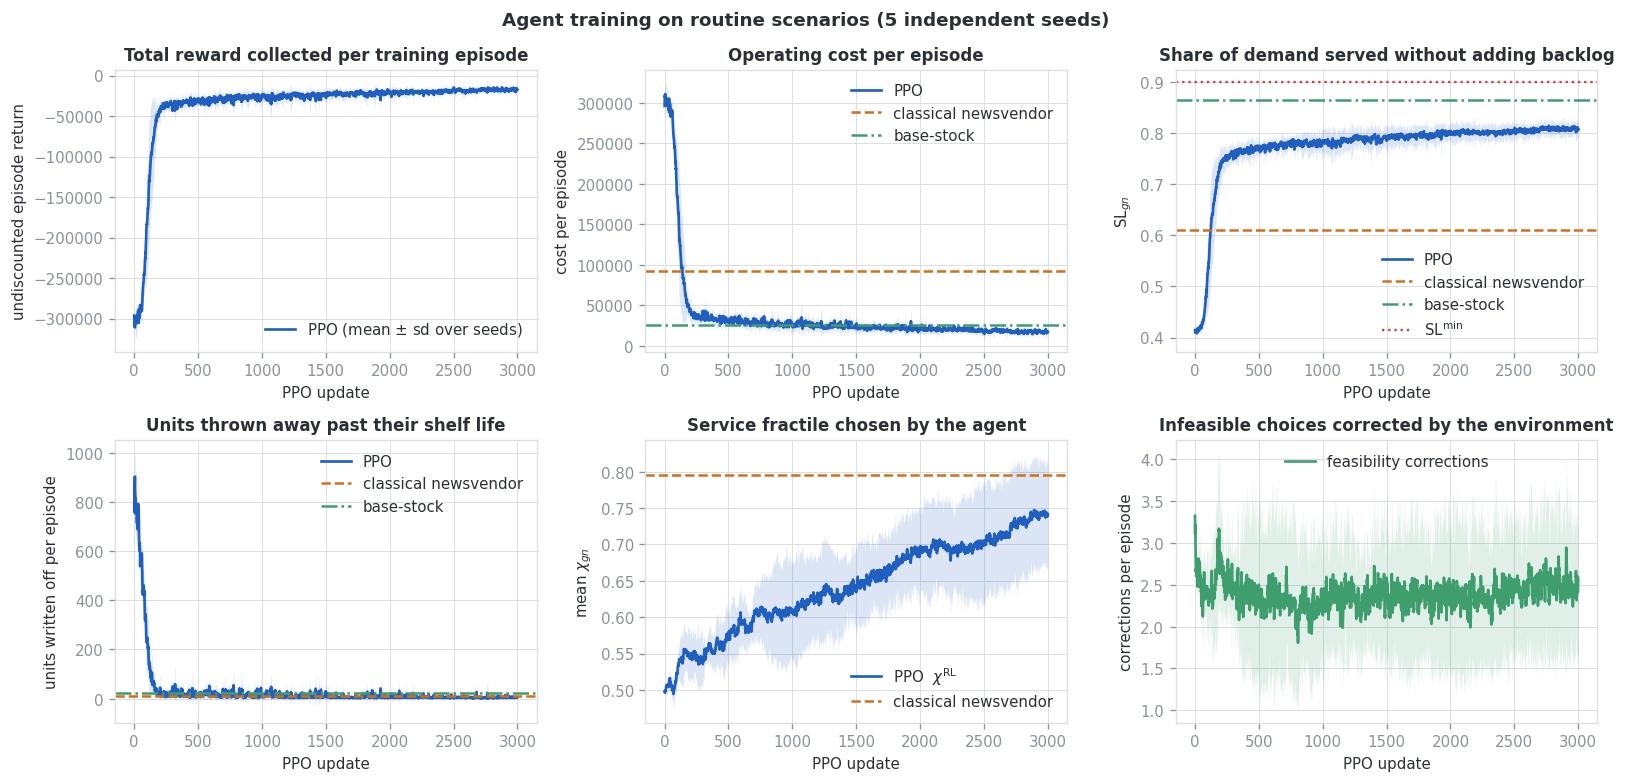

In [24]:
PALETTE = {
    "rl": "#1f5fbf", "rl_fill": "#1f5fbf", "nv": "#d1701c", "bs": "#3f9e6d",
    "grid": "#dcdfe4",
    "text": "#2b2f36", "muted": "#8b929c",
    "series": ["#1f5fbf", "#d1701c", "#3f9e6d", "#a24bbf", "#c8443c", "#7d8590"],
}
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "font.size": 9,
    "axes.edgecolor": PALETTE["grid"], "axes.labelcolor": PALETTE["text"],
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": PALETTE["grid"], "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": PALETTE["muted"], "ytick.color": PALETTE["muted"],
    "text.color": PALETTE["text"], "legend.frameon": False, "figure.facecolor": "white",
})


def band(ax, df, ycol, label, color, smooth: int = 5):
    """Mean +/- 1 sd across seeds (§3.8.5: dispersion, not the best run)."""
    piv = df.pivot_table(index="update", columns="seed", values=ycol)
    if smooth > 1:
        piv = piv.rolling(smooth, min_periods=1).mean()
    m, s = piv.mean(axis=1), piv.std(axis=1).fillna(0.0)
    ax.plot(piv.index, m, color=color, lw=1.6, label=label)
    ax.fill_between(piv.index, m - s, m + s, color=color, alpha=0.16, lw=0)


fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.6))

ax = axes[0, 0]
band(ax, HIST, "episode_return", "PPO (mean $\\pm$ sd over seeds)", PALETTE["rl"])
ax.set_title("Total reward collected per training episode")
ax.set_xlabel("PPO update"); ax.set_ylabel("undiscounted episode return"); ax.legend()

ax = axes[0, 1]
band(ax, HIST, "policy_cost_J", "PPO", PALETTE["rl"])
ax.axhline(NV_RESULTS["policy_cost_J"].mean(), color=PALETTE["nv"], ls="--", lw=1.5,
           label="classical newsvendor")
if "BS_RESULTS" in dir():
    ax.axhline(BS_RESULTS["policy_cost_J"].mean(), color=PALETTE["bs"], ls="-.", lw=1.5,
               label="base-stock")
ax.set_title("Operating cost per episode")
ax.set_xlabel("PPO update"); ax.set_ylabel("cost per episode"); ax.legend()

ax = axes[0, 2]
band(ax, HIST, "service_level", "PPO", PALETTE["rl"])
ax.axhline(NV_RESULTS["mean_service_level"].mean(), color=PALETTE["nv"], ls="--", lw=1.5,
           label="classical newsvendor")
if "BS_RESULTS" in dir():
    ax.axhline(BS_RESULTS["mean_service_level"].mean(), color=PALETTE["bs"], ls="-.", lw=1.5,
               label="base-stock")
ax.axhline(float(PRM.SLmin.mean()), color=PALETTE["series"][4], ls=":", lw=1.4,
           label="$\\mathrm{SL}^{\\min}$")
ax.set_title("Share of demand served without adding backlog")
ax.set_xlabel("PPO update"); ax.set_ylabel("$\\mathrm{SL}_{gn}$"); ax.legend()

ax = axes[1, 0]
band(ax, HIST, "expired", "PPO", PALETTE["rl"])
ax.axhline(NV_RESULTS["expired_units"].mean(), color=PALETTE["nv"], ls="--", lw=1.5,
           label="classical newsvendor")
if "BS_RESULTS" in dir():
    ax.axhline(BS_RESULTS["expired_units"].mean(), color=PALETTE["bs"], ls="-.", lw=1.5,
               label="base-stock")
ax.set_title("Units thrown away past their shelf life")
ax.set_xlabel("PPO update"); ax.set_ylabel("units written off per episode"); ax.legend()

ax = axes[1, 1]
band(ax, HIST, "fractile", "PPO  $\\chi^{\\mathrm{RL}}$", PALETTE["rl"])
_chi_nv = float(np.mean([e.chi_hist.mean() for e in NV_RESULTS.attrs["envs"]]))
ax.axhline(_chi_nv, color=PALETTE["nv"], ls="--", lw=1.5, label="classical newsvendor")
ax.set_title("Service fractile chosen by the agent")
ax.set_xlabel("PPO update"); ax.set_ylabel("mean $\\chi_{gn}$"); ax.legend()

ax = axes[1, 2]
band(ax, HIST, "corrections", "feasibility corrections", PALETTE["series"][2])
ax.set_title("Infeasible choices corrected by the environment")
ax.set_xlabel("PPO update"); ax.set_ylabel("corrections per episode"); ax.legend()

fig.suptitle("Agent training on routine scenarios "
             f"({len(SEEDS)} independent seeds)", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()


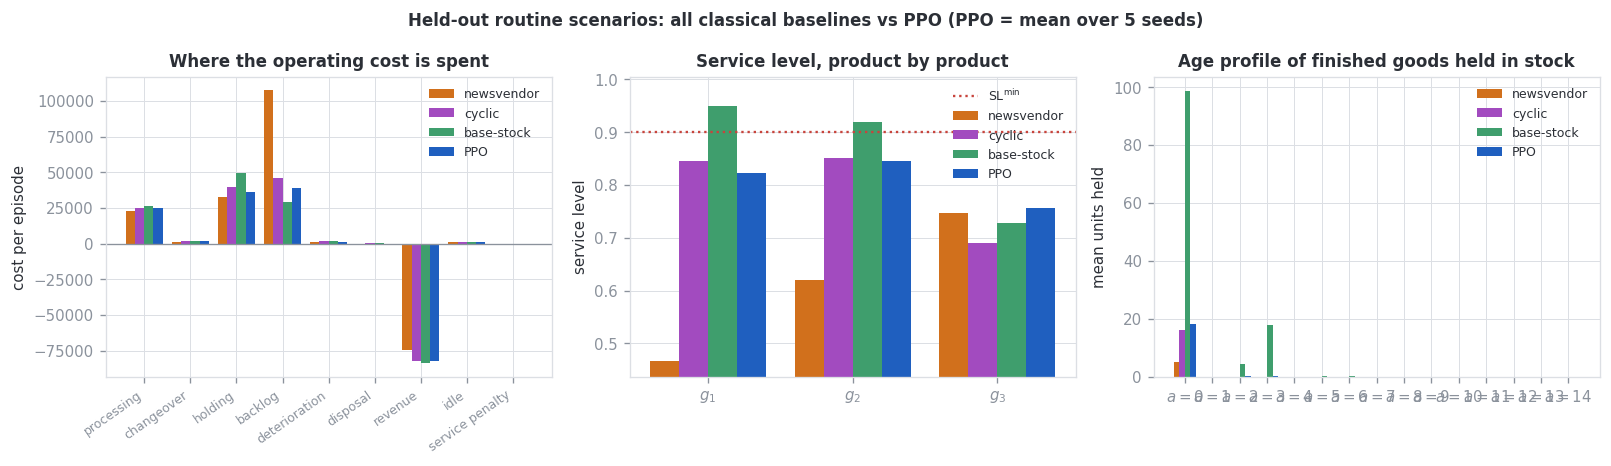

In [25]:
# Comparison figures. ALL classical baselines present in the notebook are shown --
_SERIES = [("newsvendor", PALETTE["nv"])]
if "cyclic" in breakdown.columns:
    _SERIES.append(("cyclic", PALETTE["series"][3]))
if "base-stock" in breakdown.columns:
    _SERIES.append(("base-stock", PALETTE["bs"]))
_SERIES.append(("PPO", PALETTE["rl"]))
_K = len(_SERIES)
_w = 0.8 / _K
_pos = [(_k - (_K - 1) / 2) * _w for _k in range(_K)]

_RESULTS_OF = {"newsvendor": NV_RESULTS}
if CYCLE_PLAN is not None:
    _RESULTS_OF["cyclic"] = CYC_RESULTS
if "BS_RESULTS" in dir():
    _RESULTS_OF["base-stock"] = BS_RESULTS


def _envs_of(name):
    """Episode environments for a policy; PPO pools every seed."""
    if name == "PPO":
        return [e for df in RL_RESULTS.values() for e in df.attrs["envs"]]
    return list(_RESULTS_OF[name].attrs["envs"])


fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

# --- cost decomposition of Eq (39) -------------------------------------------
ax = axes[0]
show = [c for c in cost_cols if abs(breakdown.loc[c]).max() > 1e-6]
x = np.arange(len(show))
for (_nm, _col), _p in zip(_SERIES, _pos):
    ax.bar(x + _p, breakdown.loc[show, _nm], _w, color=_col, label=_nm)
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in show], fontsize=7.5, rotation=35, ha="right")
ax.axhline(0, color=PALETTE["muted"], lw=0.8)
ax.set_title("Where the operating cost is spent"); ax.set_ylabel("cost per episode"); ax.legend(fontsize=7.5)

# --- service level per product ------------------------------------------------
ax = axes[1]
x = np.arange(INST.G)
_sl = {nm: np.stack([e.SL.mean(axis=1) for e in _envs_of(nm)]).mean(axis=0)
       for nm, _ in _SERIES}
for (_nm, _col), _p in zip(_SERIES, _pos):
    ax.bar(x + _p, _sl[_nm], _w, color=_col, label=_nm)
ax.axhline(float(PRM.SLmin.mean()), color=PALETTE["series"][4], ls=":", lw=1.4,
           label="$\\mathrm{SL}^{\\min}$")
ax.set_xticks(x); ax.set_xticklabels([f"$g_{{{g+1}}}$" for g in range(INST.G)])
ax.set_ylim(min(0.75, min(v.min() for v in _sl.values())) - 0.03, 1.005)
ax.set_title("Service level, product by product"); ax.set_ylabel("service level")
ax.legend(fontsize=7.5)

# --- final-stage age-class mix -------------------------------------------------
ax = axes[2]
x = np.arange(INST.A)
for (_nm, _col), _p in zip(_SERIES, _pos):
    _age = np.stack([e.age_hist.mean(axis=0) for e in _envs_of(_nm)]).mean(axis=0)
    ax.bar(x + _p, _age, _w, color=_col, label=_nm)
ax.set_xticks(x); ax.set_xticklabels([f"$a={a}$" for a in range(INST.A)])
ax.set_title("Age profile of finished goods held in stock")
ax.set_ylabel("mean units held"); ax.legend(fontsize=7.5)

fig.suptitle("Held-out routine scenarios: all classical baselines vs PPO "
             f"(PPO = mean over {len(SEEDS)} seeds)", fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()


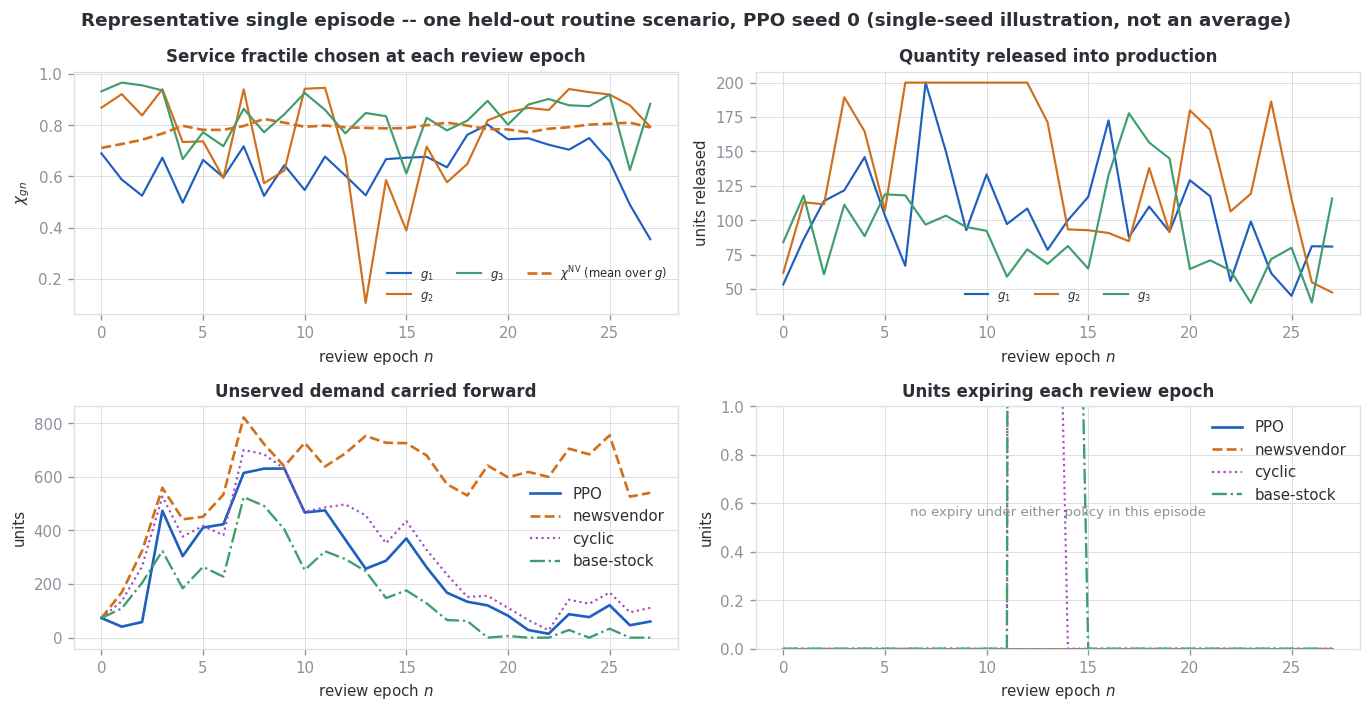

In [26]:
# --- ONE held-out episode under the seed-0 policy: fractile, release, backlog ---
_env_rl = RL_RESULTS[SEEDS[0]].attrs["envs"][0]
_env_nv = NV_RESULTS.attrs["envs"][0]
_env_cy = CYC_RESULTS.attrs["envs"][0] if CYCLE_PLAN is not None else None
_env_bs = BS_RESULTS.attrs["envs"][0] if "BS_RESULTS" in dir() else None
_ep = np.arange(INST.N)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.0))

ax = axes[0, 0]
for g in range(INST.G):
    ax.plot(_ep, _env_rl.chi_hist[g], color=PALETTE["series"][g % 6], lw=1.3,
            label=f"$g_{{{g+1}}}$")
ax.plot(_ep, _env_nv.chi_hist.mean(axis=0), color=PALETTE["nv"], ls="--", lw=1.6,
        label="$\\chi^{\\mathrm{NV}}$ (mean over $g$)")
ax.set_title("Service fractile chosen at each review epoch")
ax.set_xlabel("review epoch $n$"); ax.set_ylabel("$\\chi_{gn}$")
ax.legend(ncol=3, fontsize=7)

ax = axes[0, 1]
for g in range(INST.G):
    ax.plot(_ep, _env_rl.V_hist[g], color=PALETTE["series"][g % 6], lw=1.3, label=f"$g_{{{g+1}}}$")
ax.set_title("Quantity released into production")
ax.set_xlabel("review epoch $n$"); ax.set_ylabel("units released")
ax.legend(ncol=3, fontsize=7)

ax = axes[1, 0]
ax.plot(_ep, _env_rl.L_hist.sum(axis=0), color=PALETTE["rl"], lw=1.6, label="PPO")
ax.plot(_ep, _env_nv.L_hist.sum(axis=0), color=PALETTE["nv"], lw=1.6, ls="--", label="newsvendor")
if _env_cy is not None:
    ax.plot(_ep, _env_cy.L_hist.sum(axis=0), color=PALETTE["series"][3], lw=1.3, ls=":",
            label="cyclic")
if _env_bs is not None:
    ax.plot(_ep, _env_bs.L_hist.sum(axis=0), color=PALETTE["bs"], lw=1.4, ls="-.", label="base-stock")
ax.set_title("Unserved demand carried forward")
ax.set_xlabel("review epoch $n$"); ax.set_ylabel("units"); ax.legend()

ax = axes[1, 1]
ax.plot(_ep, _env_rl.expired_hist, color=PALETTE["rl"], lw=1.6, label="PPO")
ax.plot(_ep, _env_nv.expired_hist, color=PALETTE["nv"], lw=1.6, ls="--", label="newsvendor")
if _env_cy is not None:
    ax.plot(_ep, _env_cy.expired_hist, color=PALETTE["series"][3], lw=1.3, ls=":",
            label="cyclic")
if _env_bs is not None:
    ax.plot(_ep, _env_bs.expired_hist, color=PALETTE["bs"], lw=1.4, ls="-.", label="base-stock")
ax.set_title("Units expiring each review epoch")
ax.set_xlabel("review epoch $n$"); ax.set_ylabel("units"); ax.legend()
if max(_env_rl.expired_hist.max(), _env_nv.expired_hist.max()) < 1e-6:
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.55, "no expiry under either policy in this episode",
            transform=ax.transAxes, ha="center", color=PALETTE["muted"], fontsize=8)
else:
    ax.set_ylim(bottom=0)

fig.suptitle(f"Representative single episode -- one held-out routine scenario, "
             f"PPO seed {SEEDS[0]} (single-seed illustration, not an average)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()


## 10. Constraint audit

A full episode is replayed with the audit log switched on and every structural constraint
of §3.4–§3.5 is checked numerically against the recorded trajectory.

In [27]:
def audit_episode(policy, scenario: Scenario) -> pd.DataFrame:
    env = make_env(); env.audit = True
    obs = env.reset(scenario)
    done = False
    while not done:
        obs, _, done, _ = env.step_micro(policy(env, obs))

    inst, p = env.inst, env.prm
    checks: Dict[str, float] = {}

    def worst(name, v):
        checks[name] = max(checks.get(name, 0.0), float(v))

    for rec in env.audit_log:
        S, P, U, Q, X = rec["S"], rec["P"], rec["U"], rec["Q"], rec["X"]
        Gam, assign, chg = rec["surv_frac"], rec["assign"], rec["chg"]
        cap = rec["Cbar"] * rec["avail"]

        worst("Eq (13)  0 <= U <= Gamma S", np.max(U - Gam * S))
        worst("Eq (13)  U >= 0", np.max(-U))
        for g in range(inst.G):                                   # Eq (14)
            worst("Eq (14)  U = 0 at the final stage during intervals",
                  np.max(U[g, inst.final_stage[g]]))
        for g in range(inst.G):                                   # Eq (18)
            for j in range(1, inst.Jg[g]):
                worst("Eq (18)  sum_e P_{gje} = sum_a U_{g,j-1,a}",
                      abs(P[g, j].sum() - U[g, j - 1].sum()))
        worst("Eq (20)  sum_e P_{g1e} <= K_{ghn}",
              np.max(P[:, 0, :].sum(axis=1) - rec["K"]))
        worst("Eq (30)  P <= M A",
              max((P[g, j, e] for g in range(inst.G) for j in range(inst.Jmax)
                   for e in range(inst.E) if assign[e] != g and P[g, j, e] > 0), default=0.0))
        worst("Eq (31)  sum_g A_{ge} <= a_{ehn}",
              max([1.0 - rec["avail"][e] for e in range(inst.E) if assign[e] >= 0], default=0.0))
        proc = np.einsum("gje,gje->e", np.where(p.tau > 1e5, 0.0, p.tau), P)
        setup = np.einsum("gpe,gpe->e", p.upsilon, chg)
        worst("Eq (32)  tau P + upsilon C <= Cbar a", np.max(proc + setup - cap))
        worst("Eq (33)  C >= A_{ge,h,n} + A_{ge,h-,n-} - 1",
              max([1.0 - chg[assign[e], rec["prev"][e], e]
                   for e in range(inst.E)
                   if assign[e] >= 0 and rec["prev"][e] >= 0 and assign[e] != rec["prev"][e]],
                  default=0.0))
        worst("Eq (34)  sum psi P <= Rbar",
              float(np.einsum("gje,gje->", p.psi, P)) - rec["Rbar"])
        worst("Eq (35)  sum_e sum_g A <= Wbar", float((assign >= 0).sum()) - rec["Wbar"])
        worst("Eq (36)  Z >= 0", np.max(-rec["Z"]))
        worst("Eq (37)  C in {0,1}", np.max(np.abs(chg - np.round(chg))))
        worst("Eq (38)  P, S, Q, X >= 0",
              max(np.max(-P), np.max(-S), np.max(-Q), np.max(-X)))
        # aging: Eq (16)/(23) and Eq (15)/(22)
        for g in range(inst.G):
            for j in range(inst.Jg[g]):
                ab = inst.abar[g, j]
                lhs = rec["S_next"][g, j, 1:ab + 1]
                rhs = (Gam[g, j, :ab] * S[g, j, :ab] - U[g, j, :ab])
                worst("Eqs (16),(23)  S_{a+1} = Gamma S_a - U_a", np.max(np.abs(lhs - rhs)))
                worst("Eqs (15),(22)  S_0 = sum_e P",
                      abs(rec["S_next"][g, j, 0] - P[g, j].sum()))
                worst("Eq (17)  X = Gamma S_abar - U_abar",
                      abs(X[g, j] - (Gam[g, j, ab] * S[g, j, ab] - U[g, j, ab])))
                worst("Eq (12)  Q = (1 - Gamma) S",
                      np.max(np.abs(Q[g, j, :ab + 1]
                                    - (1 - Gam[g, j, :ab + 1]) * S[g, j, :ab + 1])))

    # epoch-level identities
    for g in range(inst.G):
        for n in range(inst.N):
            worst("Eq (11)  0 <= Gamma <= 1", 0.0)
            worst("Eq (29)  SL <= 1", env.SL[g, n] - 1.0)
    L = env.L_hist
    for g in range(inst.G):
        for n in range(inst.N):
            Lprev = L[g, n - 1] if n > 0 else 0.0
            F_implied = Lprev + scenario.demand[g, n] - L[g, n]
            worst("Eq (25)  0 <= F <= L_{n-1} + D", max(-F_implied,
                                                        F_implied - (Lprev + scenario.demand[g, n])))
    worst("Eq (38)  L >= 0", float(np.max(-L)))
    # Eq (9): release feasibility
    V, O = env.V_hist, (env.V_hist > 0).astype(float)
    worst("Eq (9)  ell O <= V <= u O",
          float(max(np.max(p.ell[:, None] * O - V), np.max(V - p.umax[:, None] * O))))

    return pd.DataFrame({"max violation": pd.Series(checks)}).sort_index()


_audit = audit_episode(lambda env, obs, _t=TRAINERS[0]: _t.act(env, obs), EVAL_SCENARIOS[0])
print(f"Constraint audit of ONE full PPO episode -- seed {TRAINERS[0].seed}, held-out "
      f"scenario 0 (single-seed check, all values should be <= 1e-6)\n")
display(_audit.round(10))
assert _audit["max violation"].max() < 1e-6, "a structural constraint was violated"
print("\nall structural constraints of Eqs (9)-(38) hold along the trajectory")


Constraint audit of ONE full PPO episode -- seed 0, held-out scenario 0 (single-seed check, all values should be <= 1e-6)



,max violation
Eq (11) 0 <= Gamma <= 1,0.0
Eq (12) Q = (1 - Gamma) S,0.0
Eq (13) 0 <= U <= Gamma S,0.0
Eq (13) U >= 0,0.0
Eq (14) U = 0 at the final stage during intervals,0.0
Eq (17) X = Gamma S_abar - U_abar,0.0
"Eq (18) sum_e P_{gje} = sum_a U_{g,j-1,a}",0.0
Eq (20) sum_e P_{g1e} <= K_{ghn},0.0
Eq (25) 0 <= F <= L_{n-1} + D,0.0
Eq (29) SL <= 1,0.0



all structural constraints of Eqs (9)-(38) hold along the trajectory


## 11. Export

In [28]:
comparison.round(6).to_csv("results_comparison.csv")
breakdown.round(6).to_csv("results_cost_breakdown.csv")
HIST.to_csv("training_history.csv", index=False)
RL_ALL.to_csv("evaluation_ppo.csv", index=False)
NV_RESULTS.to_csv("evaluation_newsvendor.csv", index=False)
if CYCLE_PLAN is not None:
    CYC_RESULTS.to_csv("evaluation_cyclic.csv", index=False)
if "BS_RESULTS" in dir():
    BS_RESULTS.to_csv("evaluation_base_stock.csv", index=False)
FILL.to_csv("service_fill_rate.csv")
_audit.to_csv("constraint_audit.csv")

for tr in TRAINERS:
    torch.save({"state_dict": tr.net.state_dict(),
                "obs_mean": tr.obs_rms.mean, "obs_var": tr.obs_rms.var,
                "ret_mean": tr.ret_rms.mean, "ret_var": tr.ret_rms.var,
                "config": tr.cfg.__dict__,
                "instance": f"G={INST.G} E={INST.E} N={INST.N} H={INST.H} "
                            f"Upsilon={INST.Upsilon} warm_start={WARM_START}"},
               f"ppo_newsvendor_seed{tr.seed}.pt")

print("written:")
for f in ["results_comparison.csv", "results_cost_breakdown.csv", "training_history.csv",
          "evaluation_ppo.csv", "evaluation_newsvendor.csv", "evaluation_cyclic.csv",
          "service_fill_rate.csv", "constraint_audit.csv"] + \
         [f"ppo_newsvendor_seed{t.seed}.pt" for t in TRAINERS]:
    print("  ", f)


written:
   results_comparison.csv
   results_cost_breakdown.csv
   training_history.csv
   evaluation_ppo.csv
   evaluation_newsvendor.csv
   evaluation_cyclic.csv
   service_fill_rate.csv
   constraint_audit.csv
   ppo_newsvendor_seed0.pt
   ppo_newsvendor_seed1.pt
   ppo_newsvendor_seed2.pt
   ppo_newsvendor_seed3.pt
   ppo_newsvendor_seed4.pt


## 13. Final deliverables — 4 tables and 6 figures



Table 1. Performance on 24 held-out routine scenarios, 4 policies. MDRL averaged over 5 independent seeds. The last columns are SIGNED RELATIVE CHANGES of MDRL with respect to each baseline, not gains: for cost, backlog and expired units a positive value means MDRL is worse. An empty cell means the baseline is zero and the percentage is undefined.


,Classical newsvendor,Cyclic rotation,Base-stock,Proposed MDRL,MDRL s.d. over seeds,Relative change vs newsvendor (%),Relative change vs cyclic (%),Relative change vs base-stock (%)
"Policy cost J, Eq (40)",92440.560,33568.110,26253.542,22808.729,2871.163,-75.326,-32.052,-13.121
"Service level, Eq (29)",0.611,0.795,0.865,0.808,0.018,32.061,1.526,-6.700
"Service level, weakest product",0.458,0.690,0.729,0.746,0.017,62.940,8.180,2.367
Fraction of epochs meeting SL_min,0.497,0.684,0.786,0.681,0.032,37.203,-0.334,-13.350
"Mean backlog, Eq (28)",256.161,110.015,68.734,93.425,6.488,-63.529,-15.080,35.922
"Expired units, Eq (17)",10.976,19.614,23.063,4.245,5.231,-61.324,-78.357,-81.594
"Deteriorated units, Eq (12)",168.994,220.643,275.120,191.318,9.196,13.210,-13.291,-30.460
Service fractile chi,0.795,0.759,NaN,0.752,0.056,-5.450,-0.953,NaN



Table 2. Decomposition of the operating cost of Eq (39) and the service term of Eq (40), per episode.


,Classical newsvendor,Cyclic rotation,Base-stock,Proposed MDRL,Change vs newsvendor,Change vs cyclic,Change vs base-stock
Processing,22694.9,25247.0,26263.8,25163.8,2468.9,-83.2,-1100.0
Changeover,1278.3,1943.8,1943.8,2077.8,799.5,134.1,134.1
Holding,32727.7,39822.5,49771.5,36523.2,3795.4,-3299.4,-13248.3
Backlog,107587.8,46206.4,28868.5,39238.7,-68349.2,-6967.8,10370.2
Deterioration,1183.0,1544.5,1925.8,1339.2,156.3,-205.3,-586.6
Disposal,76.8,137.3,161.4,29.7,-47.1,-107.6,-131.7
Revenue,-74363.5,-82419.6,-83709.0,-82645.8,-8282.3,-226.3,1063.2
Idle,1227.2,1071.9,1018.4,1069.0,-158.3,-2.9,50.6
Service penalty,28.2,14.2,9.3,13.2,-15.0,-1.0,3.8



Table 4a. Out-of-sample robustness on 180 held-out disruption scenarios, Eqs (59)-(62).


,E_D[J] Eq (59),CVaR_0.8 Eq (60),DRS_0.1 Eq (61),worst-case J,min SL Eq (62),mean SL,expired,Xi^rec (epochs),never recovered %
policy,,,,,,,,,
newsvendor,82906.178,132620.120,98484.508,189003.098,0.313,0.610,17.491,13.989,90.000
cyclic,41451.832,83235.822,56341.720,157715.931,0.494,0.768,43.619,12.294,30.556
base-stock,29745.812,65716.510,41665.436,123614.119,0.519,0.842,49.523,11.478,22.778
newsvendor-cap,83446.396,134342.528,98963.596,189359.971,0.307,0.610,17.521,14.011,91.667
PPO seed 0,28304.854,62019.246,41820.961,137072.683,0.589,0.790,14.521,11.800,28.889
PPO seed 1,32592.854,75389.700,58831.990,265070.710,0.235,0.777,29.494,11.589,29.444
PPO seed 2,30658.165,67466.029,49058.048,186611.344,0.526,0.777,13.493,11.911,29.444
PPO seed 3,34425.732,71020.951,56811.769,231750.063,0.435,0.760,16.655,12.367,31.667
PPO seed 4,30380.548,66551.056,44591.831,145211.545,0.598,0.789,17.479,11.889,28.333



Table 4b. Sensitivity of the conditional value-at-risk of Eq (60) to the confidence level beta.


,newsvendor,cyclic,base-stock,newsvendor-cap,PPO seed 0,PPO seed 1,PPO seed 2,PPO seed 3,PPO seed 4,scenarios en queue
beta = 0.50,108725.2,61775.3,46380.9,109707.3,44292.0,51158.3,47586.4,49828.0,47018.7,90
beta = 0.60,115207.4,67111.5,50925.3,116334.0,48663.8,56630.0,52373.6,54548.7,51798.0,72
beta = 0.70,122889.8,73857.2,56779.2,124126.9,54170.6,63946.2,58290.0,61091.5,57837.0,54
beta = 0.80,132620.1,83235.8,65716.5,134342.5,62019.2,75389.7,67466.0,71021.0,66551.1,36
beta = 0.85,138321.2,89310.6,71740.3,140499.8,68042.8,84341.3,74293.8,78083.3,72218.8,27
beta = 0.90,146181.4,97299.2,79897.7,149306.6,75920.6,98594.2,84649.9,89090.7,80467.0,18


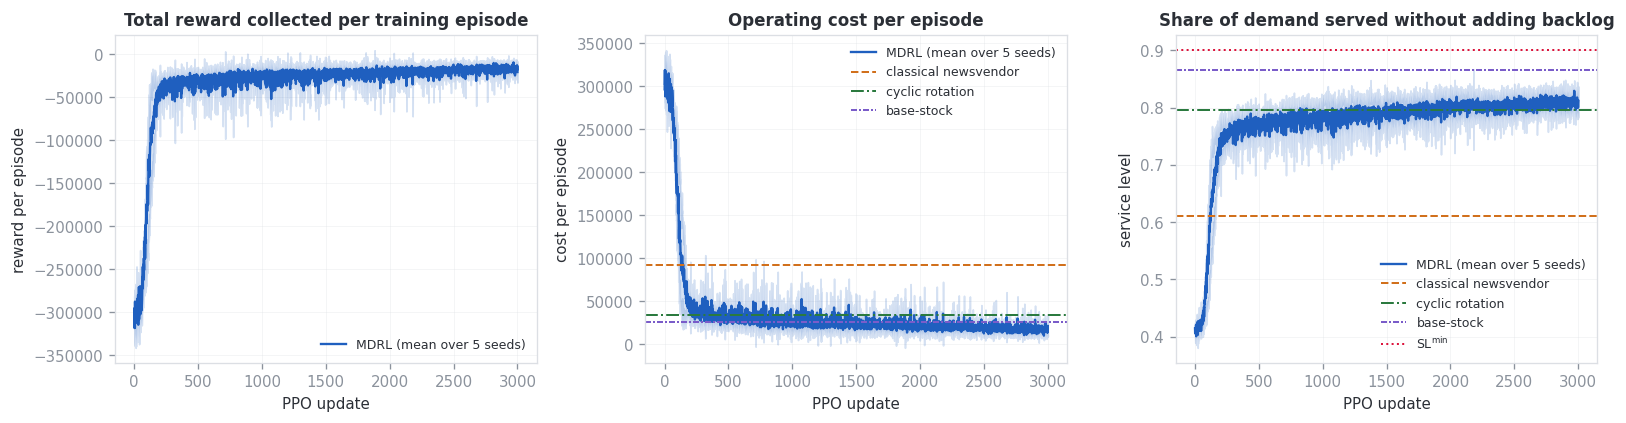

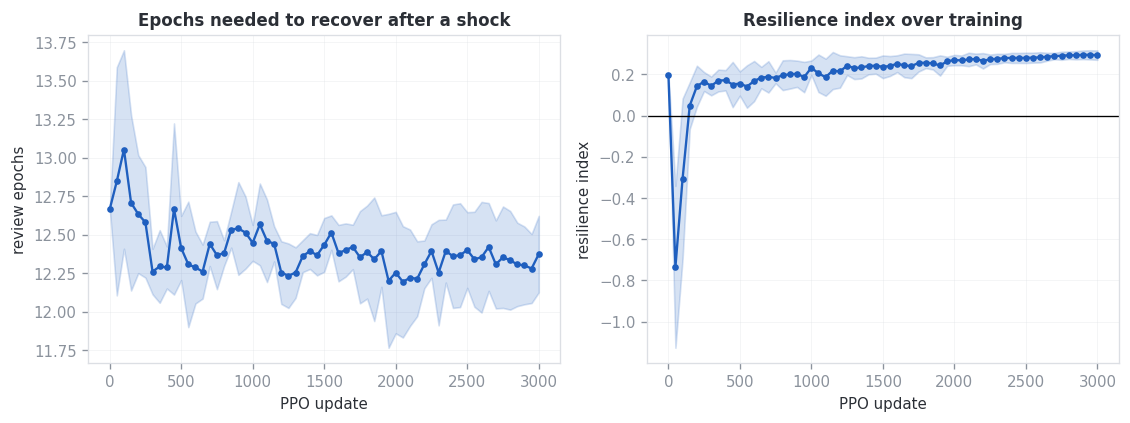

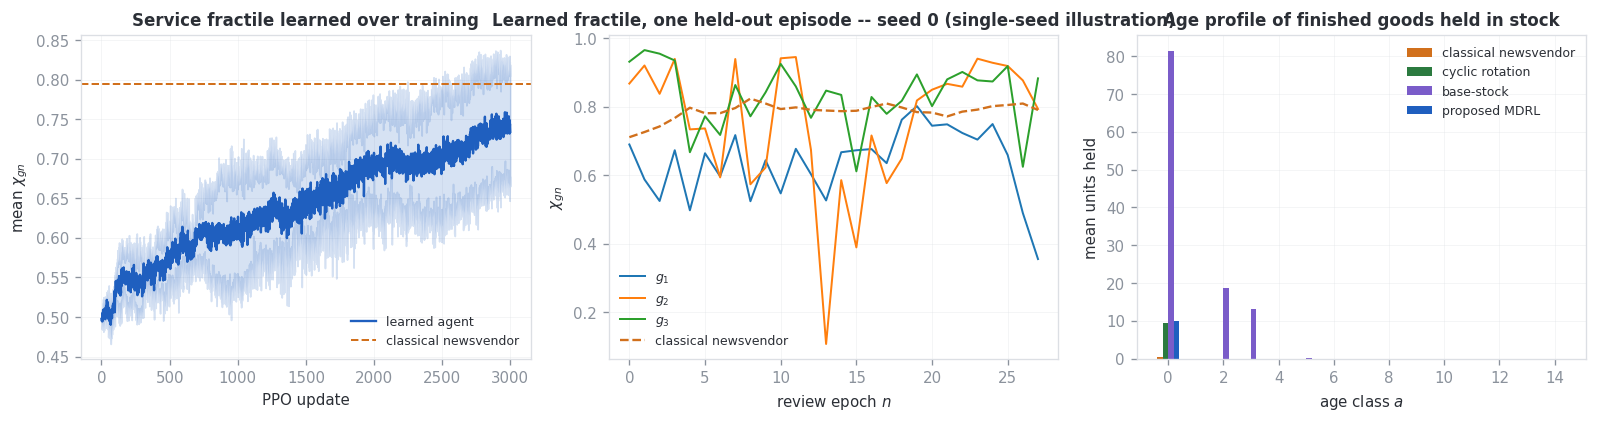

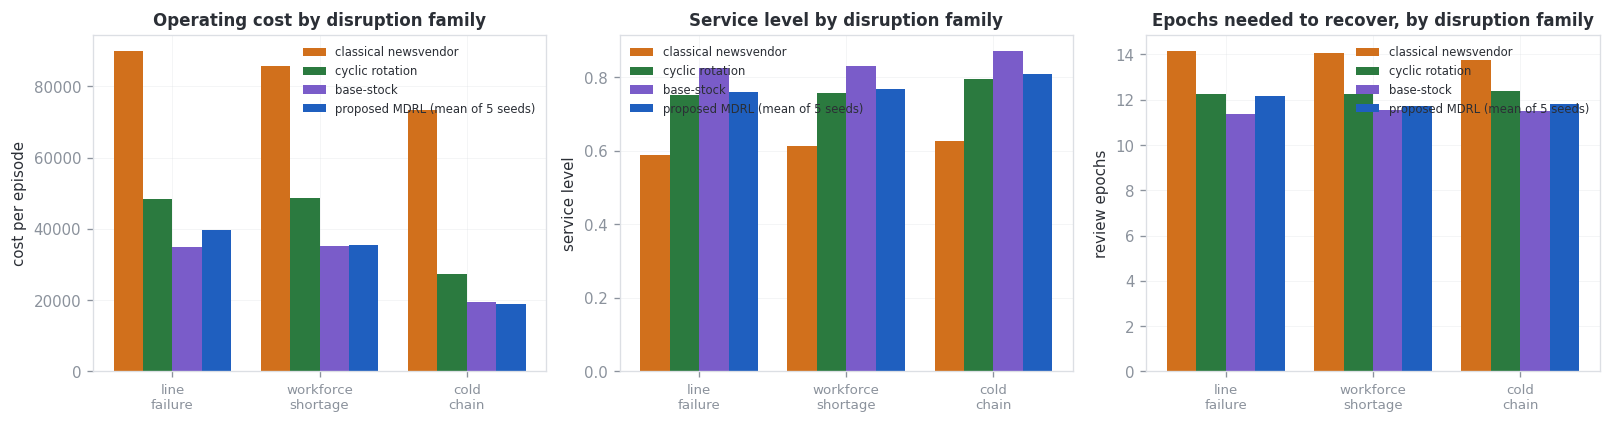

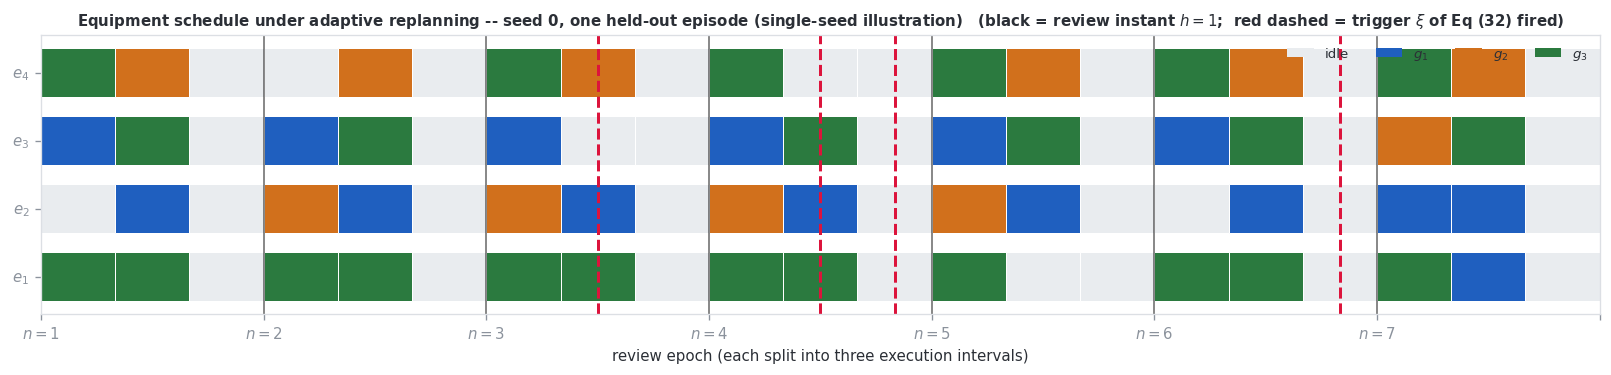

  plan set at 28 review instants, trigger xi of Eq (32) fired 19 times over 28 epochs (PLAN_COMMITMENT = False)


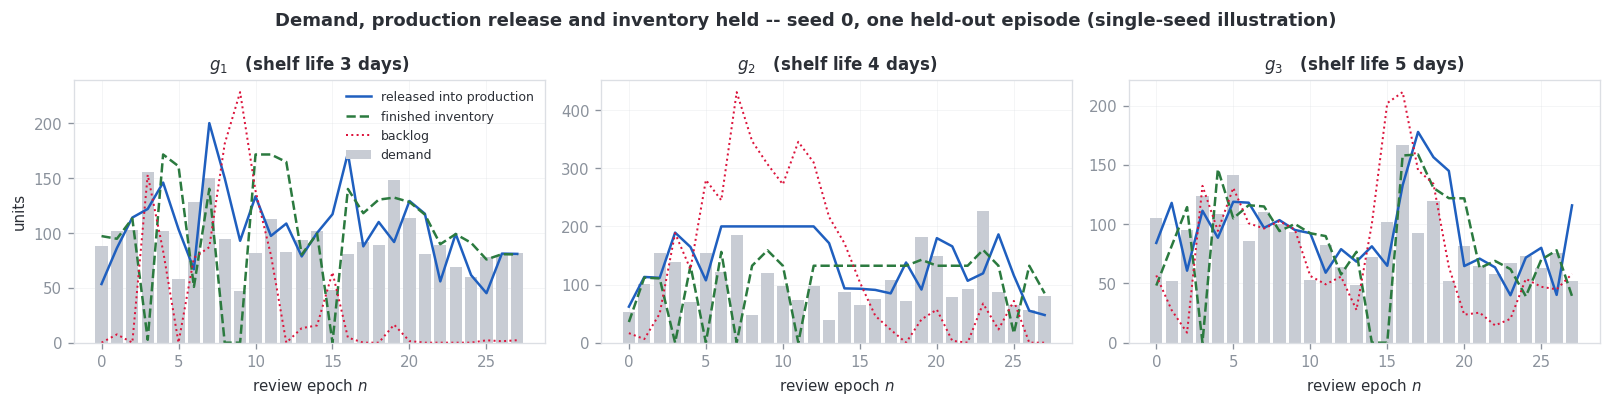


DELIVERABLES WRITTEN TO ./deliverables/
    figure1_training.png
    figure2_robustness_training.png
    figure3_fractile_and_age.png
    figure4_disruption_families.png
    figure5_committed_plan.png
    figure6_demand_release_inventory.png
    table1_performance.csv
    table1_performance.tex
    table2_cost_decomposition.csv
    table2_cost_decomposition.tex
    table4a_robustness.csv
    table4a_robustness.tex
    table4b_cvar_sensitivity.csv
    table4b_cvar_sensitivity.tex


In [29]:
# 13. FINAL DELIVERABLES -- 4 tables + 6 figures, ready for Section 4
import os
os.makedirs("deliverables", exist_ok=True)
P = "deliverables/"

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.titlesize": 10,
                     "axes.titleweight": "bold", "savefig.bbox": "tight"})
C_NV, C_CY, C_RL = "#d1701c", "#2b7a3f", "#1f5fbf"
C_BS = "#7a5cc9"


def _save(df, name, caption, float_fmt="%.3f"):
    df.to_csv(P + name + ".csv")
    with open(P + name + ".tex", "w") as f:
        f.write(df.to_latex(float_format=float_fmt, caption=caption,
                            label="tab:" + name, escape=True))
    print(f"\n{'='*78}\n{caption}\n{'='*78}")
    display(df)


# ---------------------------------------------------------------- TABLE 1 ----
_m = ["policy_cost_J", "mean_service_level", "min_service_level",
      "service_target_met", "mean_backlog", "expired_units",
      "deteriorated_units", "mean_fractile"]
_lbl = {"policy_cost_J": "Policy cost  J,  Eq (40)",
        "mean_service_level": "Service level,  Eq (29)",
        "min_service_level": "Service level, weakest product",
        "service_target_met": "Fraction of epochs meeting SL_min",
        "mean_backlog": "Mean backlog,  Eq (28)",
        "expired_units": "Expired units,  Eq (17)",
        "deteriorated_units": "Deteriorated units,  Eq (12)",
        "mean_fractile": "Service fractile  chi"}
_rl_seed = RL_ALL.groupby("seed")[_m].mean()
_t1 = {"Classical newsvendor": NV_RESULTS[_m].mean(),
       "Cyclic rotation": CYC_RESULTS[_m].mean()}
if "BS_RESULTS" in dir():
    _t1["Base-stock"] = BS_RESULTS[_m].mean()
_t1["Proposed MDRL"] = _rl_seed.mean()
_t1["MDRL s.d. over seeds"] = _rl_seed.std()
T1 = pd.DataFrame(_t1)
_d1, _d2 = T1["Classical newsvendor"].abs(), T1["Cyclic rotation"].abs()
# NOT a "gain": this is a signed RELATIVE CHANGE of MDRL with respect to the baseline
T1["Relative change vs newsvendor (%)"] = \
    100 * (T1["Proposed MDRL"] - T1["Classical newsvendor"]) / _d1.where(_d1 > 1e-9)
T1["Relative change vs cyclic (%)"] = \
    100 * (T1["Proposed MDRL"] - T1["Cyclic rotation"]) / _d2.where(_d2 > 1e-9)
if "Base-stock" in T1.columns:
    _d3 = T1["Base-stock"].abs()
    T1["Relative change vs base-stock (%)"] = \
        100 * (T1["Proposed MDRL"] - T1["Base-stock"]) / _d3.where(_d3 > 1e-9)
T1.index = [_lbl[i] for i in T1.index]
_n_pol_t1 = sum(k in T1.columns for k in
                ["Classical newsvendor", "Cyclic rotation", "Base-stock"]) + 1
_save(T1.round(3), "table1_performance",
      f"Table 1. Performance on {len(EVAL_SCENARIOS)} held-out routine scenarios, "
      f"{_n_pol_t1} policies. MDRL averaged over {len(SEEDS)} independent seeds. "
      "The last columns are SIGNED RELATIVE CHANGES of MDRL with respect to each "
      "baseline, not gains: for cost, backlog and expired units a positive value "
      "means MDRL is worse. An empty cell means the baseline is zero and the "
      "percentage is undefined.")

# ---------------------------------------------------------------- TABLE 2 ----
_cc = COST_KEYS + ["service_penalty"]
_t2 = {"Classical newsvendor": NV_RESULTS[_cc].mean(),
       "Cyclic rotation": CYC_RESULTS[_cc].mean()}
if "BS_RESULTS" in dir():
    _t2["Base-stock"] = BS_RESULTS[_cc].mean()
_t2["Proposed MDRL"] = RL_ALL.groupby("seed")[_cc].mean().mean()
T2 = pd.DataFrame(_t2)
T2["Change vs newsvendor"] = T2["Proposed MDRL"] - T2["Classical newsvendor"]
T2["Change vs cyclic"] = T2["Proposed MDRL"] - T2["Cyclic rotation"]
if "Base-stock" in T2.columns:
    T2["Change vs base-stock"] = T2["Proposed MDRL"] - T2["Base-stock"]
T2.index = [i.replace("_", " ").capitalize() for i in T2.index]
_save(T2.round(1), "table2_cost_decomposition",
      "Table 2. Decomposition of the operating cost of Eq (39) and the service "
      "term of Eq (40), per episode.", "%.1f")

# ---------------------------------------------------------------- TABLE 3 ----
if "ABLATION" in dir():
    T3 = ABLATION[["cost_J", "service", "worst_service", "RI", "recovery",
                   "expired", "fractile"]].copy()
    T3.columns = ["Cost J", "Service level", "Worst-case service",
                  "Robustness index", "Recovery time (epochs)",
                  "Expired units", "Fractile chi"]
    _save(T3.round(3), "table3_ablation",
          "Table 3. Contribution of each component of the proposed method. "
          "ONE SEED PER VARIANT (single-seed measurements, not seed averages), "
          "identical training budget.")

# ---------------------------------------------------------------- TABLE 4 ----
T4 = PARETO.copy()
T4a = sweep.copy()
_save(T4.round(3), "table4a_robustness",
      "Table 4a. Out-of-sample robustness on 180 held-out disruption scenarios, "
      "Eqs (59)-(62).")
_save(T4a.round(1), "table4b_cvar_sensitivity",
      "Table 4b. Sensitivity of the conditional value-at-risk of Eq (60) to the "
      "confidence level beta.", "%.1f")

# --------------------------------------------------------------- FIGURE 1 ----
_h = HIST.groupby("update")
_mu, _sd = _h.mean(numeric_only=True), _h.std(numeric_only=True)
_x = _mu.index.values
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
for a, (col, ttl, ylab) in zip(ax, [
        ("episode_return", "Total reward collected per training episode",
         "reward per episode"),
        ("policy_cost_J",  "Operating cost per episode",
         "cost per episode"),
        ("service_level",  "Share of demand served without adding backlog",
         "service level")]):
    a.plot(_x, _mu[col], color=C_RL, lw=1.4, label=f"MDRL (mean over {len(SEEDS)} seeds)")
    a.fill_between(_x, _mu[col] - _sd[col], _mu[col] + _sd[col], color=C_RL, alpha=.18)
    a.set_title(ttl); a.set_xlabel("PPO update"); a.set_ylabel(ylab)
_HAS_BS = "BS_RESULTS" in dir()
for a, key in ((ax[1], "policy_cost_J"), (ax[2], "mean_service_level")):
    a.axhline(NV_RESULTS[key].mean(), ls="--", color=C_NV, lw=1.2, label="classical newsvendor")
    a.axhline(CYC_RESULTS[key].mean(), ls="-.", color=C_CY, lw=1.2, label="cyclic rotation")
    if _HAS_BS:      # the strongest classical baseline must appear on the figure too
        a.axhline(BS_RESULTS[key].mean(), ls=(0, (3, 1, 1, 1)), color=C_BS, lw=1.2,
                  label="base-stock")
ax[2].axhline(float(PRM.SLmin.mean()), ls=":", color="crimson", lw=1.2, label=r"$\mathrm{SL}^{\min}$")
for a in ax: a.legend(fontsize=7.5)
plt.tight_layout(); plt.savefig(P + "figure1_training.png"); plt.show()

# --------------------------------------------------------------- FIGURE 2 ----
_rb = HIST.dropna(subset=["rb_RI"]) if "rb_RI" in HIST.columns else None
if _rb is not None and len(_rb):
    _g = _rb.groupby("update"); _m2, _s2 = _g.mean(numeric_only=True), _g.std(numeric_only=True)
    fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
    for a, (col, ttl, ylab) in zip(ax, [
            ("rb_recovery", "Epochs needed to recover after a shock",
             "review epochs"),
            ("rb_RI", "Resilience index over training", "resilience index")]):
        a.plot(_m2.index, _m2[col], "o-", ms=3, color=C_RL, lw=1.4)
        a.fill_between(_m2.index, _m2[col] - _s2[col], _m2[col] + _s2[col],
                       color=C_RL, alpha=.18)
        a.set_title(ttl); a.set_xlabel("PPO update"); a.set_ylabel(ylab)
    ax[1].axhline(0, color="k", lw=.8)
    plt.tight_layout(); plt.savefig(P + "figure2_robustness_training.png"); plt.show()

# --------------------------------------------------------------- FIGURE 3 ----
_env_rl = RL_RESULTS[TRAINERS[0].seed].attrs["envs"][0]
_env_nv = NV_RESULTS.attrs["envs"][0]
_env_cy = CYC_RESULTS.attrs["envs"][0]
_env_bs = BS_RESULTS.attrs["envs"][0] if "BS_RESULTS" in dir() else None
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].plot(_x, _mu["fractile"], color=C_RL, lw=1.4, label="learned agent")
ax[0].fill_between(_x, _mu["fractile"] - _sd["fractile"], _mu["fractile"] + _sd["fractile"],
                   color=C_RL, alpha=.18)
ax[0].axhline(NV_RESULTS["mean_fractile"].mean(), ls="--", color=C_NV, lw=1.2,
              label="classical newsvendor")
ax[0].set_title("Service fractile learned over training")
ax[0].set_xlabel("PPO update"); ax[0].set_ylabel(r"mean $\chi_{gn}$"); ax[0].legend(fontsize=7.5)

for g in range(INST.G):
    ax[1].plot(_env_rl.chi_hist[g], lw=1.2, label=rf"$g_{g+1}$")
ax[1].plot(_env_nv.chi_hist.mean(axis=0), "--", color=C_NV, lw=1.4,
           label="classical newsvendor")
ax[1].set_title(f"Learned fractile, one held-out episode -- seed {TRAINERS[0].seed} "
                f"(single-seed illustration)")
ax[1].set_xlabel(r"review epoch $n$"); ax[1].set_ylabel(r"$\chi_{gn}$"); ax[1].legend(fontsize=7.5)

_w = 0.20 if _env_bs is not None else 0.27
_a = np.arange(INST.A)
_p = (-1.5, -0.5, 0.5, 1.5) if _env_bs is not None else (-1.0, 0.0, 0.0, 1.0)
ax[2].bar(_a + _p[0]*_w, _env_nv.age_hist.mean(axis=0), _w, color=C_NV, label="classical newsvendor")
ax[2].bar(_a + _p[1]*_w, _env_cy.age_hist.mean(axis=0), _w, color=C_CY, label="cyclic rotation")
if _env_bs is not None:
    ax[2].bar(_a + _p[2]*_w, _env_bs.age_hist.mean(axis=0), _w, color=C_BS, label="base-stock")
ax[2].bar(_a + _p[3]*_w, _env_rl.age_hist.mean(axis=0), _w, color=C_RL, label="proposed MDRL")
ax[2].set_title("Age profile of finished goods held in stock")
ax[2].set_xlabel("age class $a$"); ax[2].set_ylabel("mean units held"); ax[2].legend(fontsize=7.5)
plt.tight_layout(); plt.savefig(P + "figure3_fractile_and_age.png"); plt.show()

# --------------------------------------------------------------- FIGURE 4 ----
_bf = by_family.reset_index()
_fams = list(DISRUPTION_FAMILIES)
_fig4 = []
for _nm, _c, _lb in (("newsvendor", C_NV, "classical newsvendor"),
                     ("cyclic", C_CY, "cyclic rotation"),
                     ("base-stock", C_BS, "base-stock")):
    if (_bf["policy"] == _nm).any():
        _fig4.append((_lb, _c, _bf[_bf["policy"] == _nm].set_index("family")))
_ppo = _bf[_bf["policy"].str.startswith("PPO seed")].groupby("family").mean(numeric_only=True)
assert len(_ppo), "no PPO seed rows found in the stress table"
_fig4.append((f"proposed MDRL (mean of {len(SEEDS)} seeds)", C_RL, _ppo))
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
_xx = np.arange(len(_fams)); _K4 = len(_fig4); _w = 0.8 / _K4
_p4 = [(_k - (_K4 - 1) / 2) * _w for _k in range(_K4)]
for a, (col, ttl, ylab) in zip(ax, [
        ("policy_cost_J", "Operating cost by disruption family", "cost per episode"),
        ("mean_service_level", "Service level by disruption family", "service level"),
        ("recovery", "Epochs needed to recover, by disruption family", "review epochs")]):
    for (_lb, _c, _df), _p in zip(_fig4, _p4):
        a.bar(_xx + _p, [_df.loc[f, col] for f in _fams], _w, color=_c, label=_lb)
    a.set_xticks(_xx); a.set_xticklabels([f.replace("_", "\n") for f in _fams], fontsize=8)
    a.set_title(ttl); a.set_ylabel(ylab); a.legend(fontsize=7)
plt.tight_layout(); plt.savefig(P + "figure4_disruption_families.png"); plt.show()

# --------------------------------------------------------------- FIGURE 5 ----
def _replay(policy, scenario, n_days=7):
    env = make_env(); env.audit = True
    o = env.reset(scenario); done = False
    grid, repairs, plans = [], [], []
    while not done:
        _dec = env.is_decision_instant()
        # Le trait rouge doit signifier 'le declencheur xi de l'Eq (32) a tire',
        _rep = (env.h > 0) and env._plan_infeasible(env.h)
        n, h = env.n, env.h
        o, _, done, info = env.step_micro(policy(env, o))
        grid.append((n, h, env.executed[:, h].copy() if h < env.inst.H
                     else np.zeros(env.inst.E, int)))
        if _rep: repairs.append(n * INST.H + h)
        if h == 0: plans.append(n * INST.H + h)
    return env, grid, repairs, plans

_sc = EVAL_SCENARIOS[0]
_envG, _grid, _rep, _plan = _replay(lambda e, o: TRAINERS[0].act(e, o, deterministic=True), _sc)
_ND = 7
_T = _ND * INST.H
_prod_col = ["#e9ecef", "#1f5fbf", "#d1701c", "#2b7a3f"]     # idle, g1, g2, g3

fig, ax = plt.subplots(figsize=(13.5, 3.2))
for t, (n, h, col) in enumerate(_grid[:_T]):
    for e in range(INST.E):
        ax.barh(e, 1, left=t, height=0.72,
                color=_prod_col[int(col[e])], edgecolor="white", linewidth=0.6)
for t in _plan:
    if t < _T: ax.axvline(t, color="k", lw=1.0, alpha=.55)
for t in _rep:
    if t < _T: ax.axvline(t + .5, color="crimson", lw=1.8, ls="--")
ax.set_yticks(range(INST.E)); ax.set_yticklabels([f"$e_{e+1}$" for e in range(INST.E)])
ax.set_xticks([d * INST.H for d in range(_ND + 1)])
ax.set_xticklabels([f"$n={d+1}$" for d in range(_ND)] + [""])
ax.set_xlim(0, _T); ax.set_xlabel("review epoch (each split into three execution intervals)")
ax.set_title(("Equipment schedule executed under a committed plan"
              if PLAN_COMMITMENT else
              "Equipment schedule under adaptive replanning") + " -- "
             f"seed {TRAINERS[0].seed}, one held-out episode (single-seed illustration)   "
             "(black = review instant $h=1$;  red dashed = trigger $\\xi$ of Eq (32) fired)",
             fontsize=9)
ax.grid(False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=_prod_col[0], label="idle")] +
                  [Patch(facecolor=_prod_col[g + 1], label=f"$g_{g+1}$") for g in range(INST.G)],
          ncol=4, fontsize=8, loc="upper right", framealpha=.95)
plt.tight_layout(); plt.savefig(P + "figure5_committed_plan.png"); plt.show()
print(f"  plan set at {len(_plan)} review instants, "
      f"trigger xi of Eq (32) fired {len(_rep)} times over {INST.N} epochs "
      f"(PLAN_COMMITMENT = {PLAN_COMMITMENT})")

# --------------------------------------------------------------- FIGURE 6 ----
_inv = np.zeros((INST.G, INST.N))
for rec in _envG.audit_log:
    if rec["terminal"]:
        for g in range(INST.G):
            _inv[g, rec["n"]] = rec["S_next"][g, INST.final_stage[g]].sum()
fig, ax = plt.subplots(1, INST.G, figsize=(13.5, 3.4), sharex=True)
for g in range(INST.G):
    a = ax[g]
    a.bar(np.arange(INST.N), _sc.demand[g], color="#c8ccd4", label="demand")
    a.plot(_envG.V_hist[g], color=C_RL, lw=1.5, label="released into production")
    a.plot(_inv[g], color=C_CY, lw=1.5, ls="--", label="finished inventory")
    a.plot(_envG.L_hist[g], color="crimson", lw=1.2, ls=":", label="backlog")
    a.set_title(rf"$g_{g+1}$   (shelf life {INST.abar[g, INST.final_stage[g]] // INST.H + 1} days)")
    a.set_xlabel(r"review epoch $n$")
ax[0].set_ylabel("units"); ax[0].legend(fontsize=7.5)
fig.suptitle(f"Demand, production release and inventory held -- "
             f"seed {TRAINERS[0].seed}, one held-out episode (single-seed illustration)",
             fontweight="bold")
plt.tight_layout(); plt.savefig(P + "figure6_demand_release_inventory.png"); plt.show()

print("\n" + "="*78)
print("DELIVERABLES WRITTEN TO ./deliverables/")
for f in sorted(os.listdir("deliverables")):
    print("   ", f)
print("="*78)


In [30]:
# §8e committed-plan stress comparison
if not RUN_EXTRA_NOCOMMIT_TRAINING:
    print("SKIPPED: §8e committed-plan stress comparison   (RUN_EXTRA_NOCOMMIT_TRAINING = False)")
else:
    # 8e. Stress test of the COMMITTED-PLAN comparison (3.4.1)
    import time

    NOCOMMIT_SEED = SEEDS[0]                 # same seed as the full model's first run
    NOCOMMIT_CFG  = PPOConfig(total_updates=TOTAL_UPDATES, n_envs=8, eval_every=300)

    _full_warm_start = WARM_START            # <-- PRESERVED, not overwritten
    _full_commitment = PLAN_COMMITMENT
    assert _full_commitment is False, \
        "the main PPO is expected to use adaptive replanning"
    print(f"full model : WARM_START={_full_warm_start}  PLAN_COMMITMENT={_full_commitment}")
    print(f"comparison : WARM_START={_full_warm_start}  PLAN_COMMITMENT=True"
          f"   (one switch changed)\n")

    PLAN_COMMITMENT = True                   # the ONLY difference; WARM_START untouched
    try:
        _t0 = time.time()
        NOCOMMIT_TR = PPOTrainer(
            INST, PRM,
            ScenarioGenerator(INST, PRM, NOMINAL, seed=1000 + NOCOMMIT_SEED),
            NOCOMMIT_CFG, seed=NOCOMMIT_SEED)
        NOCOMMIT_TR.train(verbose=True)
        _pol = lambda e, o: NOCOMMIT_TR.act(e, o, deterministic=True)

        STRESS["PPO committed plan"] = stress_evaluate(_pol, "PPO committed plan")
        NOCOMMIT_ROUTINE = evaluate_policy(_pol, EVAL_SCENARIOS)
        NOCOMMIT_RB      = robustness_report(_pol)
        print(f"\ntrained and evaluated in {time.time() - _t0:.0f}s")
    finally:
        PLAN_COMMITMENT = _full_commitment    # full model restored
        assert WARM_START == _full_warm_start, "WARM_START must not have been modified"

    # --- stress-test table rebuilt with the added row -----------------------------
    STRESS_ALL = pd.concat(STRESS.values(), ignore_index=True)
    rows = []
    for label, df in STRESS.items():
        J = df["policy_cost_J"].to_numpy()
        rows.append({
            "policy": label,
            "E_D[J]  Eq (59)": J.mean(),
            f"CVaR_{BETA_CVAR:g}  Eq (60)": cvar(J, BETA_CVAR),
            f"DRS_{RHO_DRO:g}  Eq (61)": dro_stress_score(J, RHO_DRO),
            "worst-case J": J.max(),
            "min SL  Eq (62)": df["min_service_level"].min(),
            "mean SL": df["mean_service_level"].mean(),
            "expired": df["expired_units"].mean(),
            "Xi^rec (epochs)": df["recovery"].mean(),
            "never recovered %": 100 * df["censored"].mean(),
        })
    PARETO = pd.DataFrame(rows).set_index("policy")
    print("\nStress test with the isolated committed-plan comparison added "
          "(lower is better for cost, CVaR, DRS and recovery; higher for service)\n")
    display(PARETO.round(3))

    print(f"\nroutine ({len(EVAL_SCENARIOS)} scenarios), committed-plan comparison, "
          f"single seed {NOCOMMIT_SEED} : "
          f"J {NOCOMMIT_ROUTINE['policy_cost_J'].mean():,.0f}   "
          f"SL {NOCOMMIT_ROUTINE['mean_service_level'].mean():.3f}   "
          f"RI {NOCOMMIT_RB['RI']:+.3f}")
    PARETO.to_csv("pareto_with_committed_plan.csv")


SKIPPED: §8e committed-plan stress comparison   (RUN_EXTRA_NOCOMMIT_TRAINING = False)


In [31]:
RUN_NAME = f"final_{SEVERITY}"

In [33]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
RUN_NAME = f"final_{SEVERITY}"
DEST = f"/content/drive/MyDrive/mitacs_runs/{RUN_NAME}"

os.makedirs(DEST, exist_ok=True)
for f in os.listdir("."):
    if f.endswith(".csv"):
        shutil.copy(f, DEST)
if os.path.isdir("deliverables"):
    shutil.copytree("deliverables", os.path.join(DEST, "deliverables"), dirs_exist_ok=True)

print("copie dans :", DEST)
print(os.listdir(DEST))

Mounted at /content/drive
copie dans : /content/drive/MyDrive/mitacs_runs/final_moderate
['evaluation_base_stock.csv', 'evaluation_cyclic.csv', 'stress_pareto.csv', 'results_cost_breakdown.csv', 'constraint_audit.csv', 'evaluation_newsvendor.csv', 'evaluation_ppo.csv', 'plan_reaction_paired.csv', 'results_comparison.csv', 'training_history.csv', 'service_fill_rate.csv', 'stress_test_results.csv', 'deliverables']
